In [1]:
#!conda env list

In [2]:
#!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# Cell 1: Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# Allow OGR to accept non-closed rings
os.environ["OGR_GEOMETRY_ACCEPT_UNCLOSED_RING"] = "YES"

# --- Configuration ---
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"  # UTM Zone 15
tornado_csv = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]
min_date = pd.to_datetime("1950-01-01")  # Start from first date in dataset

In [5]:
# Cell 2: Load UMESC Mississippi River shapefiles
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]
gdfs = []

for pool_dir in pool_dirs:
    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        local_crs = "EPSG:26916"
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        local_crs = target_crs

    for f in shp_files:
        gdf = gpd.read_file(f)
        if gdf.crs is None:
            gdf = gdf.set_crs(local_crs)
        gdf = gdf.to_crs(target_crs)
        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)
print("UMESC combined:", umesc_all.shape)
print(f"Pools included: {sorted(umesc_all['POOL'].unique())}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/njm12/ATMS_523/envs/xarray-climate/share/proj failed


UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']


In [6]:
# --- Derive approximate river centerline from UMESC polygons ---
# Fix invalid polygons before union
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)  # Ensures clean geometry

# Use the new 'union_all()' method (replaces deprecated unary_union)
river_union = umesc_all.union_all()

# Derive approximate river centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)
print("River centerline constructed from UMESC polygons.")

River centerline constructed from UMESC polygons.


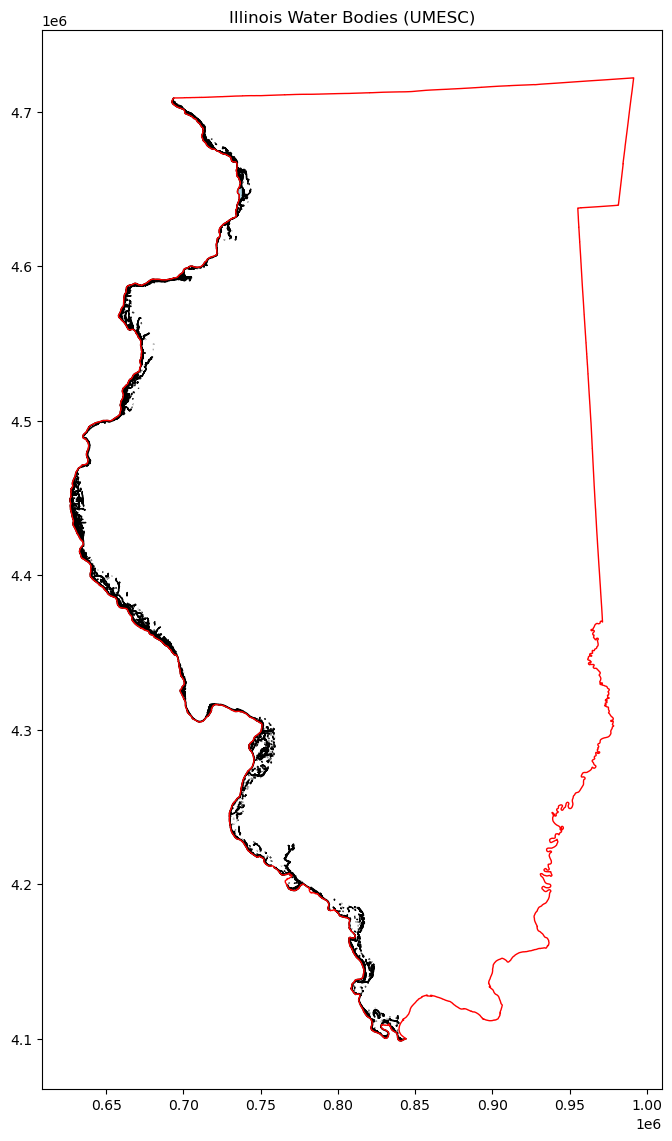

In [7]:
# Cell 3: Extract Illinois water portion
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)
illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

# Filter water polygons only
water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()
water_il = gpd.clip(water_only, illinois)

# Plot check
ax = water_il.plot(figsize=(8, 14), color="lightblue", edgecolor="k")
illinois.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Illinois Water Bodies (UMESC)")
plt.show()

In [8]:
print("Number of invalid geometries in water_only:", (~water_only.is_valid).sum())
print("Invalid geometries indices:", water_only[~water_only.is_valid].index)

Number of invalid geometries in water_only: 0
Invalid geometries indices: Index([], dtype='int64')


In [9]:
# Fix invalid geometries using buffer(0) - only if needed
water_only.loc[~water_only.is_valid, "geometry"] = water_only.loc[~water_only.is_valid, "geometry"].buffer(0)

# Verify
print("Invalid geometries after fix:", (~water_only.is_valid).sum())

Invalid geometries after fix: 0


In [10]:
# Ensure Illinois geometry is valid
illinois["geometry"] = illinois["geometry"].buffer(0)

# Perform clip
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

Clipped water shapes: (2876, 14)


In [11]:
# Combine all Illinois water polygons into a single geometry
river_il = water_il.union_all()
print(type(river_il))
print("Bounds of Illinois river section:", river_il.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Bounds of Illinois river section: (626594.3664122473, 4098437.22724262, 844182.0029604747, 4708927.272888837)


In [12]:
# Automatic date parsing
tornadoes = pd.read_csv(tornado_csv, parse_dates=['date'])

# Filter by states, pre-F/F/EF-scale, and date (can include stronger tornadoes on map, if necessary / min_date will likely be changed)
tornadoes = tornadoes[
    tornadoes['st'].isin(states_of_interest) &
    tornadoes['mag'].isin([0, 1, 2, 3, 4, 5]) &
    (tornadoes['date'] >= min_date)
]

print("Filtered tornadoes:", tornadoes.shape)
tornadoes

Filtered tornadoes: (8287, 37)


,om,yr,mo,dy,date,time,tz,st,stf,stn,...,f4,fc,datetime,sunrise_local,sunset_local,day_night_bin,diurnal_sec,nocturnal_sec,diurnal_hours,nocturnal_hours
0,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,0,0,1950-12-02 15:00:00-06:00,1950-12-02 07:00:56.487661-06:00,1950-12-02 16:38:03.787114-06:00,Day,34627.299453,51772.700547,9.618694,14.381306
1,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,0,0,1950-12-02 16:00:00-06:00,1950-12-02 06:58:49.244195-06:00,1950-12-02 16:37:08.674669-06:00,Day,34699.430474,51700.569526,9.638731,14.361269
2,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,0,0,1950-12-02 17:30:00-06:00,1950-12-02 06:57:41.974386-06:00,1950-12-02 16:39:09.003928-06:00,Night,34887.029542,51512.970458,9.690842,14.309158
3,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,0,0,1950-01-25 19:30:00-06:00,1950-01-25 07:12:19.167490-06:00,1950-01-25 17:18:20.206660-06:00,Night,36361.039170,50038.960830,10.100289,13.899711
4,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,0,0,1950-01-25 21:00:00-06:00,1950-01-25 07:07:14.812744-06:00,1950-01-25 16:56:38.836911-06:00,Night,35364.024167,51035.975833,9.823340,14.176660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8282,624857,2024,8,15,2024-08-15,22:06:00,3,IL,17,0,...,0,0,2024-08-15 22:06:00-05:00,2024-08-15 06:10:28.647548-05:00,2024-08-15 19:57:22.068989-05:00,Night,49613.421441,36786.578559,13.781506,10.218494
8283,624880,2024,8,30,2024-08-30,11:45:00,3,IL,17,0,...,0,0,2024-08-30 11:45:00-05:00,2024-08-30 06:28:19.260504-05:00,2024-08-30 19:30:38.696436-05:00,Day,46939.435932,39460.564068,13.038732,10.961268
8284,624820,2024,8,5,2024-08-05,20:57:00,3,IA,19,0,...,0,0,2024-08-05 20:57:00-05:00,2024-08-05 06:02:36.842388-05:00,2024-08-05 20:23:41.746723-05:00,Night,51664.904335,34735.095665,14.351362,9.648638
8285,624821,2024,8,5,2024-08-05,21:11:00,3,IA,19,0,...,0,0,2024-08-05 21:11:00-05:00,2024-08-05 06:02:07.597288-05:00,2024-08-05 20:23:11.960360-05:00,Night,51664.363072,34735.636928,14.351212,9.648788


In [13]:
print("Columns in dataset:")
print(tornadoes.columns)

print("\nPreliminary Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())

Columns in dataset:
Index(['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'mag',
       'inj', 'fat', 'loss', 'closs', 'slat', 'slon', 'elat', 'elon', 'len',
       'wid', 'ns', 'sn', 'sg', 'f1', 'f2', 'f3', 'f4', 'fc', 'datetime',
       'sunrise_local', 'sunset_local', 'day_night_bin', 'diurnal_sec',
       'nocturnal_sec', 'diurnal_hours', 'nocturnal_hours'],
      dtype='object')

Preliminary Day/Night counts:
day_night_bin
Day      6155
Night    2132
Name: count, dtype: int64


In [14]:
# Remove any rows with missing or invalid coordinates
coord_cols = ['slon', 'slat', 'elon', 'elat']
tornadoes = tornadoes.dropna(subset=coord_cols)

# Remove out-of-bounds or unrealistic coordinates
tornadoes = tornadoes[
    (tornadoes['slon'].between(-180, 180)) &
    (tornadoes['elon'].between(-180, 180)) &
    (tornadoes['slat'].between(-90, 90)) &
    (tornadoes['elat'].between(-90, 90))
]
print("After coordinate cleaning:", tornadoes.shape)

After coordinate cleaning: (8287, 37)


In [15]:
# --- Fix 1: Convert positive longitudes (U.S. longitudes are negative west of Greenwich) ---
tornadoes['slon'] = tornadoes['slon'].apply(lambda x: -x if x > 0 else x)
tornadoes['elon'] = tornadoes['elon'].apply(lambda x: -x if x > 0 else x)

# --- Fix 2: Remove zero or missing coordinates (invalid positions) ---
tornadoes.loc[tornadoes['slat'] == 0, 'slat'] = np.nan
tornadoes.loc[tornadoes['elat'] == 0, 'elat'] = np.nan
tornadoes.loc[tornadoes['slon'] == 0, 'slon'] = np.nan
tornadoes.loc[tornadoes['elon'] == 0, 'elon'] = np.nan

# Drop rows with NaNs after cleaning
tornadoes = tornadoes.dropna(subset=['slon', 'slat', 'elon', 'elat']).copy()

# Check coordinate ranges again
print("Longitude range (fixed):", tornadoes[['slon', 'elon']].min().min(), "to", tornadoes[['slon', 'elon']].max().max())
print("Latitude range (fixed):", tornadoes[['slat', 'elat']].min().min(), "to", tornadoes[['slat', 'elat']].max().max())

Longitude range (fixed): -96.6 to -85.23
Latitude range (fixed): 36.0022 to 45.5


In [16]:
from shapely.geometry import LineString, Point
import geopandas as gpd

# Create LineString or Point geometries
def make_geom(row):
    if pd.isna(row['elon']) or pd.isna(row['elat']) or \
       (row['elon'] == row['slon'] and row['elat'] == row['slat']):
        return Point(row['slon'], row['slat'])
    else:
        return LineString([(row['slon'], row['slat']), (row['elon'], row['elat'])])

tornadoes['geometry'] = tornadoes.apply(make_geom, axis=1)

# Convert to GeoDataFrame
tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry='geometry', crs="EPSG:4326")

# Reproject to match water shapefile CRS
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado geometries rebuilt")
print("Geometry types:", tornado_gdf.geometry.geom_type.value_counts())
print("Bounds:", tornado_gdf.total_bounds)

Tornado geometries rebuilt
Geometry types: LineString    4739
Point         1054
Name: count, dtype: int64
Bounds: [ 205367.62901075 3987738.95756939 1160467.39964418 5041734.47457036]


In [17]:
# Fix invalid water polygons
water_il['geometry'] = water_il['geometry'].buffer(0)

# Merge into single geometry
river_il_geom = water_il.geometry.union_all()  # or .union_all() if using new shapely

# Ensure the final geometry is valid
from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

In [18]:
# Buffer by 10 km
river_buffer = river_il_geom.buffer(10000)  # adjust as needed

# Check intersections with buffer
tornado_gdf['crosses_river'] = tornado_gdf.intersects(river_buffer)
crossings = tornado_gdf[tornado_gdf['crosses_river']]

print("Total tornadoes crossing Mississippi River or intersecting buffered zone:", crossings.shape[0])
print("Counts by pre-F/F/EF-scale:\n", crossings['mag'].value_counts())

Total tornadoes crossing Mississippi River or intersecting buffered zone: 372
Counts by pre-F/F/EF-scale:
 mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [19]:
#Quick sanity check to make sure the river buffer is actually or approximately ~10 km (and in the right units). 

from shapely.ops import nearest_points

# Pick a point on the river geometry
river_point = river_il_geom.representative_point()

# Pick nearest point on the buffer boundary
buffer_boundary = river_buffer.boundary
nearest = nearest_points(river_point, buffer_boundary)[1]

# Compute distance in meters (UTM units)
distance_m = river_point.distance(nearest)
distance_km = distance_m / 1000
print(f"Distance from river to buffer boundary: {distance_km:.2f} km")

Distance from river to buffer boundary: 10.67 km


In [20]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # --- Step 5: Plot ---
# fig, ax = plt.subplots(figsize=(10, 14))

# # Plot Illinois water and river buffer
# water_il.plot(ax=ax, color='lightblue', edgecolor='k')
# gpd.GeoSeries([river_buffer]).boundary.plot(ax=ax, color='red', linewidth=2, label='10 km Buffer')

# # Plot all tornadoes (lines + points)
# tornado_gdf.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3)
# tornado_gdf[tornado_gdf.geometry.geom_type == 'Point'].plot(ax=ax, color='gray', markersize=15, alpha=0.4)

# # Plot crossing tornadoes (lines + points)
# crossings.plot(ax=ax, color='blue', linewidth=1.5)
# crossings[crossings.geometry.geom_type == 'Point'].plot(ax=ax, color='blue', markersize=25)

# # Plot Illinois, Missouri, and Iowa boundaries
# illinois.boundary.plot(ax=ax, color='black', linewidth=1, label='Illinois Boundary')

# states_path = "/home/njm12/ATMS_596/ne_10m_admin_1_states_provinces.shp"
# states = gpd.read_file(states_path).to_crs(target_crs)
# states_mo_ia = states[states['name'].isin(['Missouri', 'Iowa'])]
# states_mo_ia.boundary.plot(ax=ax, color='lightgray', linewidth=1, label='MO / IA Boundary')

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # --- Labels, title, and caption ---
# ax.legend(handles=legend_elements, loc='upper right')
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.set_xlabel("Easting (meters, UTM Zone 15N)", fontsize=11)
# ax.set_ylabel("Northing (meters, UTM Zone 15N)", fontsize=11)

# # Figure caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in UTM Zone 15N (meters)."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

# plt.show()

In [21]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Reproject all layers to geographic (EPSG:4326)
# tornado_geo = tornado_gdf.to_crs("EPSG:4326")
# crossings_geo = crossings.to_crs("EPSG:4326")
# water_il_geo = water_il.to_crs("EPSG:4326")
# illinois_geo = illinois.to_crs("EPSG:4326")
# river_buffer_geo = gpd.GeoSeries([river_buffer], crs=water_il.crs).to_crs("EPSG:4326")

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# # Add map background
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
# ax.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.6)

# # Plot layers
# water_il_geo.plot(ax=ax, color='lightblue', edgecolor='k', transform=ccrs.PlateCarree(), zorder=1)
# river_buffer_geo.boundary.plot(ax=ax, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), label='10 km Buffer', zorder=2)
# tornado_geo.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3, transform=ccrs.PlateCarree(), label='All Tornadoes', zorder=3)
# crossings_geo.plot(ax=ax, color='blue', linewidth=1.5, transform=ccrs.PlateCarree(), label='Crossing Tornadoes', zorder=4)
# illinois_geo.boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

# # Gridlines and coordinate labels
# gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': 11}
# gl.ylabel_style = {'size': 11}

# # Add axis labels manually
# ax.text(0.5, -0.06, 'Longitude (°W)', va='center', ha='center', fontsize=12, transform=ax.transAxes)
# ax.text(-0.08, 0.5, 'Latitude (°N)', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # Add title and legend
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# # Caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in degrees latitude and longitude."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

In [22]:
# -------------------------------------------------------------------
# --- Identify west-side, east-side, and crossing tornadoes ---
# UPDATED: NEAREST-POINT RIVER METHOD
# -------------------------------------------------------------------

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Start with all tornadoes (EF0–EF5)
# ------------------------------------------------
weak_tornadoes = tornado_gdf[
    tornado_gdf["mag"].isin([0, 1, 2, 3, 4, 5])
].copy()

# ------------------------------------------------
# 2. Tornadoes that physically cross/touch river
# (UNCHANGED)
# ------------------------------------------------
crossing_tornadoes = weak_tornadoes[
    weak_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Tornadoes within/touching 10 km buffer
# but NOT touching/crossing river
# ------------------------------------------------
buffer_only = weak_tornadoes[
    weak_tornadoes.intersects(river_buffer) &
    (~weak_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Representative point for side determination
# ------------------------------------------------
buffer_only["rep_point"] = (
    buffer_only.geometry.representative_point()
)

# ------------------------------------------------
# 5. Determine west/east relative to
# LOCAL NEAREST RIVER POSITION
# ------------------------------------------------
def assign_side(point_geom):

    # nearest point ON river
    nearest_river_pt = nearest_points(
        point_geom,
        river_il_geom
    )[1]

    # compare relative x-position
    dx = point_geom.x - nearest_river_pt.x

    return "West" if dx < 0 else "East"

# Apply classification
buffer_only["side"] = (
    buffer_only["rep_point"]
    .apply(assign_side)
)

# ------------------------------------------------
# 6. Final west/east groups
# ------------------------------------------------
west_side = buffer_only[
    buffer_only["side"] == "West"
].copy()

east_side = buffer_only[
    buffer_only["side"] == "East"
].copy()

# ------------------------------------------------
# 7. Print summary results
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")

print(f"Total tornadoes: {len(weak_tornadoes)}")

print(
    "  • West-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(west_side)}"
)

print(
    "  • East-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(east_side)}"
)

print(
    "  • Crossing/touching the river: "
    f"{len(crossing_tornadoes)}"
)

print(
    "  • Sum check: "
    f"{len(west_side) + len(east_side) + len(crossing_tornadoes)} "
    "(should equal 372)"
)


--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side (within/touching 10 km buffer, not touching river): 142
  • East-side (within/touching 10 km buffer, not touching river): 141
  • Crossing/touching the river: 89
  • Sum check: 372 (should equal 372)


In [23]:
# ---------- Robust classification into West Control / East Control / Test (buffer/river) ----------
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure we use the variable names you have defined earlier:
# tornado_gdf  (all tornadoes, already reprojected to target_crs)
# weak_tornadoes (subset of tornado_gdf with mag in [0,1,2])
# river_il_geom  (shapely geometry of Illinois river section)
# river_buffer   (10 km buffer around river_il_geom) -- can be shapely geometry or GeoSeries

# 0) Ensure consistent CRS on weak_tornadoes
weak_tornadoes = weak_tornadoes.to_crs(target_crs)

# 1) Ensure buffer is a single (unary) shapely geometry for intersections
# If river_buffer is a GeoSeries or GeoDataFrame, get the unary_union (or .iloc[0] if single)
try:
    buffer_union = river_buffer
    # if it's a GeoSeries/GeoDataFrame convert to unary_union
    if hasattr(buffer_union, "unary_union"):
        buffer_union = buffer_union.unary_union
except NameError:
    # If river_buffer not available, create from river_il_geom
    buffer_union = river_il_geom.buffer(10000).union()

In [24]:
# 2) Test population: any weak tornado that intersects/touches the buffer OR intersects the river polygon itself
#    (this includes crossings which intersect the river geometry)
test_mask = weak_tornadoes.geometry.intersects(buffer_union) | weak_tornadoes.geometry.intersects(river_il_geom)
test_population = weak_tornadoes[test_mask].copy()

In [25]:
# 3) Outside buffer: those that do NOT intersect the buffer
# Compute side relative to actual river geometry
outside_buffer = weak_tornadoes[~test_mask].copy()

outside_buffer["centroid"] = outside_buffer.geometry.centroid

def assign_west_east(row, river_geom):
    centroid = row.centroid
    nearest = nearest_points(centroid, river_geom)[1]  # nearest point on river
    dx = centroid.x - nearest.x
    return "West Control" if dx < 0 else "East Control"

outside_buffer["side_type"] = outside_buffer.apply(assign_west_east, axis=1, river_geom=river_il_geom)

# Reassign west_control and east_control
west_control = outside_buffer[outside_buffer["side_type"] == "West Control"].copy()
east_control = outside_buffer[outside_buffer["side_type"] == "East Control"].copy()

#Before: split by centroid_x vs a single river_center_x -> vertical line.
#After: split by relative position to nearest river point -> follows meandering river.

In [26]:
# 7) Verify counts and find any unclassified (should not happen, but check)
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("Initial sizes:")
print(f"  Test population (intersect buffer/river): {len(test_population)}")
print(f"  West control (outside buffer):            {len(west_control)}")
print(f"  East control (outside buffer):            {len(east_control)}")
print(f"  Unclassified (should be 0):               {len(unclassified)}")
print(f"  Sum categories:                           {len(test_population)+len(west_control)+len(east_control)}")
print(f"  Total tornadoes:                          {len(weak_tornadoes)}")

Initial sizes:
  Test population (intersect buffer/river): 372
  West control (outside buffer):            3554
  East control (outside buffer):            1867
  Unclassified (should be 0):               0
  Sum categories:                           5793
  Total tornadoes:                          5793


In [27]:
print("\nUpdated Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())


Updated Day/Night counts:
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64


In [28]:
# 8) If any unclassified exist (tiny rounding artifacts), assign them deterministically:
if len(unclassified) > 0:
    # compute centroid x for those too
    unclassified["centroid"] = unclassified.geometry.centroid
    unclassified["centroid_x"] = unclassified["centroid"].apply(lambda p: p.x)
    # assign by centroid_x
    assign_west = unclassified[unclassified["centroid_x"] < river_center_x].index
    assign_east = unclassified[unclassified["centroid_x"] >= river_center_x].index
    west_control = pd.concat([west_control, unclassified.loc[assign_west]])
    east_control = pd.concat([east_control, unclassified.loc[assign_east]])
    # recompute combined check
    combined_idx = test_population.index.union(west_control.index).union(east_control.index)
    unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
    print("After deterministic centroid assignment, remaining unclassified:", len(unclassified))
    # If still unclassified (very unlikely), assign by nearest distance to river centerline
    if len(unclassified) > 0:
        # build a river centerline (if you have river_centerline GeoSeries earlier use that)
        try:
            centerline = river_centerline.unary_union
        except Exception:
            # fallback: approximate centerline by taking river_il_geom.representative_point()
            centerline = river_il_geom.representative_point()
        # compute distance to centerline and assign west/east by centroid_x anyway
        for idx, row in unclassified.iterrows():
            cx = row.geometry.centroid.x
            if cx < river_center_x:
                west_control = pd.concat([west_control, row.to_frame().T])
            else:
                east_control = pd.concat([east_control, row.to_frame().T])
        
# final check
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("After fallback nearest assignment, remaining unclassified:", len(unclassified))

After fallback nearest assignment, remaining unclassified: 0


In [29]:
# 9) Final assert / sanity check
total_calc = len(test_population) + len(west_control) + len(east_control)
print("\nFinal totals check:")
print(f"  Sum categories = {total_calc}")
print(f"  Total tornadoes = {len(weak_tornadoes)}")
assert total_calc == len(weak_tornadoes), "Final counts DO NOT sum to total tornadoes!"


Final totals check:
  Sum categories = 5793
  Total tornadoes = 5793


In [30]:
# 10) Create breakdown table for EF 0/1/2/3/4/5
def mag_counts(df):
    # Ensure mag is int-like and EF 0/1/2/3/4/5
    s = df["mag"].astype(int).value_counts().reindex([0, 1, 2, 3, 4, 5], fill_value=0)
    return s.to_dict()

summary = pd.DataFrame({
    "Category": ["West Control", "East Control", "Test (Buffer/River)"],
    "Count": [len(west_control), len(east_control), len(test_population)],
    "EF0": [mag_counts(west_control)[0], mag_counts(east_control)[0], mag_counts(test_population)[0]],
    "EF1": [mag_counts(west_control)[1], mag_counts(east_control)[1], mag_counts(test_population)[1]],
    "EF2": [mag_counts(west_control)[2], mag_counts(east_control)[2], mag_counts(test_population)[2]],
    "EF3": [mag_counts(west_control)[3], mag_counts(east_control)[3], mag_counts(test_population)[3]],
    "EF4": [mag_counts(west_control)[4], mag_counts(east_control)[4], mag_counts(test_population)[4]],
    "EF5": [mag_counts(west_control)[5], mag_counts(east_control)[5], mag_counts(test_population)[5]],
})

summary["Total EF0–EF5"] = summary[["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]].sum(axis=1)

# Add totals row
totals = summary[["Count", "EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "Total EF0–EF5"]].sum()
totals_row = pd.DataFrame([["All Tornadoes", totals["Count"], int(totals["EF0"]), int(totals["EF1"]), int(totals["EF2"]), int(totals["EF3"]), int(totals["EF4"]), int(totals["EF5"]), int(totals["Total EF0–EF5"])]],
                          columns=summary.columns)
summary = pd.concat([summary, totals_row], ignore_index=True)

print("\n--- Tornado Populations Summary ---")
print(summary.to_string(index=False))


--- Tornado Populations Summary ---
           Category  Count  EF0  EF1  EF2  EF3  EF4  EF5  Total EF0–EF5
       West Control   3554 1561 1158  588  176   65    6           3554
       East Control   1867  885  628  242   84   26    2           1867
Test (Buffer/River)    372  124  122   79   37   10    0            372
      All Tornadoes   5793 2570 1908  909  297  101    8           5793


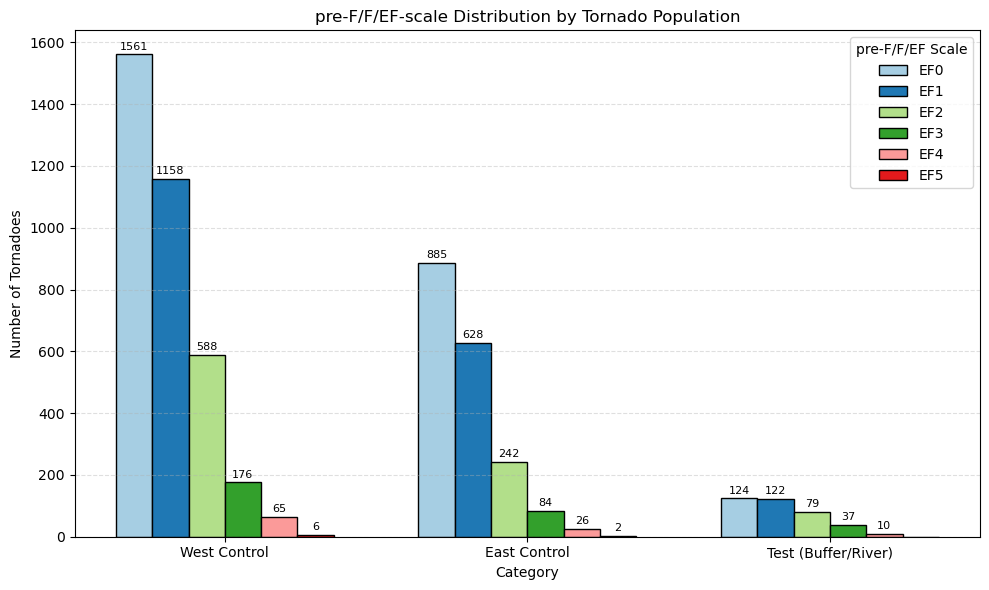

In [31]:
# ================================================================
# Clustered Bar Chart: pre-F/F/EF-scale Distribution by Category
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# Categories (clusters)
categories = ["West Control", "East Control", "Test (Buffer/River)"]

# pre-F/F/EF-scale bins
ef_bins = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]

# Extract counts from summary table
data = summary.loc[summary["Category"].isin(categories), ef_bins].values

# Bar configuration
n_groups = len(categories)
n_bars = len(ef_bins)
bar_width = 0.12

x = np.arange(n_groups)

# Colors for pre-F/F/EF-scale
colors = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99", "#e31a1c"]

plt.figure(figsize=(10,6))

for i, ef in enumerate(ef_bins):

    plt.bar(
        x + i*bar_width,
        data[:, i],
        width=bar_width,
        label=ef,
        color=colors[i],
        edgecolor="black"
    )

    # Add value labels
    for j in range(n_groups):
        count = data[j, i]
        if count > 0:
            plt.text(
                x[j] + i*bar_width,
                count + max(data.flatten())*0.01,
                int(count),
                ha='center',
                fontsize=8
            )

# Axis formatting
plt.xticks(x + bar_width*2.5, categories)
plt.ylabel("Number of Tornadoes")
plt.xlabel("Category")
plt.title("pre-F/F/EF-scale Distribution by Tornado Population")

plt.legend(title="pre-F/F/EF Scale")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [32]:
# --------------------------------------------------------------
# Create Day/Night pre-F/F/EF-scale breakdown table
# --------------------------------------------------------------

def mag_counts(df):
    s = df["mag"].astype(int).value_counts().reindex([0,1,2,3,4,5], fill_value=0)
    return s.to_dict()

# Assign side_type to full dataset
weak_tornadoes["side_type"] = "Unclassified"
weak_tornadoes.loc[weak_tornadoes.index.isin(west_control.index), "side_type"] = "West Control"
weak_tornadoes.loc[weak_tornadoes.index.isin(east_control.index), "side_type"] = "East Control"
weak_tornadoes.loc[weak_tornadoes.index.isin(test_population.index), "side_type"] = "Test (Buffer/River)"

# Keep only classified tornadoes
df = weak_tornadoes[weak_tornadoes["side_type"] != "Unclassified"].copy()

rows = []

categories = ["West Control", "East Control", "Test (Buffer/River)"]
periods = ["Day", "Night"]

for cat in categories:
    
    for period in periods:
        
        subset = df[
            (df["side_type"] == cat) &
            (df["day_night_bin"] == period)
        ]
        
        counts = mag_counts(subset)
        
        rows.append({
            "Category": cat,
            "Time": period,
            "Count": len(subset),
            "EF0": counts[0],
            "EF1": counts[1],
            "EF2": counts[2],
            "EF3": counts[3],
            "EF4": counts[4],
            "EF5": counts[5],
        })

summary = pd.DataFrame(rows)

summary["Total EF0–EF5"] = summary[["EF0","EF1","EF2","EF3","EF4","EF5"]].sum(axis=1)

# --------------------------------------------------------------
# Add totals row
# --------------------------------------------------------------

totals = summary[["Count","EF0","EF1","EF2","EF3","EF4","EF5","Total EF0–EF5"]].sum()

totals_row = pd.DataFrame(
    [["All Tornadoes","Day+Night",
      totals["Count"],
      int(totals["EF0"]),
      int(totals["EF1"]),
      int(totals["EF2"]),
      int(totals["EF3"]),
      int(totals["EF4"]),
      int(totals["EF5"]),
      int(totals["Total EF0–EF5"])
    ]],
    columns=summary.columns
)

summary = pd.concat([summary, totals_row], ignore_index=True)

print("\n--- Tornado Populations Summary (Day/Night) ---")
print(summary.to_string(index=False))


--- Tornado Populations Summary (Day/Night) ---
           Category      Time  Count  EF0  EF1  EF2  EF3  EF4  EF5  Total EF0–EF5
       West Control       Day   2589 1216  776  402  133   56    6           2589
       West Control     Night    965  345  382  186   43    9    0            965
       East Control       Day   1445  760  444  158   59   22    2           1445
       East Control     Night    422  125  184   84   25    4    0            422
Test (Buffer/River)       Day    269   99   86   54   26    4    0            269
Test (Buffer/River)     Night    103   25   36   25   11    6    0            103
      All Tornadoes Day+Night   5793 2570 1908  909  297  101    8           5793


In [33]:
# --- 1. Prepare data ---
# Add side_type column for clarity
weak_tornadoes["side_type"] = "Unclassified"
weak_tornadoes.loc[weak_tornadoes.index.isin(west_control.index), "side_type"] = "West Control"
weak_tornadoes.loc[weak_tornadoes.index.isin(east_control.index), "side_type"] = "East Control"
weak_tornadoes.loc[weak_tornadoes.index.isin(test_population.index), "side_type"] = "Test (Buffer/River)"

# Reproject all layers to geographic (EPSG:4326)
tornado_geo = weak_tornadoes.to_crs("EPSG:4326")
water_il_geo = water_il.to_crs("EPSG:4326")
illinois_geo = illinois.to_crs("EPSG:4326")
river_buffer_geo = gpd.GeoSeries([buffer_union], crs=water_il.crs).to_crs("EPSG:4326")

# Split tornadoes by category for plotting
west_geo = tornado_geo[tornado_geo["side_type"] == "West Control"]
east_geo = tornado_geo[tornado_geo["side_type"] == "East Control"]
test_geo = tornado_geo[tornado_geo["side_type"] == "Test (Buffer/River)"]

In [34]:
# --------------------------------------------------------------
# 1) RANDOM SAMPLING (372 each)
# --------------------------------------------------------------

# Fix seed for reproducibility
np.random.seed(42)

random_west_control = west_control.sample(n=372, replace=False, random_state=42)
random_east_control = east_control.sample(n=372, replace=False, random_state=42)

print("\n--- Random West Control Sample (372) ---")
print(random_west_control[["om", "yr", "mo", "dy", "mag", "slat", "slon", "elat", "elon"]].head(10).to_string(index=False))

print("\n--- Random East Control Sample (372) ---")
print(random_east_control[["om", "yr", "mo", "dy", "mag", "slat", "slon", "elat", "elon"]].head(10).to_string(index=False))

# --------------------------------------------------------------
# 2) REPROJECT RANDOM SUBSETS FOR PLOTTING
# --------------------------------------------------------------

random_west_geo = random_west_control.to_crs("EPSG:4326")
random_east_geo = random_east_control.to_crs("EPSG:4326")
test_geo = test_geo.to_crs("EPSG:4326")  # already defined earlier

water_il_geo = water_il.to_crs("EPSG:4326")
illinois_geo = illinois.to_crs("EPSG:4326")
river_buffer_geo = gpd.GeoSeries([buffer_union], crs=water_il.crs).to_crs("EPSG:4326")


--- Random West Control Sample (372) ---
    om   yr  mo  dy  mag    slat     slon    elat     elon
    37 1967   1  27    2 37.0200 -94.1700 37.0700 -94.1000
   152 2010   4  24    0 38.5906 -90.4392 38.5986 -90.4439
313456 2011   5  25    0 38.8369 -93.0356 38.8369 -93.0356
624288 2024   5  24    0 41.1310 -95.1000 41.1440 -95.0870
533461 2014   8  31    1 42.3072 -94.0661 42.3074 -94.0011
527459 2014   6  29    0 39.5627 -95.0526 39.5629 -95.0480
   524 2008   4  25    0 40.8500 -92.4200 40.8500 -92.4000
   499 2002   4  17    0 41.9000 -94.6800 41.9000 -94.6800
   203 2002   7  26    1 40.6800 -94.9700 40.7000 -95.0000
  1056 2009   8  19    0 43.1953 -91.8601 43.2487 -91.7849

--- Random East Control Sample (372) ---
    om   yr  mo  dy  mag    slat     slon    elat     elon
623084 2023   7  12    1 42.1544 -88.5188 42.1631 -88.3941
622118 2023   1   3    1 40.4220 -88.3670 40.4490 -88.3240
   393 2006   4  16    0 40.7500 -88.1500 40.7500 -88.1300
   233 1984   4  27    3 41.550


Tornado counts:
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64


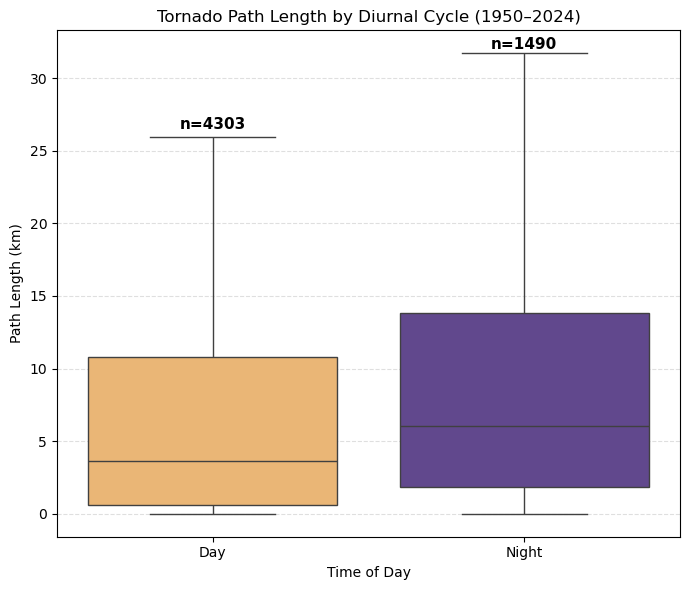


Five-number summary (km):
               Min        Q1    Median         Q3         Max
day_night_bin                                                
Day            0.0  0.611549  3.621015  10.782578  260.713080
Night          0.0  1.834648  6.035025  13.816184  189.741186


In [35]:
# ================================================================
# All Tornadoes: Path Length by Day vs Night
# ================================================================

all_tornadoes = tornadoes.copy()

# Convert miles → km
all_tornadoes["len_km"] = all_tornadoes["len"] * 1.60934

plt.figure(figsize=(7,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=all_tornadoes,
    x="day_night_bin",
    y="len_km",
    hue="day_night_bin",
    palette=palette,
    showfliers=False,
    legend=False
)

# ------------------------------------------------
# Tornado counts
# ------------------------------------------------

counts = all_tornadoes["day_night_bin"].value_counts()

print("\nTornado counts:")
print(counts)

# ------------------------------------------------
# Manually position counts
# ------------------------------------------------

positions = {
    "Day": (0, 26.5),
    "Night": (1, 32)
}

for period,(x,y) in positions.items():

    n = counts.get(period,0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# ------------------------------------------------
# Formatting
# ------------------------------------------------

ax.set_title("Tornado Path Length by Diurnal Cycle (1950–2024)")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# Five-number summary
# ------------------------------------------------

summary_daynight = (
    all_tornadoes.groupby("day_night_bin")["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_daynight.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (km):")
print(summary_daynight)

#As a side note: The whiskers do not go to the absolute minimum and maximum values by default. Instead, Seaborn (via Matplotlib) follows the Tukey boxplot definition.

In [36]:
# ================================================================
# Mann-Whitney U Test: Day vs Night Tornado Path Length
# ================================================================

from scipy.stats import mannwhitneyu

day_lengths = all_tornadoes[
    all_tornadoes["day_night_bin"] == "Day"
]["len_km"]

night_lengths = all_tornadoes[
    all_tornadoes["day_night_bin"] == "Night"
]["len_km"]

U, p = mannwhitneyu(
    day_lengths,
    night_lengths,
    alternative="two-sided"
)

print("Mann–Whitney U Test on Tornado Path Length (Day vs Night)")
print("-----------------------------------------------------------")

print(f"U statistic = {U:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: There is a statistically significant difference in tornado path lengths between diurnal and nocturnal events.")
else:
    print("Interpretation: No statistically significant difference detected.")

Mann–Whitney U Test on Tornado Path Length (Day vs Night)
-----------------------------------------------------------
U statistic = 2661167.500
p-value = 0.000000
Interpretation: There is a statistically significant difference in tornado path lengths between diurnal and nocturnal events.


### Mann–Whitney U Test on Tornado Path Lengths (Day vs Night)

#### Rationale for Test Selection

Because the comparison involves **two independent groups (diurnal vs nocturnal tornadoes)**, the Mann–Whitney U test (also known as the Wilcoxon rank-sum test) is the most appropriate nonparametric test. While a Kruskal–Wallis test would yield an equivalent result for two groups, the Mann–Whitney U test is the standard approach for comparing **two independent samples with non-normal distributions**. Tornado path lengths exhibit a strongly **right-skewed distribution with extreme outliers**, making a nonparametric test more appropriate than parametric alternatives.

#### Overall Test

U statistic = **2,661,167.500**  
p-value **< 0.001**

**Interpretation:**  
There is a statistically significant difference in tornado path lengths between diurnal and nocturnal events.

#### Five-Number Summary (Path Length, km)

| Group | Min | Q1 | Median | Q3 | Max |
|------|------|------|------|------|------|
| Day | 0.000 | 0.612 | 3.621 | 10.783 | 260.713 |
| Night | 0.000 | 1.835 | 6.035 | 13.816 | 189.741 |

#### Summary

Across the 1950–2024 climatology for Missouri, Iowa, and Illinois, **nocturnal tornadoes exhibit longer path lengths than diurnal tornadoes**. The median path length for nocturnal tornadoes (6.04 km) exceeds that of diurnal tornadoes (3.62 km), indicating enhanced persistence among nighttime events. This result is statistically significant based on the Mann–Whitney U test and provides initial evidence supporting the hypothesis that nocturnal environmental conditions may favor longer-lived tornadoes.


Tornado counts:
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64


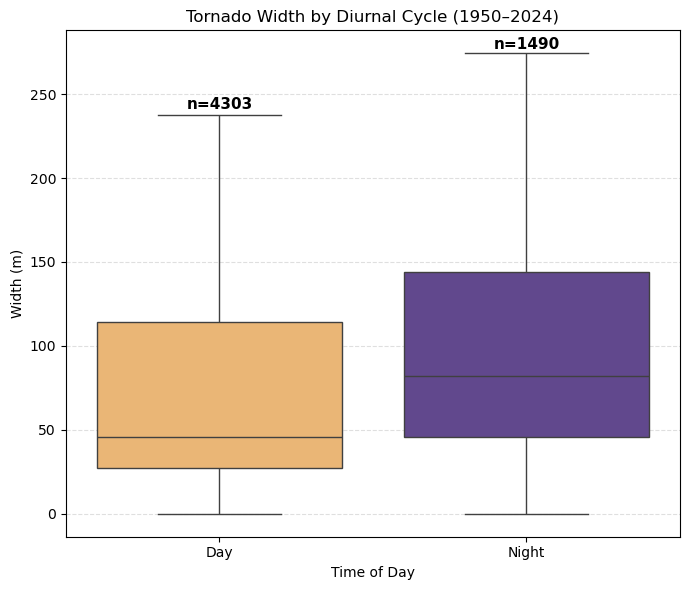


Five-number summary (meters):
               Min      Q1  Median       Q3       Max
day_night_bin                                        
Day            0.0  27.432  45.720  114.300  2404.872
Night          0.0  45.720  82.296  144.018  2414.016


In [37]:
# ================================================================
# All Tornadoes: Width by Day vs Night
# ================================================================

all_tornadoes = tornadoes.copy()

# Convert yards → meters
all_tornadoes["width_m"] = all_tornadoes["wid"] * 0.9144

plt.figure(figsize=(7,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=all_tornadoes,
    x="day_night_bin",
    y="width_m",
    hue="day_night_bin",
    palette=palette,
    showfliers=False,
    legend=False
)

# ------------------------------------------------
# Tornado counts
# ------------------------------------------------

counts = all_tornadoes["day_night_bin"].value_counts()

print("\nTornado counts:")
print(counts)

# ------------------------------------------------
# Manually position counts
# ------------------------------------------------

positions = {
    "Day": (0, 241),
    "Night": (1, 277)
}

for period,(x,y) in positions.items():

    n = counts.get(period,0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# ------------------------------------------------
# Formatting
# ------------------------------------------------

ax.set_title("Tornado Width by Diurnal Cycle (1950–2024)")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

summary_daynight = (
    all_tornadoes.groupby("day_night_bin")["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_daynight.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (meters):")
print(summary_daynight)

In [38]:
from scipy.stats import mannwhitneyu

day_widths = all_tornadoes[
    all_tornadoes["day_night_bin"] == "Day"
]["width_m"]

night_widths = all_tornadoes[
    all_tornadoes["day_night_bin"] == "Night"
]["width_m"]

U, p = mannwhitneyu(
    day_widths,
    night_widths,
    alternative="two-sided"
)

print("Mann–Whitney U Test on Tornado Width (Day vs Night)")
print("----------------------------------------------------")

print(f"U statistic = {U:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: Statistically significant difference in tornado width.")
else:
    print("Interpretation: No statistically significant difference detected.")

Mann–Whitney U Test on Tornado Width (Day vs Night)
----------------------------------------------------
U statistic = 2672974.500
p-value = 0.000000
Interpretation: Statistically significant difference in tornado width.


### Mann–Whitney U Test on Tornado Widths (Day vs Night)

#### Rationale for Test Selection

Because the comparison involves **two independent groups (diurnal vs nocturnal tornadoes)**, the Mann–Whitney U test (also known as the Wilcoxon rank-sum test) is the most appropriate nonparametric test. While a Kruskal–Wallis test would yield an equivalent result for two groups, the Mann–Whitney U test is the standard approach for comparing **two independent samples with non-normal distributions**. Tornado widths exhibit a strongly **right-skewed distribution with extreme outliers**, making a nonparametric test more appropriate than parametric alternatives.

#### Overall Test

U statistic = **2,672,974.500**  
p-value **< 0.001**

**Interpretation:**  
There is a statistically significant difference in tornado widths between diurnal and nocturnal events.

#### Five-Number Summary (Width, meters)

| Group | Min | Q1 | Median | Q3 | Max |
|------|------|------|------|------|------|
| Day | 0.000 | 27.432 | 45.720 | 114.300 | 2404.872 |
| Night | 0.000 | 45.720 | 82.296 | 144.018 | 2414.016 |

#### Summary

Across the 1950–2024 climatology for Missouri, Iowa, and Illinois, **nocturnal tornadoes exhibit greater widths than diurnal tornadoes**. The median width for nocturnal tornadoes (82.30 m) exceeds that of diurnal tornadoes (45.72 m), indicating that nighttime events tend to be broader. This difference is statistically significant based on the Mann–Whitney U test and suggests that nocturnal environmental conditions may favor the development of wider tornadoes.

In [39]:
# ================================================================
# Combine Day + Night and assign categories
# ================================================================

df_all = weak_tornadoes.copy()

# Ensure side_type is assigned
df_all["side_type"] = "Unclassified"
df_all.loc[df_all.index.isin(west_control.index), "side_type"] = "West Control"
df_all.loc[df_all.index.isin(east_control.index), "side_type"] = "East Control"
df_all.loc[df_all.index.isin(test_population.index), "side_type"] = "Test (Buffer/River)"

# Keep only classified tornadoes
df_all = df_all[df_all["side_type"] != "Unclassified"].copy()

print("Counts by category:")
print(df_all["side_type"].value_counts())

Counts by category:
side_type
West Control           3554
East Control           1867
Test (Buffer/River)     372
Name: count, dtype: int64


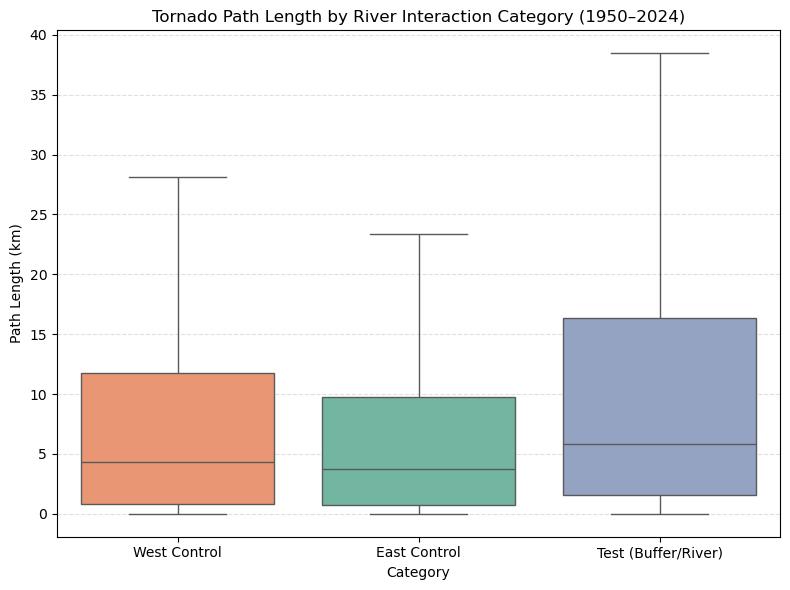


Five-number summary (Path Length, km):
                     Min        Q1    Median         Q3         Max
side_type                                                          
East Control         0.0  0.732250  3.765856   9.784787  252.183578
Test (Buffer/River)  0.0  1.601293  5.825811  16.383081  237.216716
West Control         0.0  0.804670  4.345218  11.748182  260.713080


In [40]:
order = ["West Control", "East Control", "Test (Buffer/River)"]

# Convert miles → km
df_all["len_km"] = df_all["len"] * 1.60934

plt.figure(figsize=(8,6))

palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=df_all,
    x="side_type",
    y="len_km",
    hue="side_type",
    palette=palette,
    order=order,
    showfliers=False,
    legend=False
)

ax.set_title("Tornado Path Length by River Interaction Category (1950–2024)")
ax.set_xlabel("Category")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

summary_len = (
    df_all.groupby("side_type")["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_len.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (Path Length, km):")
print(summary_len)

In [41]:
from scipy.stats import kruskal

groups_len = {
    "West Control": df_all[df_all["side_type"] == "West Control"]["len_km"],
    "East Control": df_all[df_all["side_type"] == "East Control"]["len_km"],
    "Test (Buffer/River)": df_all[df_all["side_type"] == "Test (Buffer/River)"]["len_km"]
}

H_len, p_len = kruskal(*groups_len.values())

print("\nKruskal-Wallis Test (Path Length)")
print("-----------------------------------")
print(f"H = {H_len:.3f}")
print(f"p = {p_len:.6f}")


Kruskal-Wallis Test (Path Length)
-----------------------------------
H = 32.289
p = 0.000000


In [42]:
import itertools

pairs = list(itertools.combinations(groups_len.keys(), 2))

results = []

for a, b in pairs:
    stat, p_val = kruskal(groups_len[a], groups_len[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val
    })

pairwise_len = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(pairwise_len)
pairwise_len["Adj p-value (Bonferroni)"] = pairwise_len["p-value"] * n_tests
pairwise_len["Significant?"] = pairwise_len["p-value"] < 0.05
pairwise_len["Adj Significant?"] = pairwise_len["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Comparisons (Path Length):")
display(pairwise_len)


Pairwise Comparisons (Path Length):


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Control,East Control,11.405656,7.322082e-04,2.196625e-03,True,True
1,West Control,Test (Buffer/River),15.488508,8.300840e-05,2.490252e-04,True,True
2,East Control,Test (Buffer/River),28.774997,8.129384e-08,2.438815e-07,True,True


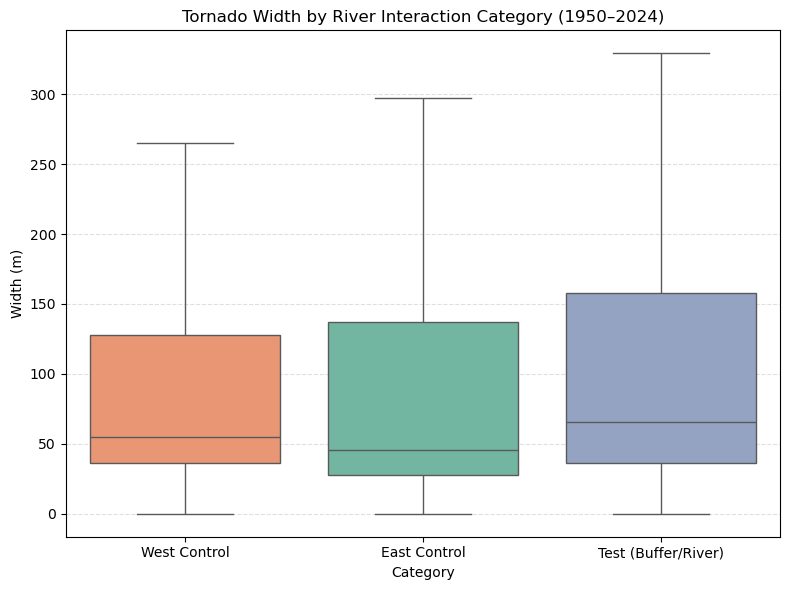


Five-number summary (Width, m):
                     Min      Q1   Median        Q3       Max
side_type                                                    
East Control         0.0  27.432  45.7200  137.1600  2404.872
Test (Buffer/River)  0.0  36.576  65.3796  157.9626  2011.680
West Control         0.0  36.576  54.8640  128.0160  2414.016


In [43]:
order = ["West Control", "East Control", "Test (Buffer/River)"]

# Convert yards → meters
df_all["width_m"] = df_all["wid"] * 0.9144

plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df_all,
    x="side_type",
    y="width_m",
    hue="side_type",
    palette=palette,
    order=order,
    showfliers=False,
    legend=False
)

ax.set_title("Tornado Width by River Interaction Category (1950–2024)")
ax.set_xlabel("Category")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

summary_wid = (
    df_all.groupby("side_type")["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_wid.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (Width, m):")
print(summary_wid)

In [44]:
groups_wid = {
    "West Control": df_all[df_all["side_type"] == "West Control"]["width_m"],
    "East Control": df_all[df_all["side_type"] == "East Control"]["width_m"],
    "Test (Buffer/River)": df_all[df_all["side_type"] == "Test (Buffer/River)"]["width_m"]
}

H_wid, p_wid = kruskal(*groups_wid.values())

print("\nKruskal-Wallis Test (Width)")
print("--------------------------------")
print(f"H = {H_wid:.3f}")
print(f"p = {p_wid:.6f}")


Kruskal-Wallis Test (Width)
--------------------------------
H = 12.368
p = 0.002062


In [45]:
pairs = list(itertools.combinations(groups_wid.keys(), 2))

results = []

for a, b in pairs:
    stat, p_val = kruskal(groups_wid[a], groups_wid[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val
    })

pairwise_wid = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(pairwise_wid)
pairwise_wid["Adj p-value (Bonferroni)"] = pairwise_wid["p-value"] * n_tests
pairwise_wid["Significant?"] = pairwise_wid["p-value"] < 0.05
pairwise_wid["Adj Significant?"] = pairwise_wid["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Comparisons (Width):")
display(pairwise_wid)


Pairwise Comparisons (Width):


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Control,East Control,8.067640,0.004506,0.013519,True,True
1,West Control,Test (Buffer/River),2.695922,0.100605,0.301816,False,False
2,East Control,Test (Buffer/River),7.766269,0.005323,0.015969,True,True


In [46]:
# --------------------------------------------------------------
# Build NIGHT target distribution (Category x EF)
# --------------------------------------------------------------

night_df = weak_tornadoes[
    weak_tornadoes["day_night_bin"] == "Night"
].copy()

target_counts = (
    night_df.groupby(["side_type", "mag"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0,1,2,3,4,5], fill_value=0)
)

print("\nTarget NIGHT distribution (Category x EF):")
print(target_counts)


Target NIGHT distribution (Category x EF):
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0


In [47]:
# --------------------------------------------------------------
# Stratified sampling function (match EF + category)
# --------------------------------------------------------------

def sample_day_to_match_night(day_df, target_counts):

    samples = []

    for side in target_counts.index:
        for ef in target_counts.columns:

            n_target = target_counts.loc[side, ef]

            if n_target == 0:
                continue

            subset = day_df[
                (day_df["side_type"] == side) &
                (day_df["mag"] == ef)
            ]

            if len(subset) == 0:
                continue

            # Decide replacement
            replace_flag = len(subset) < n_target

            sampled = subset.sample(
                n=n_target,
                replace=replace_flag,
                random_state=None
            )

            samples.append(sampled)

    return pd.concat(samples, ignore_index=True)

In [48]:
day_df = weak_tornadoes[
    weak_tornadoes["day_night_bin"] == "Day"
].copy()

matched_day = sample_day_to_match_night(day_df, target_counts)

print("\nSample sizes:")
print("Day (matched):", len(matched_day))
print("Night:", len(night_df))

def print_distribution(df, label):

    table = (
        df.groupby(["side_type", "mag"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[0,1,2,3,4,5], fill_value=0)
    )

    print(f"\n{label} Distribution:")
    print(table)

print_distribution(matched_day, "MATCHED DAY")
print_distribution(night_df, "NIGHT (TARGET)")


Sample sizes:
Day (matched): 1490
Night: 1490

MATCHED DAY Distribution:
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0

NIGHT (TARGET) Distribution:
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0



Tornado counts (MATCHED):
day_night_bin
Day      1490
Night    1490
Name: count, dtype: int64


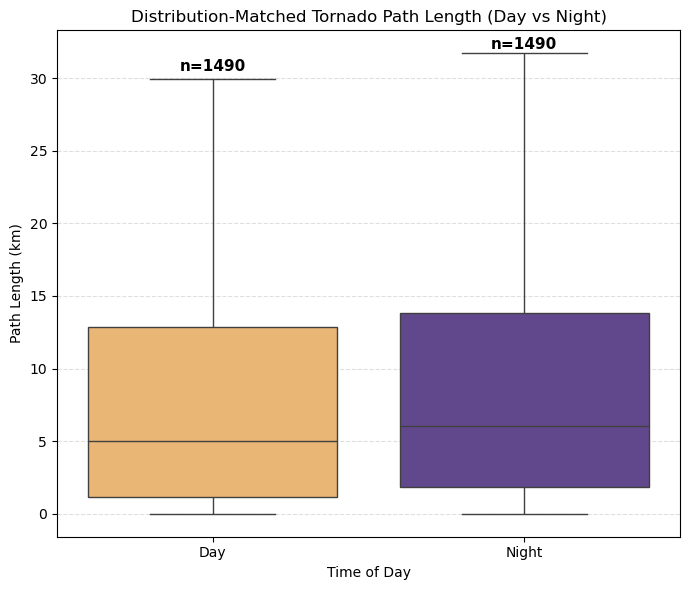


Five-number summary (km) — MATCHED:
               Min        Q1    Median         Q3         Max
day_night_bin                                                
Day            0.0  1.166771  4.988954  12.874720  252.183578
Night          0.0  1.834648  6.035025  13.816184  189.741186


In [49]:
# ================================================================
# MATCHED Tornadoes: Path Length by Day vs Night
# ================================================================

plot_df = pd.concat([
    matched_day.assign(day_night_bin="Day"),
    night_df.assign(day_night_bin="Night")
]).copy()

# Convert miles → km
plot_df["len_km"] = plot_df["len"] * 1.60934

plt.figure(figsize=(7,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=plot_df,
    x="day_night_bin",
    y="len_km",
    hue="day_night_bin",
    palette=palette,
    showfliers=False,
    legend=False
)

# ------------------------------------------------
# Tornado counts
# ------------------------------------------------

counts = plot_df["day_night_bin"].value_counts()

print("\nTornado counts (MATCHED):")
print(counts)

# ------------------------------------------------
# Manually position counts
# ------------------------------------------------

positions = {
    "Day": (0, 30.5),
    "Night": (1, 32)
}

for period,(x,y) in positions.items():

    n = counts.get(period,0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# ------------------------------------------------
# Formatting
# ------------------------------------------------

ax.set_title("Distribution-Matched Tornado Path Length (Day vs Night)")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

summary_daynight = (
    plot_df.groupby("day_night_bin")["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_daynight.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (km) — MATCHED:")
print(summary_daynight)

In [50]:
from scipy.stats import kruskal

groups = [
    plot_df[plot_df["day_night_bin"] == "Day"]["len_km"],
    plot_df[plot_df["day_night_bin"] == "Night"]["len_km"]
]

H_stat, p_val = kruskal(*groups)

print("\nKruskal-Wallis Test (MATCHED)")
print("--------------------------------")
print(f"H = {H_stat:.3f}")
print(f"p = {p_val:.6f}")


Kruskal-Wallis Test (MATCHED)
--------------------------------
H = 9.452
p = 0.002109


In [51]:
import itertools

# --------------------------------------------------------------
# Build groups dictionary (clean + extendable)
# --------------------------------------------------------------

groups = {
    "Day": plot_df[plot_df["day_night_bin"] == "Day"]["len_km"].values,
    "Night": plot_df[plot_df["day_night_bin"] == "Night"]["len_km"].values
}

# --------------------------------------------------------------
# Pairwise combinations
# --------------------------------------------------------------

pairs = list(itertools.combinations(groups.keys(), 2))

results = []

for a, b in pairs:

    try:
        stat, p_val = kruskal(groups[a], groups[b])

        results.append({
            "Group1": a,
            "Group2": b,
            "H": stat,
            "p-value": p_val
        })

    except Exception:
        continue

pairwise_df = pd.DataFrame(results)

# --------------------------------------------------------------
# Bonferroni correction (Not applicable here)
# --------------------------------------------------------------

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests
pairwise_df["Significant?"] = pairwise_df["p-value"] < 0.05
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Comparisons:")
display(pairwise_df)


Pairwise Comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,Day,Night,9.452217,0.002109,0.002109,True,True


In [52]:
# # Raw significance
# sig_raw = pairwise_df[pairwise_df["Significant?"]]

# print("\nSignificant (raw p < 0.05):")
# display(sig_raw if not sig_raw.empty else "None")

# # Bonferroni significance
# sig_adj = pairwise_df[pairwise_df["Adj Significant?"]]

# print("\nSignificant after Bonferroni correction:")
# display(sig_adj if not sig_adj.empty else "None")

In [53]:
# ================================================================
# Monte Carlo resampling (MATCHED)
# ================================================================

n_boot = 10000
np.random.seed(42)

p_values = []
H_values = []

for i in range(n_boot):

    try:
        matched_day = sample_day_to_match_night(day_df, target_counts)

        df_boot = pd.concat([
            matched_day.assign(day_night_bin="Day"),
            night_df.assign(day_night_bin="Night")
        ])

        df_boot["len_km"] = df_boot["len"] * 1.60934

        groups_boot = [
            df_boot[df_boot["day_night_bin"] == "Day"]["len_km"].values,
            df_boot[df_boot["day_night_bin"] == "Night"]["len_km"].values
        ]

        H_stat, p_boot = kruskal(*groups_boot)

        H_values.append(H_stat)
        p_values.append(p_boot)

    except Exception:
        continue

p_values = np.array(p_values)
H_values = np.array(H_values)

print("\nMonte Carlo Results (MATCHED LENGTH)")
print("--------------------------------------------------")
print(f"Valid iterations: {len(p_values)}")

print("\nP-value statistics:")
print(f"Mean:   {np.mean(p_values):.4f}")
print(f"Median: {np.median(p_values):.4f}")
print(f"Std:    {np.std(p_values):.4f}")
print(f"Fraction p < 0.05: {np.mean(p_values < 0.05):.4f}")

print("\nH-statistics:")
print(f"Mean:   {np.mean(H_values):.3f}")
print(f"Median: {np.median(H_values):.3f}")
print(f"Std:    {np.std(H_values):.3f}")

print("\nSignificance fractions:")
print(np.mean(p_values < 0.10))
print(np.mean(p_values < 0.05))
print(np.mean(p_values < 0.01))
print(np.mean(p_values < 0.001))


Monte Carlo Results (MATCHED LENGTH)
--------------------------------------------------
Valid iterations: 10000

P-value statistics:
Mean:   0.0061
Median: 0.0029
Std:    0.0100
Fraction p < 0.05: 0.9912

H-statistics:
Mean:   9.075
Median: 8.893
Std:    2.520

Significance fractions:
0.9987
0.9912
0.838
0.2312


In [54]:
# ================================================================
# Median Difference Analysis (MATCHED LENGTH: Day vs Night)
# ================================================================

median_diffs = []

for i in range(n_boot):

    try:
        # Resample matched Day each iteration
        matched_day = sample_day_to_match_night(day_df, target_counts)

        # Convert miles → km
        day_len = matched_day["len"] * 1.60934
        night_len = night_df["len"] * 1.60934

        # Compute medians
        median_day = day_len.median()
        median_night = night_len.median()

        # Difference: Night - Day
        median_diffs.append(median_night - median_day)

    except Exception:
        continue

median_diffs = np.array(median_diffs)

print("\nMedian Difference Results (PATH LENGTH, km)")
print("--------------------------------------------------")
print(f"Mean median difference (Night - Day): {np.mean(median_diffs):.3f} km")
print(f"Median of differences: {np.median(median_diffs):.3f} km")
print(f"Std dev: {np.std(median_diffs):.3f} km")

print("\nDirectional signal:")
print(f"Fraction (Night > Day): {np.mean(median_diffs > 0):.4f}")
print(f"Fraction (Night < Day): {np.mean(median_diffs < 0):.4f}")


Median Difference Results (PATH LENGTH, km)
--------------------------------------------------
Mean median difference (Night - Day): 1.030 km
Median of differences: 1.127 km
Std dev: 0.198 km

Directional signal:
Fraction (Night > Day): 1.0000
Fraction (Night < Day): 0.0000


In [55]:
# --------------------------------------------------------------
# Build NIGHT target distribution (Category x EF)
# --------------------------------------------------------------

night_df = weak_tornadoes[
    weak_tornadoes["day_night_bin"] == "Night"
].copy()

target_counts = (
    night_df.groupby(["side_type", "mag"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0,1,2,3,4,5], fill_value=0)
)

print("\nTarget NIGHT distribution (Category x EF):")
print(target_counts)


Target NIGHT distribution (Category x EF):
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0


In [56]:
# --------------------------------------------------------------
# Stratified sampling function (match EF + category)
# --------------------------------------------------------------

def sample_day_to_match_night(day_df, target_counts):

    samples = []

    for side in target_counts.index:
        for ef in target_counts.columns:

            n_target = target_counts.loc[side, ef]

            if n_target == 0:
                continue

            subset = day_df[
                (day_df["side_type"] == side) &
                (day_df["mag"] == ef)
            ]

            if len(subset) == 0:
                continue

            replace_flag = len(subset) < n_target

            sampled = subset.sample(
                n=n_target,
                replace=replace_flag,
                random_state=None
            )

            samples.append(sampled)

    return pd.concat(samples, ignore_index=True)

In [57]:
day_df = weak_tornadoes[
    weak_tornadoes["day_night_bin"] == "Day"
].copy()

matched_day = sample_day_to_match_night(day_df, target_counts)

print("\nSample sizes:")
print("Day (matched):", len(matched_day))
print("Night:", len(night_df))


def print_distribution(df, label):

    table = (
        df.groupby(["side_type", "mag"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[0,1,2,3,4,5], fill_value=0)
    )

    print(f"\n{label} Distribution:")
    print(table)

print_distribution(matched_day, "MATCHED DAY")
print_distribution(night_df, "NIGHT (TARGET)")


Sample sizes:
Day (matched): 1490
Night: 1490

MATCHED DAY Distribution:
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0

NIGHT (TARGET) Distribution:
mag                    0    1    2   3  4  5
side_type                                   
East Control         125  184   84  25  4  0
Test (Buffer/River)   25   36   25  11  6  0
West Control         345  382  186  43  9  0



Tornado counts (MATCHED):
day_night_bin
Day      1490
Night    1490
Name: count, dtype: int64


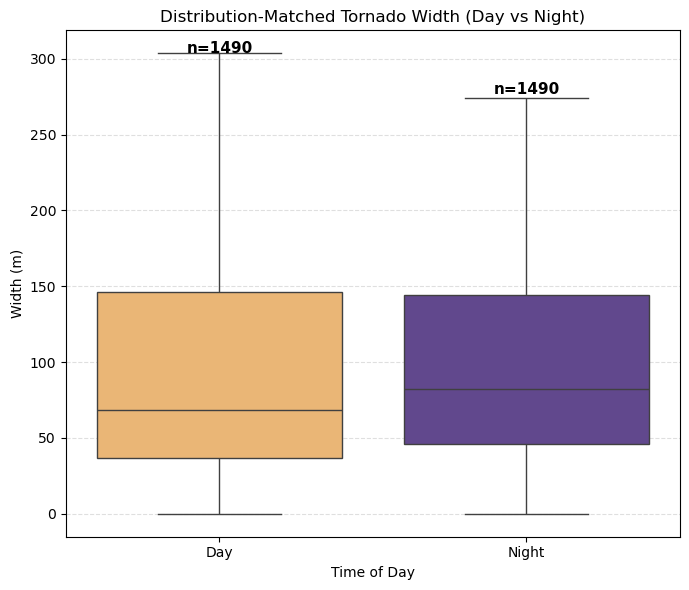

In [58]:
# ================================================================
# MATCHED Tornadoes: Width by Day vs Night
# ================================================================

plot_df = pd.concat([
    matched_day.assign(day_night_bin="Day"),
    night_df.assign(day_night_bin="Night")
]).copy()

# Convert yards → meters (1 yard = 0.9144 m)
plot_df["width_m"] = plot_df["wid"] * 0.9144

plt.figure(figsize=(7,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=plot_df,
    x="day_night_bin",
    y="width_m",
    hue="day_night_bin",
    palette=palette,
    showfliers=False,
    legend=False
)

# ------------------------------------------------
# Tornado counts
# ------------------------------------------------

counts = plot_df["day_night_bin"].value_counts()

print("\nTornado counts (MATCHED):")
print(counts)

# ------------------------------------------------
# Manually position counts
# ------------------------------------------------

positions = {
    "Day": (0, 304),
    "Night": (1, 277)
}

for period,(x,y) in positions.items():

    n = counts.get(period,0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# ------------------------------------------------
# Formatting
# ------------------------------------------------

ax.set_title("Distribution-Matched Tornado Width (Day vs Night)")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [59]:
summary_daynight = (
    plot_df.groupby("day_night_bin")["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary_daynight.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (meters) — MATCHED:")
print(summary_daynight)


Five-number summary (meters) — MATCHED:
               Min      Q1  Median       Q3       Max
day_night_bin                                        
Day            0.0  36.576  68.580  146.304  2404.872
Night          0.0  45.720  82.296  144.018  2414.016


In [60]:
from scipy.stats import kruskal

groups = [
    plot_df[plot_df["day_night_bin"] == "Day"]["width_m"],
    plot_df[plot_df["day_night_bin"] == "Night"]["width_m"]
]

H_stat, p_val = kruskal(*groups)

print("\nKruskal-Wallis Test (MATCHED WIDTH)")
print("-------------------------------------")
print(f"H = {H_stat:.3f}")
print(f"p = {p_val:.6f}")


Kruskal-Wallis Test (MATCHED WIDTH)
-------------------------------------
H = 5.869
p = 0.015411


In [61]:
import itertools

groups = {
    "Day": plot_df[plot_df["day_night_bin"] == "Day"]["width_m"].values,
    "Night": plot_df[plot_df["day_night_bin"] == "Night"]["width_m"].values
}

pairs = list(itertools.combinations(groups.keys(), 2))

results = []

for a, b in pairs:
    try:
        stat, p_val = kruskal(groups[a], groups[b])

        results.append({
            "Group1": a,
            "Group2": b,
            "H": stat,
            "p-value": p_val
        })
    except Exception:
        continue

pairwise_df = pd.DataFrame(results)

# Bonferroni
n_tests = len(pairwise_df)
pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests
pairwise_df["Significant?"] = pairwise_df["p-value"] < 0.05
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Comparisons:")
display(pairwise_df)


Pairwise Comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,Day,Night,5.868839,0.015411,0.015411,True,True


In [62]:
# ================================================================
# Monte Carlo resampling (MATCHED WIDTH)
# ================================================================

n_boot = 10000
np.random.seed(42)

p_values = []
H_values = []

for i in range(n_boot):

    try:
        matched_day = sample_day_to_match_night(day_df, target_counts)

        df_boot = pd.concat([
            matched_day.assign(day_night_bin="Day"),
            night_df.assign(day_night_bin="Night")
        ])

        df_boot["width_m"] = df_boot["wid"] * 0.9144

        groups_boot = [
            df_boot[df_boot["day_night_bin"] == "Day"]["width_m"].values,
            df_boot[df_boot["day_night_bin"] == "Night"]["width_m"].values
        ]

        H_stat, p_boot = kruskal(*groups_boot)

        H_values.append(H_stat)
        p_values.append(p_boot)

    except Exception:
        continue

p_values = np.array(p_values)
H_values = np.array(H_values)

print("\nMonte Carlo Results (MATCHED WIDTH)")
print("--------------------------------------------------")
print(f"Valid iterations: {len(p_values)}")

print("\nP-value statistics:")
print(f"Mean:   {np.mean(p_values):.4f}")
print(f"Median: {np.median(p_values):.4f}")
print(f"Std:    {np.std(p_values):.4f}")
print(f"Fraction p < 0.05: {np.mean(p_values < 0.05):.4f}")

print("\nH-statistics:")
print(f"Mean:   {np.mean(H_values):.3f}")
print(f"Median: {np.median(H_values):.3f}")
print(f"Std:    {np.std(H_values):.3f}")

print("\nSignificance fractions:")
print(np.mean(p_values < 0.10))
print(np.mean(p_values < 0.05))
print(np.mean(p_values < 0.01))
print(np.mean(p_values < 0.001))


Monte Carlo Results (MATCHED WIDTH)
--------------------------------------------------
Valid iterations: 10000

P-value statistics:
Mean:   0.0011
Median: 0.0003
Std:    0.0027
Fraction p < 0.05: 0.9998

H-statistics:
Mean:   13.169
Median: 12.930
Std:    3.423

Significance fractions:
1.0
0.9998
0.9855
0.743


In [63]:
# ================================================================
# Median Difference Analysis (MATCHED WIDTH: Day vs Night)
# ================================================================

median_diffs = []

for i in range(n_boot):

    try:
        # Resample matched Day each iteration
        matched_day = sample_day_to_match_night(day_df, target_counts)

        # Convert to meters
        day_width = matched_day["wid"] * 0.9144
        night_width = night_df["wid"] * 0.9144

        # Compute medians
        median_day = day_width.median()
        median_night = night_width.median()

        # Difference: Night - Day (interpretation direction matters!)
        median_diffs.append(median_night - median_day)

    except Exception:
        continue

median_diffs = np.array(median_diffs)

print("\nMedian Difference Results (WIDTH, meters)")
print("--------------------------------------------------")
print(f"Mean median difference (Night - Day): {np.mean(median_diffs):.3f} m")
print(f"Median of differences: {np.median(median_diffs):.3f} m")
print(f"Std dev: {np.std(median_diffs):.3f} m")

print("\nDirectional signal:")
print(f"Fraction (Night > Day): {np.mean(median_diffs > 0):.4f}")
print(f"Fraction (Night < Day): {np.mean(median_diffs < 0):.4f}")


Median Difference Results (WIDTH, meters)
--------------------------------------------------
Mean median difference (Night - Day): 14.235 m
Median of differences: 13.716 m
Std dev: 1.358 m

Directional signal:
Fraction (Night > Day): 1.0000
Fraction (Night < Day): 0.0000


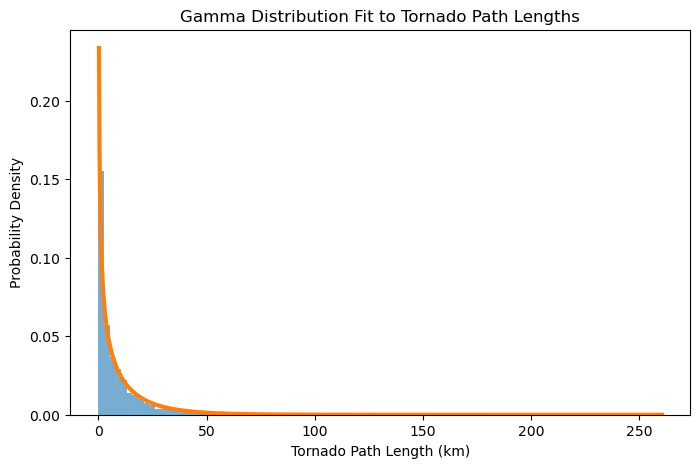

Gamma parameters:
Shape: 0.5408621477817961
Scale: 17.890154375488645


In [64]:
# ================================================================
# Distribution Check: Tornado Path Length with Gamma Fit
# ================================================================

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

tornadoes_all = tornadoes.copy()

# Convert yards → meters
tornadoes_all["len_km"] = tornadoes_all["len"] * 1.60934

data = tornadoes_all["len_km"].dropna()

# Gamma requires positive values
data = data[data > 0]

plt.figure(figsize=(8,5))

# histogram
plt.hist(data, bins=100, density=True, alpha=0.6)

# fit gamma distribution
shape, loc, scale = stats.gamma.fit(data, floc=0)

x = np.linspace(0, data.max(), 1000)
pdf = stats.gamma.pdf(x, shape, loc, scale)

plt.plot(x, pdf, linewidth=3)

plt.xlabel("Tornado Path Length (km)")
plt.ylabel("Probability Density")
plt.title("Gamma Distribution Fit to Tornado Path Lengths")

plt.show()

print("Gamma parameters:")
print("Shape:", shape)
print("Scale:", scale)

#Tornado path lengths exhibit a strongly right-skewed distribution consistent with a gamma-like distribution, 
#supporting the use of nonparametric hypothesis testing methods for group comparisons.

In [65]:
from scipy.stats import skew

print("Skewness:", skew(data))

#Skewness ≈ 4–8 confirms extreme right skewness, which explains why Mann–Whitney & Kruskal–Wallis were the correct tests earlier.

Skewness: 5.430283777905239


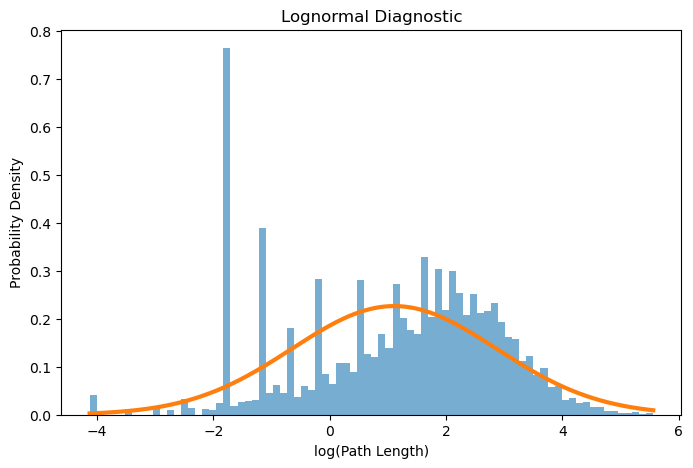

Lognormal parameters:
mu: 1.1093622753878885
sigma: 1.7620131984675638


In [66]:
# ================================================================
# Log-scale Distribution Check
# ================================================================

log_data = np.log(data[data > 0])

plt.figure(figsize=(8,5))

plt.hist(log_data, bins=80, density=True, alpha=0.6)

mu, sigma = stats.norm.fit(log_data)

x = np.linspace(log_data.min(), log_data.max(), 1000)
pdf = stats.norm.pdf(x, mu, sigma)

plt.plot(x, pdf, linewidth=3)

plt.xlabel("log(Path Length)")
plt.ylabel("Probability Density")
plt.title("Lognormal Diagnostic")

plt.show()

print("Lognormal parameters:")
print("mu:", mu)
print("sigma:", sigma)

In [67]:
# ================================================================
# Tornado Count Summary (Day/Night and Side Type)
# ================================================================

# --- Rebuild buffer tornado dataset (372 tornadoes) ---
buffer_tornadoes = pd.concat([west_side, east_side, crossing_tornadoes]).copy()

# Assign side labels
buffer_tornadoes["side_type"] = "Unknown"

buffer_tornadoes.loc[buffer_tornadoes.index.isin(west_side.index), "side_type"] = "West Side"
buffer_tornadoes.loc[buffer_tornadoes.index.isin(east_side.index), "side_type"] = "East Side"
buffer_tornadoes.loc[buffer_tornadoes.index.isin(crossing_tornadoes.index), "side_type"] = "Crossed River"

# ------------------------------------------------
# 1. Total tornado counts (entire dataset)
# ------------------------------------------------

print("\nTotal tornado counts (Day vs Night):")
print(tornadoes["day_night_bin"].value_counts())

print("\nTotal tornadoes:", len(tornadoes))

# ------------------------------------------------
# 2. Buffer tornado counts (should equal 372)
# ------------------------------------------------

print("\nCounts by side type (buffer tornadoes):")
print(buffer_tornadoes["side_type"].value_counts())

print("\nTotal buffer tornadoes:", len(buffer_tornadoes))

# ------------------------------------------------
# 3. Side type × Day/Night breakdown
# ------------------------------------------------

print("\nCounts by side type and day/night:")

side_daynight_counts = buffer_tornadoes.groupby(
    ["side_type","day_night_bin"]
).size()

print(side_daynight_counts)

print("\nCheck total:", side_daynight_counts.sum())


Total tornado counts (Day vs Night):
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64

Total tornadoes: 5793

Counts by side type (buffer tornadoes):
side_type
West Side        142
East Side        141
Crossed River     89
Name: count, dtype: int64

Total buffer tornadoes: 372

Counts by side type and day/night:
side_type      day_night_bin
Crossed River  Day               59
               Night             30
East Side      Day              106
               Night             35
West Side      Day              104
               Night             38
dtype: int64

Check total: 372



Counts used in boxplot:
side_type      day_night_bin
Crossed River  Day               59
               Night             30
East Side      Day              106
               Night             35
West Side      Day              104
               Night             38
dtype: int64


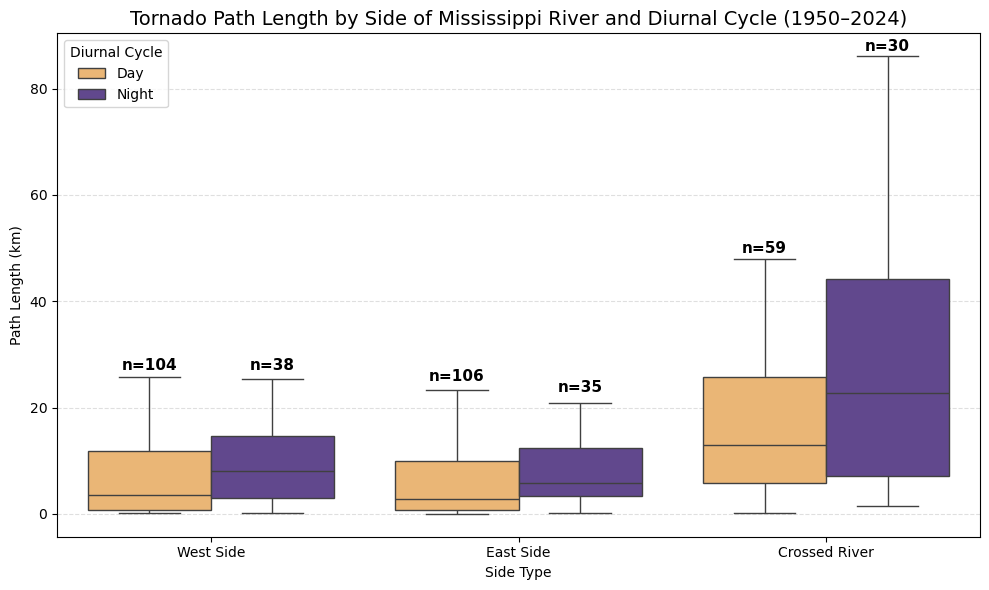


Five-number summary for tornado path lengths (km):

                                  Min        Q1     Median         Q3  \
side_type     day_night_bin                                             
Crossed River Day            0.160934  5.745344  12.874720  25.668973   
              Night          1.384032  7.065003  22.828488  44.264897   
East Side     Day            0.000000  0.671899   2.751971   9.897441   
              Night          0.160934  3.355474   5.793624  12.391918   
West Side     Day            0.064374  0.804670   3.548595  11.909116   
              Night          0.160934  2.953139   8.030607  14.600737   

                                    Max  
side_type     day_night_bin              
Crossed River Day            237.216716  
              Night          180.407014  
East Side     Day             80.467000  
              Night          107.825780  
West Side     Day            147.254610  
              Night          103.319628  


In [70]:
# ================================================================
# Boxplot: Path Length by Side Type and Day/Night (with counts)
# ================================================================

# Ensure path length in km exists
buffer_tornadoes["len_km"] = buffer_tornadoes["len"] * 1.60934

# Ensure side order stays consistent
side_order = ["West Side","East Side","Crossed River"]

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=buffer_tornadoes,
    x="side_type",
    y="len_km",
    hue="day_night_bin",
    order=side_order,
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Path Length by Side of Mississippi River and Diurnal Cycle (1950–2024)",
    fontsize=14
)

ax.set_xlabel("Side Type")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = buffer_tornadoes.groupby(["side_type","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("West Side","Day"):(0-0.2,27),
    ("West Side","Night"):(0+0.2,27),
    ("East Side","Day"):(1-0.2,25),
    ("East Side","Night"):(1+0.2,23),
    ("Crossed River","Day"):(2-0.2,49),
    ("Crossed River","Night"):(2+0.2,87)
}

for (side,period),(x,y) in positions.items():

    n = counts.get((side,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Legend formatting
ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary
# ================================================================

summary = (
    buffer_tornadoes
    .groupby(["side_type","day_night_bin"])["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado path lengths (km):\n")
print(summary)

In [71]:
# ================================================================
# Kruskal-Wallis Test Across Day/Night and Side Type Groups
# ================================================================

# Create combined grouping column
buffer_tornadoes["group"] = (
    buffer_tornadoes["side_type"] + " - " + buffer_tornadoes["day_night_bin"]
)

# Extract pathlength groups
groups = buffer_tornadoes.groupby("group")["len_km"].apply(list)

print("Groups included in test:")
for g in groups.index:
    print(g, "n =", len(groups[g]))

# Kruskal-Wallis test
H, p = kruskal(*groups)

print("\n===================================================")
print("Kruskal-Wallis Test on Tornado Path Lengths")
print("Groups: Side Type × Diurnal Cycle")
print("===================================================")

print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.6f}")

if p < 0.05:
    print("Interpretation: Statistically significant differences exist among the six groups.")
else:
    print("Interpretation: No statistically significant differences detected.")

Groups included in test:
Crossed River - Day n = 59
Crossed River - Night n = 30
East Side - Day n = 106
East Side - Night n = 35
West Side - Day n = 104
West Side - Night n = 38

Kruskal-Wallis Test on Tornado Path Lengths
Groups: Side Type × Diurnal Cycle
Kruskal-Wallis H = 49.260, p = 0.000000
Interpretation: Statistically significant differences exist among the six groups.


In [72]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River - Day,Crossed River - Night,2.063454,1.508679e-01,No
1,Crossed River - Day,East Side - Day,23.599712,1.186052e-06,Yes
2,Crossed River - Day,East Side - Night,7.906695,4.925217e-03,Yes
3,Crossed River - Day,West Side - Day,21.035299,4.508991e-06,Yes
4,Crossed River - Day,West Side - Night,4.562209,3.268488e-02,Yes
5,Crossed River - Night,East Side - Day,24.769106,6.462500e-07,Yes
6,Crossed River - Night,East Side - Night,10.953967,9.340341e-04,Yes
7,Crossed River - Night,West Side - Day,22.319613,2.308369e-06,Yes
8,Crossed River - Night,West Side - Night,7.793551,5.243305e-03,Yes
9,East Side - Day,East Side - Night,3.369674,6.640690e-02,No


In [73]:
# ================================================================
# Bonferroni Correction
# ================================================================

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 15

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise results with Bonferroni correction:")
display(pairwise_df)


Pairwise results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River - Day,Crossed River - Night,2.063454,1.508679e-01,No,2.263018,No
1,Crossed River - Day,East Side - Day,23.599712,1.186052e-06,Yes,0.000018,Yes
2,Crossed River - Day,East Side - Night,7.906695,4.925217e-03,Yes,0.073878,No
3,Crossed River - Day,West Side - Day,21.035299,4.508991e-06,Yes,0.000068,Yes
4,Crossed River - Day,West Side - Night,4.562209,3.268488e-02,Yes,0.490273,No
5,Crossed River - Night,East Side - Day,24.769106,6.462500e-07,Yes,0.000010,Yes
6,Crossed River - Night,East Side - Night,10.953967,9.340341e-04,Yes,0.014011,Yes
7,Crossed River - Night,West Side - Day,22.319613,2.308369e-06,Yes,0.000035,Yes
8,Crossed River - Night,West Side - Night,7.793551,5.243305e-03,Yes,0.078650,No
9,East Side - Day,East Side - Night,3.369674,6.640690e-02,No,0.996104,No


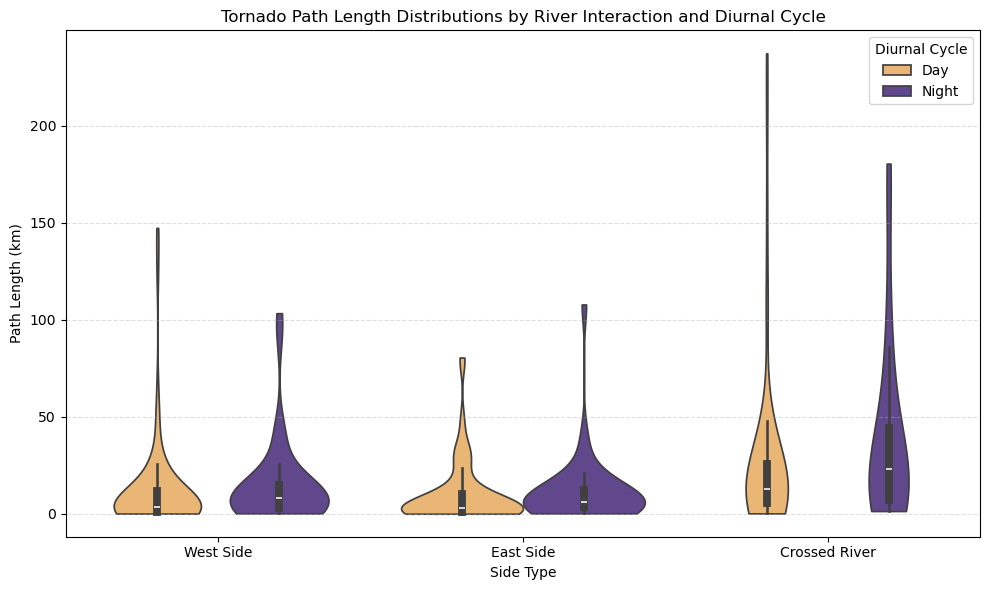

In [74]:
# ================================================================
# Violin Plot with Internal Box: Side Type × Diurnal Cycle
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

sns.violinplot(
    data=buffer_tornadoes,
    x="side_type",
    y="len_km",
    hue="day_night_bin",
    palette=palette,
    inner="box",      # <-- adds boxplot inside violin automatically
    cut=0,
    dodge=True
)

plt.title("Tornado Path Length Distributions by River Interaction and Diurnal Cycle")
plt.xlabel("Side Type")
plt.ylabel("Path Length (km)")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()
plt.show()


Counts used in boxplot:
side_type      day_night_bin
Crossed River  Day               59
               Night             30
East Side      Day              106
               Night             35
West Side      Day              104
               Night             38
dtype: int64


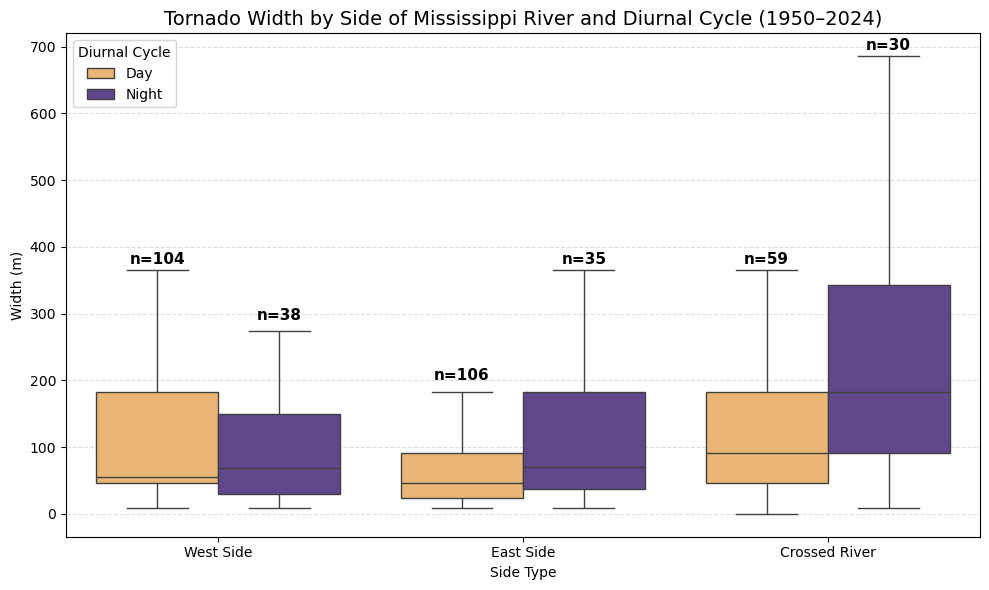


Five-number summary for tornado widths (m):

                               Min      Q1    Median       Q3       Max
side_type     day_night_bin                                            
Crossed River Day            0.000  45.720   91.4400  182.880  2011.680
              Night          9.144  91.440  182.8800  342.900  1005.840
East Side     Day            9.144  24.003   45.7200   91.440   914.400
              Night          9.144  36.576   70.4088  182.880   804.672
West Side     Day            9.144  45.720   54.8640  182.880  1609.344
              Night          9.144  29.718   68.5800  149.733   914.400


In [76]:
# ================================================================
# Boxplot: Width by Side Type and Day/Night (with counts)
# ================================================================

# Convert yards → meters
buffer_tornadoes["width_m"] = buffer_tornadoes["wid"] * 0.9144

# Ensure side order stays consistent
side_order = ["West Side","East Side","Crossed River"]

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

ax = sns.boxplot(
    data=buffer_tornadoes,
    x="side_type",
    y="width_m",
    hue="day_night_bin",
    order=side_order,
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Width by Side of Mississippi River and Diurnal Cycle (1950–2024)",
    fontsize=14
)

ax.set_xlabel("Side Type")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = buffer_tornadoes.groupby(["side_type","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("West Side","Day"):(0-0.2,375),
    ("West Side","Night"):(0+0.2,290),
    ("East Side","Day"):(1-0.2,200),
    ("East Side","Night"):(1+0.2,375),
    ("Crossed River","Day"):(2-0.2,375),
    ("Crossed River","Night"):(2+0.2,695)
}

for (side,period),(x,y) in positions.items():

    n = counts.get((side,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Legend formatting
ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary (WIDTH)
# ================================================================

summary = (
    buffer_tornadoes
    .groupby(["side_type","day_night_bin"])["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado widths (m):\n")
print(summary)

In [77]:
# ================================================================
# Kruskal-Wallis Test Across Day/Night and Side Type Groups (WIDTH)
# ================================================================

buffer_tornadoes["group"] = (
    buffer_tornadoes["side_type"] + " - " + buffer_tornadoes["day_night_bin"]
)

groups = buffer_tornadoes.groupby("group")["width_m"].apply(list)

print("Groups included in test:")
for g in groups.index:
    print(g, "n =", len(groups[g]))

H, p = kruskal(*groups)

print("\n===================================================")
print("Kruskal-Wallis Test on Tornado Widths")
print("Groups: Side Type × Diurnal Cycle")
print("===================================================")

print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.6f}")

if p < 0.05:
    print("Interpretation: Statistically significant differences exist among the six groups.")
else:
    print("Interpretation: No statistically significant differences detected.")

Groups included in test:
Crossed River - Day n = 59
Crossed River - Night n = 30
East Side - Day n = 106
East Side - Night n = 35
West Side - Day n = 104
West Side - Night n = 38

Kruskal-Wallis Test on Tornado Widths
Groups: Side Type × Diurnal Cycle
Kruskal-Wallis H = 31.216, p = 0.000008
Interpretation: Statistically significant differences exist among the six groups.


In [78]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons (WIDTH)
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p_val = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River - Day,Crossed River - Night,3.224406,0.072548,No
1,Crossed River - Day,East Side - Day,16.224199,0.000056,Yes
2,Crossed River - Day,East Side - Night,1.553152,0.212671,No
3,Crossed River - Day,West Side - Day,2.119954,0.145391,No
4,Crossed River - Day,West Side - Night,2.682514,0.101455,No
5,Crossed River - Night,East Side - Day,19.718118,0.000009,Yes
6,Crossed River - Night,East Side - Night,5.946395,0.014747,Yes
7,Crossed River - Night,West Side - Day,7.635468,0.005723,Yes
8,Crossed River - Night,West Side - Night,7.666314,0.005626,Yes
9,East Side - Day,East Side - Night,3.021984,0.082143,No


In [79]:
# ================================================================
# Bonferroni Correction (WIDTH)
# ================================================================

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 15

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise results with Bonferroni correction:")
display(pairwise_df)


Pairwise results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River - Day,Crossed River - Night,3.224406,0.072548,No,1.088221,No
1,Crossed River - Day,East Side - Day,16.224199,0.000056,Yes,0.000844,Yes
2,Crossed River - Day,East Side - Night,1.553152,0.212671,No,3.190060,No
3,Crossed River - Day,West Side - Day,2.119954,0.145391,No,2.180864,No
4,Crossed River - Day,West Side - Night,2.682514,0.101455,No,1.521831,No
5,Crossed River - Night,East Side - Day,19.718118,0.000009,Yes,0.000135,Yes
6,Crossed River - Night,East Side - Night,5.946395,0.014747,Yes,0.221211,No
7,Crossed River - Night,West Side - Day,7.635468,0.005723,Yes,0.085847,No
8,Crossed River - Night,West Side - Night,7.666314,0.005626,Yes,0.084392,No
9,East Side - Day,East Side - Night,3.021984,0.082143,No,1.232144,No


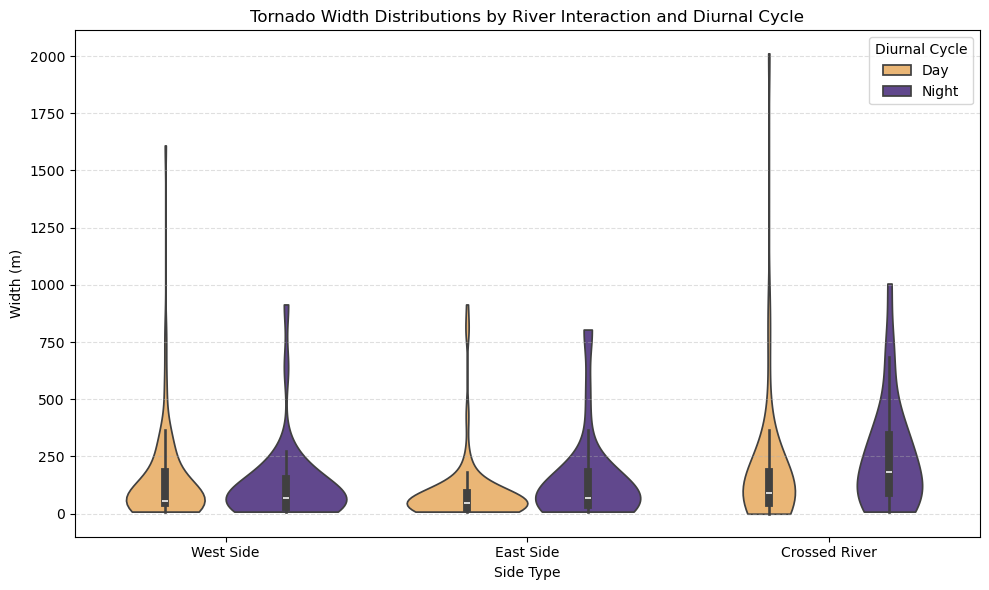

In [80]:
# ================================================================
# Violin Plot: Width by Side Type × Diurnal Cycle
# ================================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=buffer_tornadoes,
    x="side_type",
    y="width_m",
    hue="day_night_bin",
    palette=palette,
    inner="box",
    cut=0,
    dodge=True
)

plt.title("Tornado Width Distributions by River Interaction and Diurnal Cycle")
plt.xlabel("Side Type")
plt.ylabel("Width (m)")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

In [81]:
# ================================================================
# Prepare Dataset: Controls vs Buffer/River
# ================================================================

# --- Copy datasets ---
west_ctrl = west_control.copy()
east_ctrl = east_control.copy()
buffer_group = buffer_tornadoes.copy()

# Assign group labels
west_ctrl["group"] = "West Control"
east_ctrl["group"] = "East Control"
buffer_group["group"] = "Buffer/River"

# Convert miles → km
for df in [west_ctrl, east_ctrl, buffer_group]:
    df["len_km"] = df["len"] * 1.60934

# Combine datasets
compare_df = pd.concat([west_ctrl, east_ctrl, buffer_group], ignore_index=True)

print("Total tornadoes in comparison dataset:", len(compare_df))

print("\nCounts by group:")
print(compare_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_df.groupby(["group","day_night_bin"]).size())

Total tornadoes in comparison dataset: 5793

Counts by group:
group
West Control    3554
East Control    1867
Buffer/River     372
Name: count, dtype: int64

Counts by group and day/night:
group         day_night_bin
Buffer/River  Day               269
              Night             103
East Control  Day              1445
              Night             422
West Control  Day              2589
              Night             965
dtype: int64



Counts used in boxplot:
group         day_night_bin
Buffer/River  Day               269
              Night             103
East Control  Day              1445
              Night             422
West Control  Day              2589
              Night             965
dtype: int64


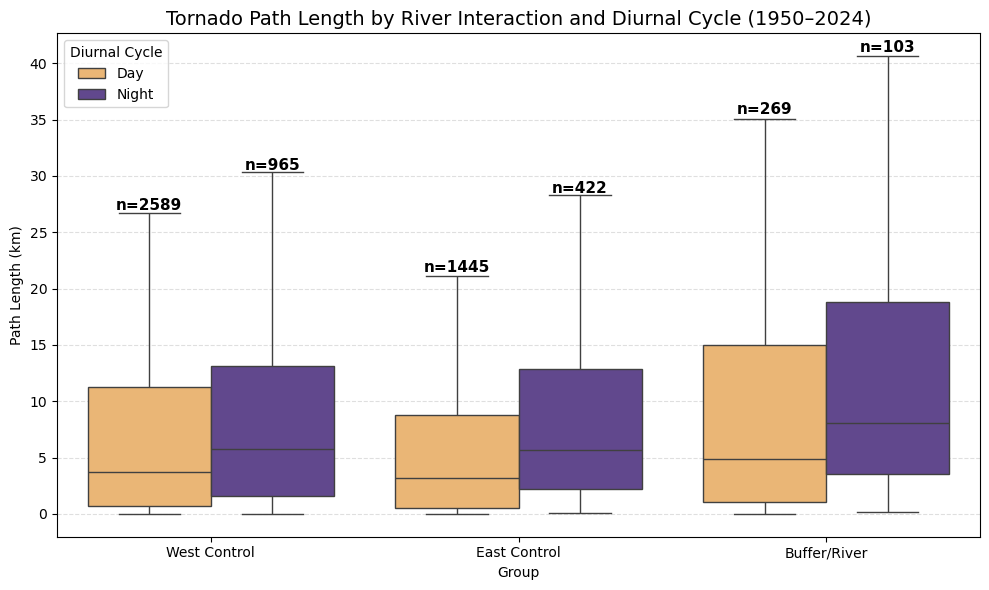

In [82]:
# ================================================================
# Boxplot: Controls vs Buffer/River by Diurnal Cycle
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["West Control","East Control","Buffer/River"]

ax = sns.boxplot(
    data=compare_df,
    x="group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Path Length by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("West Control","Day"):(0-0.2,27),
    ("West Control","Night"):(0+0.2,30.5),
    ("East Control","Day"):(1-0.2,21.5),
    ("East Control","Night"):(1+0.2,28.5),
    ("Buffer/River","Day"):(2-0.2,35.5),
    ("Buffer/River","Night"):(2+0.2,41)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

In [83]:
# ================================================================
# Kruskal-Wallis Test Across All Groups
# ================================================================

from scipy.stats import kruskal

groups = []

labels = []

for grp in ["West Control","East Control","Buffer/River"]:
    for dn in ["Day","Night"]:
        
        subset = compare_df[
            (compare_df["group"] == grp) &
            (compare_df["day_night_bin"] == dn)
        ]["len_km"]
        
        groups.append(subset)
        labels.append(f"{grp} {dn}")

H, p = kruskal(*groups)

print("\nKruskal–Wallis Test on Tornado Path Lengths")
print("------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal–Wallis Test on Tornado Path Lengths
------------------------------------------------
H = 132.729
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [84]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools
from scipy.stats import kruskal

# Create combined group labels
compare_df["group_daynight"] = (
    compare_df["group"] + " " + compare_df["day_night_bin"]
)

# Extract data for each group
groups = compare_df.groupby("group_daynight")["len_km"].apply(list)

# All pairwise combinations
pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Day,Buffer/River Night,9.774175,1.769801e-03,Yes
1,Buffer/River Day,East Control Day,19.317464,1.106893e-05,Yes
2,Buffer/River Day,East Control Night,1.815392,1.778628e-01,No
3,Buffer/River Day,West Control Day,7.175683,7.389830e-03,Yes
4,Buffer/River Day,West Control Night,0.372080,5.418727e-01,No
5,Buffer/River Night,East Control Day,41.113805,1.436184e-10,Yes
6,Buffer/River Night,East Control Night,7.168584,7.419133e-03,Yes
7,Buffer/River Night,West Control Day,27.750578,1.380070e-07,Yes
8,Buffer/River Night,West Control Night,10.773091,1.029864e-03,Yes
9,East Control Day,East Control Night,57.157582,4.022540e-14,Yes


In [85]:
# ================================================================
# Bonferroni Correction
# ================================================================

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 15

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Day,Buffer/River Night,9.774175,1.769801e-03,Yes,2.654701e-02,Yes
1,Buffer/River Day,East Control Day,19.317464,1.106893e-05,Yes,1.660339e-04,Yes
2,Buffer/River Day,East Control Night,1.815392,1.778628e-01,No,2.667942e+00,No
3,Buffer/River Day,West Control Day,7.175683,7.389830e-03,Yes,1.108475e-01,No
4,Buffer/River Day,West Control Night,0.372080,5.418727e-01,No,8.128091e+00,No
5,Buffer/River Night,East Control Day,41.113805,1.436184e-10,Yes,2.154276e-09,Yes
6,Buffer/River Night,East Control Night,7.168584,7.419133e-03,Yes,1.112870e-01,No
7,Buffer/River Night,West Control Day,27.750578,1.380070e-07,Yes,2.070104e-06,Yes
8,Buffer/River Night,West Control Night,10.773091,1.029864e-03,Yes,1.544796e-02,Yes
9,East Control Day,East Control Night,57.157582,4.022540e-14,Yes,6.033810e-13,Yes


In [86]:
# ================================================================
# Prepare Dataset: Controls vs Buffer/River (WIDTH)
# ================================================================

# --- Copy datasets ---
west_ctrl = west_control.copy()
east_ctrl = east_control.copy()
buffer_group = buffer_tornadoes.copy()

# Assign group labels
west_ctrl["group"] = "West Control"
east_ctrl["group"] = "East Control"
buffer_group["group"] = "Buffer/River"

# Convert yards → meters
for df in [west_ctrl, east_ctrl, buffer_group]:
    df["width_m"] = df["wid"] * 0.9144

# Combine datasets
compare_df = pd.concat([west_ctrl, east_ctrl, buffer_group], ignore_index=True)

print("Total tornadoes in comparison dataset:", len(compare_df))

print("\nCounts by group:")
print(compare_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_df.groupby(["group","day_night_bin"]).size())

Total tornadoes in comparison dataset: 5793

Counts by group:
group
West Control    3554
East Control    1867
Buffer/River     372
Name: count, dtype: int64

Counts by group and day/night:
group         day_night_bin
Buffer/River  Day               269
              Night             103
East Control  Day              1445
              Night             422
West Control  Day              2589
              Night             965
dtype: int64



Counts used in boxplot:
group         day_night_bin
Buffer/River  Day               269
              Night             103
East Control  Day              1445
              Night             422
West Control  Day              2589
              Night             965
dtype: int64


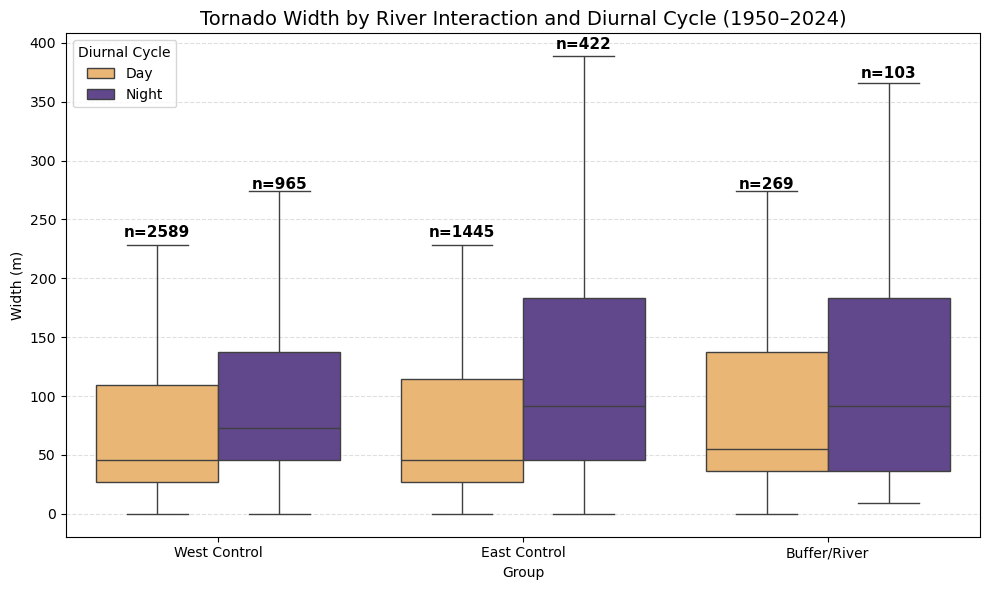

In [87]:
# ================================================================
# Boxplot: Controls vs Buffer/River by Diurnal Cycle (WIDTH)
# ================================================================

# Convert yards → meters
compare_df["width_m"] = compare_df["wid"] * 0.9144

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["West Control","East Control","Buffer/River"]

ax = sns.boxplot(
    data=compare_df,
    x="group",
    y="width_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Width by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("West Control","Day"):(0-0.2,235),
    ("West Control","Night"):(0+0.2,276),
    ("East Control","Day"):(1-0.2,235),
    ("East Control","Night"):(1+0.2,395),
    ("Buffer/River","Day"):(2-0.2,276),
    ("Buffer/River","Night"):(2+0.2,370)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

In [88]:
# ================================================================
# Kruskal-Wallis Test Across All Groups (WIDTH)
# ================================================================

from scipy.stats import kruskal

groups = []
labels = []

for grp in ["West Control","East Control","Buffer/River"]:
    for dn in ["Day","Night"]:
        
        subset = compare_df[
            (compare_df["group"] == grp) &
            (compare_df["day_night_bin"] == dn)
        ]["width_m"]
        
        groups.append(subset)
        labels.append(f"{grp} {dn}")

H, p = kruskal(*groups)

print("\nKruskal–Wallis Test on Tornado Widths")
print("------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal–Wallis Test on Tornado Widths
------------------------------------------------
H = 103.714
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [89]:
# ================================================================
# Bonferroni Correction (WIDTH)
# ================================================================

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * 15

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Day,Buffer/River Night,9.774175,1.769801e-03,Yes,2.654701e-02,Yes
1,Buffer/River Day,East Control Day,19.317464,1.106893e-05,Yes,1.660339e-04,Yes
2,Buffer/River Day,East Control Night,1.815392,1.778628e-01,No,2.667942e+00,No
3,Buffer/River Day,West Control Day,7.175683,7.389830e-03,Yes,1.108475e-01,No
4,Buffer/River Day,West Control Night,0.372080,5.418727e-01,No,8.128091e+00,No
5,Buffer/River Night,East Control Day,41.113805,1.436184e-10,Yes,2.154276e-09,Yes
6,Buffer/River Night,East Control Night,7.168584,7.419133e-03,Yes,1.112870e-01,No
7,Buffer/River Night,West Control Day,27.750578,1.380070e-07,Yes,2.070104e-06,Yes
8,Buffer/River Night,West Control Night,10.773091,1.029864e-03,Yes,1.544796e-02,Yes
9,East Control Day,East Control Night,57.157582,4.022540e-14,Yes,6.033810e-13,Yes


In [90]:
# ================================================================
# Prepare Dataset: Random Controls vs Buffer/River
# ================================================================

west_sample = random_west_control.copy()
east_sample = random_east_control.copy()
buffer_sample = test_population.copy()

west_sample["group"] = "Random West Control"
east_sample["group"] = "Random East Control"
buffer_sample["group"] = "Buffer/River"

# Convert pathlength to km
for df in [west_sample, east_sample, buffer_sample]:
    df["len_km"] = df["len"] * 1.60934

compare_sample_df = pd.concat(
    [west_sample, east_sample, buffer_sample],
    ignore_index=True
)

print("Total tornadoes:", len(compare_sample_df))

print("\nCounts by group:")
print(compare_sample_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_sample_df.groupby(["group","day_night_bin"]).size())

Total tornadoes: 1116

Counts by group:
group
Random West Control    372
Random East Control    372
Buffer/River           372
Name: count, dtype: int64

Counts by group and day/night:
group                day_night_bin
Buffer/River         Day              269
                     Night            103
Random East Control  Day              282
                     Night             90
Random West Control  Day              270
                     Night            102
dtype: int64



Counts used in boxplot:
group                day_night_bin
Buffer/River         Day              269
                     Night            103
Random East Control  Day              282
                     Night             90
Random West Control  Day              270
                     Night            102
dtype: int64


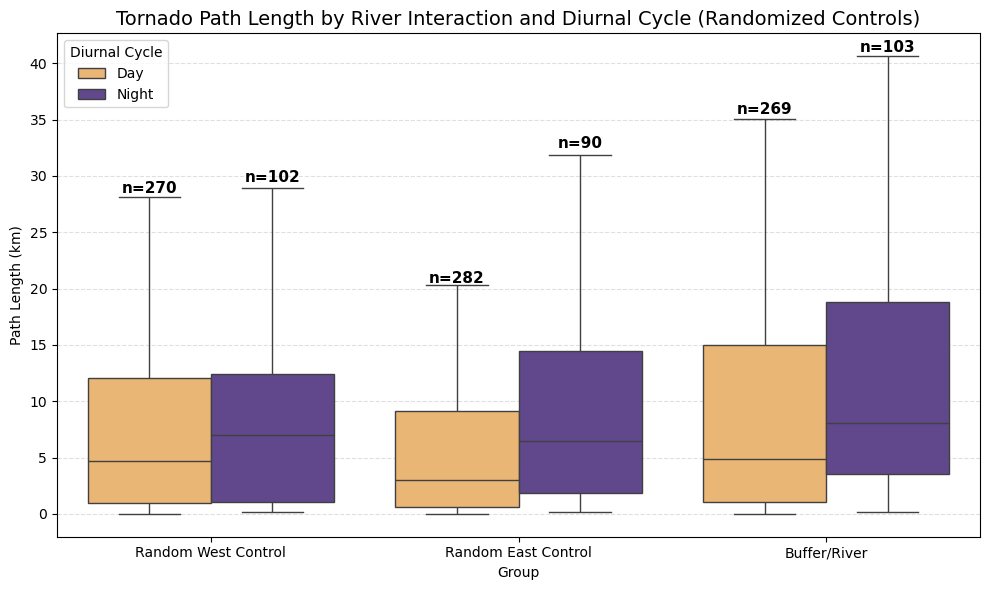


Five-number summary for tornado path lengths (km):

                                        Min        Q1    Median         Q3  \
group               day_night_bin                                            
Buffer/River        Day            0.000000  1.094351  4.828020  14.966862   
                    Night          0.160934  3.580782  8.046700  18.829278   
Random East Control Day            0.000000  0.631666  3.017513   9.104841   
                    Night          0.160934  1.858788  6.437360  14.484060   
Random West Control Day            0.016093  0.925370  4.723413  12.057980   
                    Night          0.160934  1.042048  7.024769  12.456292   

                                          Max  
group               day_night_bin              
Buffer/River        Day            237.216716  
                    Night          180.407014  
Random East Control Day             92.215182  
                    Night          130.356540  
Random West Control Day           

In [91]:
# ================================================================
# Boxplot: Subsampled Controls vs Buffer/River by Diurnal Cycle
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["Random West Control","Random East Control","Buffer/River"]

ax = sns.boxplot(
    data=compare_sample_df,
    x="group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Path Length by River Interaction and Diurnal Cycle (Randomized Controls)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_sample_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("Random West Control","Day"):(0-0.2,28.5),
    ("Random West Control","Night"):(0+0.2,29.5),
    ("Random East Control","Day"):(1-0.2,20.5),
    ("Random East Control","Night"):(1+0.2,32.5),
    ("Buffer/River","Day"):(2-0.2,35.5),
    ("Buffer/River","Night"):(2+0.2,41)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary statistics
# ================================================================

summary = (
    compare_sample_df.groupby(["group","day_night_bin"])["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado path lengths (km):\n")
print(summary)

In [92]:
# ================================================================
# Kruskal-Wallis Test (Subsampled Controls vs Buffer/River)
# ================================================================

from scipy.stats import kruskal

# Create combined group labels
compare_sample_df["group_daynight"] = (
    compare_sample_df["group"] + " " + compare_sample_df["day_night_bin"]
)

# Extract groups
groups = compare_sample_df.groupby("group_daynight")["len_km"].apply(list)

# Run Kruskal-Wallis
H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Path Lengths (Subsampled Controls)")
print("-------------------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Path Lengths (Subsampled Controls)
-------------------------------------------------------------------
H = 39.336
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [93]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Day,Buffer/River Night,9.774175,1.769801e-03,Yes
1,Buffer/River Day,Random East Control Day,10.451544,1.225470e-03,Yes
2,Buffer/River Day,Random East Control Night,1.275964,2.586508e-01,No
3,Buffer/River Day,Random West Control Day,1.850364,1.737410e-01,No
4,Buffer/River Day,Random West Control Night,0.122331,7.265196e-01,No
5,Buffer/River Night,Random East Control Day,31.226132,2.296538e-08,Yes
6,Buffer/River Night,Random East Control Night,2.789307,9.489527e-02,No
7,Buffer/River Night,Random West Control Day,17.471385,2.916648e-05,Yes
8,Buffer/River Night,Random West Control Night,4.806888,2.834619e-02,Yes
9,Random East Control Day,Random East Control Night,13.058707,3.018778e-04,Yes


In [94]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)   # should be 15

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Day,Buffer/River Night,9.774175,1.769801e-03,Yes,2.654701e-02,Yes
1,Buffer/River Day,Random East Control Day,10.451544,1.225470e-03,Yes,1.838204e-02,Yes
2,Buffer/River Day,Random East Control Night,1.275964,2.586508e-01,No,3.879763e+00,No
3,Buffer/River Day,Random West Control Day,1.850364,1.737410e-01,No,2.606115e+00,No
4,Buffer/River Day,Random West Control Night,0.122331,7.265196e-01,No,1.089779e+01,No
5,Buffer/River Night,Random East Control Day,31.226132,2.296538e-08,Yes,3.444807e-07,Yes
6,Buffer/River Night,Random East Control Night,2.789307,9.489527e-02,No,1.423429e+00,No
7,Buffer/River Night,Random West Control Day,17.471385,2.916648e-05,Yes,4.374973e-04,Yes
8,Buffer/River Night,Random West Control Night,4.806888,2.834619e-02,Yes,4.251928e-01,No
9,Random East Control Day,Random East Control Night,13.058707,3.018778e-04,Yes,4.528167e-03,Yes


### Kruskal–Wallis Test on Tornado Path Lengths  
*(Subsampled Control Populations, n = 372 each)*

#### Overall Test

Kruskal–Wallis H = **39.336**, p < **0.000001**

**Interpretation:** At least one of the six groups exhibits statistically significant differences in tornado path length.

The six groups tested were:

- Random West Control — Day  
- Random West Control — Night  
- Random East Control — Day  
- Random East Control — Night  
- Buffer/River — Day  
- Buffer/River — Night  

Because the overall test was statistically significant, pairwise Kruskal–Wallis comparisons were performed to determine which specific groups differed.

---

### Pairwise Kruskal–Wallis Results (Bonferroni Corrected)

| Group 1 | Group 2 | H | p-value | Adjusted p-value | Significant? |
|---|---|---|---|---|---|
| Buffer/River Day | Buffer/River Night | 9.774 | 0.00177 | 0.0265 | Yes |
| Buffer/River Day | Random East Control Day | 10.452 | 0.00123 | 0.0184 | Yes |
| Buffer/River Night | Random East Control Day | 31.226 | 2.30×10⁻⁸ | 3.44×10⁻⁷ | Yes |
| Buffer/River Night | Random West Control Day | 17.471 | 2.92×10⁻⁵ | 0.000437 | Yes |
| Random East Control Day | Random East Control Night | 13.059 | 0.000302 | 0.00453 | Yes |

All remaining pairwise comparisons were **not statistically significant** after applying the Bonferroni correction.

---

### Interpretation

After equalizing sample sizes across groups (n = 372), several statistically significant differences in tornado path length remain.

Within the river-interacting population, **nocturnal tornadoes exhibit significantly longer path lengths than diurnal tornadoes** (p = 0.026 after Bonferroni correction). This suggests enhanced persistence among nighttime tornadoes interacting with the Mississippi River corridor.

River-interacting nocturnal tornadoes also differ significantly from **diurnal tornadoes in both west and east control populations**, indicating that the persistence characteristics of tornadoes interacting with the river environment—particularly at night—are distinct from those occurring away from the river corridor.

Additionally, significant differences between **east-control daytime and nighttime populations** indicate that diurnal variability in tornado persistence exists even outside the river corridor.

Overall, the persistence signal associated with river-interacting tornadoes remains evident even when control populations are randomly subsampled to equal sizes, suggesting that the observed differences are **not simply an artifact of unequal sample sizes**.

In [95]:
# ================================================================
# Prepare Dataset: Random Controls vs Buffer/River (WIDTH)
# ================================================================

west_sample = random_west_control.copy()
east_sample = random_east_control.copy()
buffer_sample = test_population.copy()

west_sample["group"] = "Random West Control"
east_sample["group"] = "Random East Control"
buffer_sample["group"] = "Buffer/River"

# Convert yards → meters
for df in [west_sample, east_sample, buffer_sample]:
    df["width_m"] = df["wid"] * 0.9144

compare_sample_df = pd.concat(
    [west_sample, east_sample, buffer_sample],
    ignore_index=True
)

print("Total tornadoes:", len(compare_sample_df))

print("\nCounts by group:")
print(compare_sample_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_sample_df.groupby(["group","day_night_bin"]).size())

Total tornadoes: 1116

Counts by group:
group
Random West Control    372
Random East Control    372
Buffer/River           372
Name: count, dtype: int64

Counts by group and day/night:
group                day_night_bin
Buffer/River         Day              269
                     Night            103
Random East Control  Day              282
                     Night             90
Random West Control  Day              270
                     Night            102
dtype: int64



Counts used in boxplot:
group                day_night_bin
Buffer/River         Day              269
                     Night            103
Random East Control  Day              282
                     Night             90
Random West Control  Day              270
                     Night            102
dtype: int64


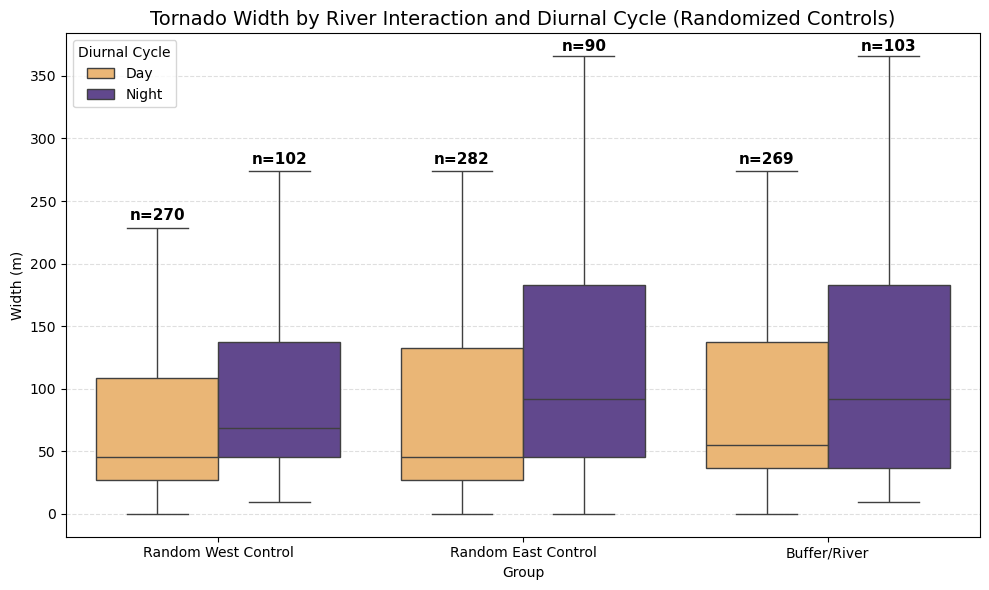


Five-number summary for tornado widths (m):

                                     Min      Q1  Median       Q3       Max
group               day_night_bin                                          
Buffer/River        Day            0.000  36.576  54.864  137.160  2011.680
                    Night          9.144  36.576  91.440  182.880  1005.840
Random East Control Day            0.000  27.432  45.720  132.588  2404.872
                    Night          0.000  45.720  91.440  182.880  1207.008
Random West Control Day            0.000  27.432  45.720  108.585  2377.440
                    Night          9.144  45.720  68.580  137.160  2414.016


In [96]:
# ================================================================
# Boxplot: Subsampled Controls vs Buffer/River by Diurnal Cycle (WIDTH)
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["Random West Control","Random East Control","Buffer/River"]

ax = sns.boxplot(
    data=compare_sample_df,
    x="group",
    y="width_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Width by River Interaction and Diurnal Cycle (Randomized Controls)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_sample_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("Random West Control","Day"):(0-0.2,235),
    ("Random West Control","Night"):(0+0.2,280),
    ("Random East Control","Day"):(1-0.2,280),
    ("Random East Control","Night"):(1+0.2,370),
    ("Buffer/River","Day"):(2-0.2,280),
    ("Buffer/River","Night"):(2+0.2,370)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary statistics (WIDTH)
# ================================================================

summary = (
    compare_sample_df.groupby(["group","day_night_bin"])["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado widths (m):\n")
print(summary)

In [97]:
# ================================================================
# Kruskal-Wallis Test (Subsampled Controls vs Buffer/River, WIDTH)
# ================================================================

from scipy.stats import kruskal

compare_sample_df["group_daynight"] = (
    compare_sample_df["group"] + " " + compare_sample_df["day_night_bin"]
)

groups = compare_sample_df.groupby("group_daynight")["width_m"].apply(list)

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths (Subsampled Controls)")
print("-------------------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Widths (Subsampled Controls)
-------------------------------------------------------------------
H = 19.584
p-value = 0.001495
Interpretation: At least one group differs significantly.


In [98]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons (WIDTH)
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p_val = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Day,Buffer/River Night,3.062809,0.080103,No
1,Buffer/River Day,Random East Control Day,4.161962,0.041341,Yes
2,Buffer/River Day,Random East Control Night,3.571701,0.058772,No
3,Buffer/River Day,Random West Control Day,2.142567,0.143262,No
4,Buffer/River Day,Random West Control Night,0.577791,0.447180,No
5,Buffer/River Night,Random East Control Day,9.197710,0.002423,Yes
6,Buffer/River Night,Random East Control Night,0.004202,0.948318,No
7,Buffer/River Night,Random West Control Day,6.835906,0.008934,Yes
8,Buffer/River Night,Random West Control Night,0.971189,0.324384,No
9,Random East Control Day,Random East Control Night,8.867506,0.002903,Yes


In [99]:
# ================================================================
# Bonferroni Correction (WIDTH)
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Day,Buffer/River Night,3.062809,0.080103,No,1.201546,No
1,Buffer/River Day,Random East Control Day,4.161962,0.041341,Yes,0.620122,No
2,Buffer/River Day,Random East Control Night,3.571701,0.058772,No,0.881581,No
3,Buffer/River Day,Random West Control Day,2.142567,0.143262,No,2.148930,No
4,Buffer/River Day,Random West Control Night,0.577791,0.447180,No,6.707695,No
5,Buffer/River Night,Random East Control Day,9.197710,0.002423,Yes,0.036348,Yes
6,Buffer/River Night,Random East Control Night,0.004202,0.948318,No,14.224769,No
7,Buffer/River Night,Random West Control Day,6.835906,0.008934,Yes,0.134015,No
8,Buffer/River Night,Random West Control Night,0.971189,0.324384,No,4.865758,No
9,Random East Control Day,Random East Control Night,8.867506,0.002903,Yes,0.043544,Yes


### Kruskal–Wallis Test on Tornado Widths  
*(Subsampled Control Populations, n = 372 each)*

#### Overall Test

Kruskal–Wallis H = **19.584**, p = **0.001495**

**Interpretation:** At least one of the six groups exhibits statistically significant differences in tornado width.

The six groups tested were:

- Random West Control — Day  
- Random West Control — Night  
- Random East Control — Day  
- Random East Control — Night  
- Buffer/River — Day  
- Buffer/River — Night  

Because the overall test was statistically significant, pairwise Kruskal–Wallis comparisons were performed to determine which specific groups differed.

---

### Pairwise Kruskal–Wallis Results (Bonferroni Corrected)

| Group 1 | Group 2 | H | p-value | Adjusted p-value | Significant? |
|---|---|---|---|---|---|
| Buffer/River Night | Random East Control Day | 9.198 | 0.00242 | 0.03635 | Yes |
| Random East Control Day | Random East Control Night | 8.868 | 0.00290 | 0.04354 | Yes |

All remaining pairwise comparisons were **not statistically significant** after applying the Bonferroni correction.

---

### Interpretation

After equalizing sample sizes across groups (n = 372), only a limited number of statistically significant differences in tornado width remain.

The strongest signal occurs between **buffer/river nocturnal tornadoes and east-control daytime tornadoes**, where nocturnal river-interacting tornadoes are significantly wider (p = 0.036 after Bonferroni correction). This suggests that nighttime tornadoes interacting with the Mississippi River corridor may exhibit enhanced lateral extent relative to some control populations.

Additionally, a significant difference between **east-control daytime and nighttime tornadoes** (p = 0.044 after correction) indicates that diurnal variability in tornado width exists even away from the river environment.

However, unlike the path length analysis, **no statistically significant difference is detected between diurnal and nocturnal tornadoes within the buffer/river population itself after correction**, indicating that the diurnal signal in width is weaker and less consistent than that observed for path length.

Overall, while some spatial and diurnal differences in tornado width are present, the signal is more limited and less robust than for tornado path length, suggesting that **tornado persistence (length) may be more strongly influenced by environmental factors than lateral size (width)** in this region.

In [100]:
# ================================================================
# Prepare pre-F/F/EF-scale distribution dataset
# ================================================================

west_sample = random_west_control.copy()
east_sample = random_east_control.copy()
buffer_sample = test_population.copy()

west_sample["group"] = "Random West Control"
east_sample["group"] = "Random East Control"
buffer_sample["group"] = "Buffer/River"

intensity_df = pd.concat(
    [west_sample, east_sample, buffer_sample],
    ignore_index=True
)

print("Total tornadoes:", len(intensity_df))

Total tornadoes: 1116


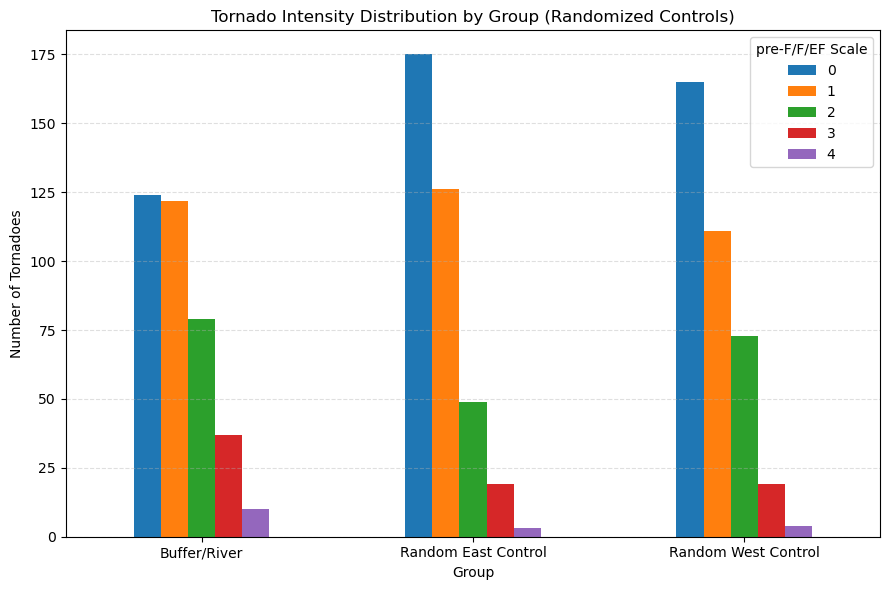


pre-F/F/EF-scale counts:
mag                    0    1   2   3   4
group                                    
Buffer/River         124  122  79  37  10
Random East Control  175  126  49  19   3
Random West Control  165  111  73  19   4


In [101]:
# ================================================================
# pre-F/F/EF-scale distribution by group
# ================================================================

ef_counts = (
    intensity_df.groupby(["group","mag"])
    .size()
    .unstack(fill_value=0)
)

ef_counts = ef_counts[[0,1,2,3,4]]

ax = ef_counts.plot(
    kind="bar",
    figsize=(9,6)
)

ax.set_title("Tornado Intensity Distribution by Group (Randomized Controls)")
ax.set_xlabel("Group")
ax.set_ylabel("Number of Tornadoes")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.legend(title="pre-F/F/EF Scale")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\npre-F/F/EF-scale counts:")
print(ef_counts)

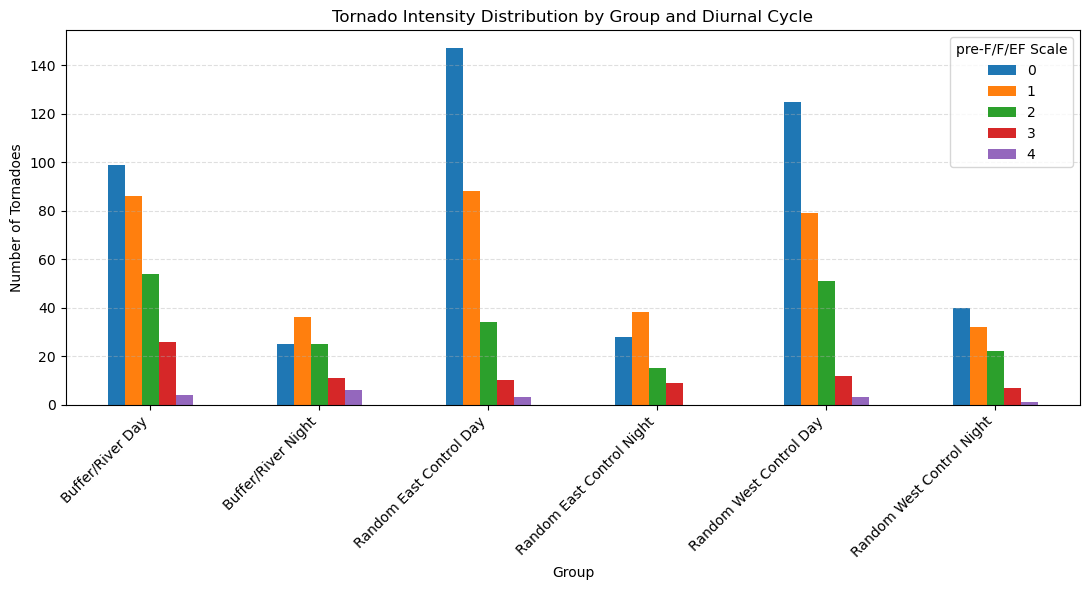


pre-F/F/EF-scale counts by group and day/night:
mag                          0   1   2   3  4
group_daynight                               
Buffer/River Day            99  86  54  26  4
Buffer/River Night          25  36  25  11  6
Random East Control Day    147  88  34  10  3
Random East Control Night   28  38  15   9  0
Random West Control Day    125  79  51  12  3
Random West Control Night   40  32  22   7  1


In [102]:
# ================================================================
# pre-F/F/EF-scale distribution by group and diurnal cycle
# ================================================================

intensity_df["group_daynight"] = (
    intensity_df["group"] + " " + intensity_df["day_night_bin"]
)

ef_counts_dn = (
    intensity_df.groupby(["group_daynight","mag"])
    .size()
    .unstack(fill_value=0)
)

ef_counts_dn = ef_counts_dn[[0,1,2,3,4]]

ax = ef_counts_dn.plot(
    kind="bar",
    figsize=(11,6)
)

ax.set_title("Tornado Intensity Distribution by Group and Diurnal Cycle")
ax.set_xlabel("Group")
ax.set_ylabel("Number of Tornadoes")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.legend(title="pre-F/F/EF Scale")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\npre-F/F/EF-scale counts by group and day/night:")
print(ef_counts_dn)

In [103]:
# ================================================================
# Prepare Dataset: Crossed River vs Random Controls (n = 89 each)
# ================================================================

np.random.seed(42)

# Subsample controls to match crossing tornado count
west_control_89 = west_control.sample(n=89, replace=False, random_state=42).copy()
east_control_89 = east_control.sample(n=89, replace=False, random_state=42).copy()

# Crossing tornadoes (already 89)
crossed_89 = crossing_tornadoes.copy()

# Assign group labels
west_control_89["group"] = "Random West Control"
east_control_89["group"] = "Random East Control"
crossed_89["group"] = "Crossed River"

# Convert path length to km
for df in [west_control_89, east_control_89, crossed_89]:
    df["len_km"] = df["len"] * 1.60934

compare_cross_df = pd.concat(
    [west_control_89, east_control_89, crossed_89],
    ignore_index=True
)

print("Total tornadoes:", len(compare_cross_df))

print("\nCounts by group:")
print(compare_cross_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_cross_df.groupby(["group","day_night_bin"]).size())

Total tornadoes: 267

Counts by group:
group
Random West Control    89
Random East Control    89
Crossed River          89
Name: count, dtype: int64

Counts by group and day/night:
group                day_night_bin
Crossed River        Day              59
                     Night            30
Random East Control  Day              73
                     Night            16
Random West Control  Day              60
                     Night            29
dtype: int64



Counts used in boxplot:
group                day_night_bin
Crossed River        Day              59
                     Night            30
Random East Control  Day              73
                     Night            16
Random West Control  Day              60
                     Night            29
dtype: int64


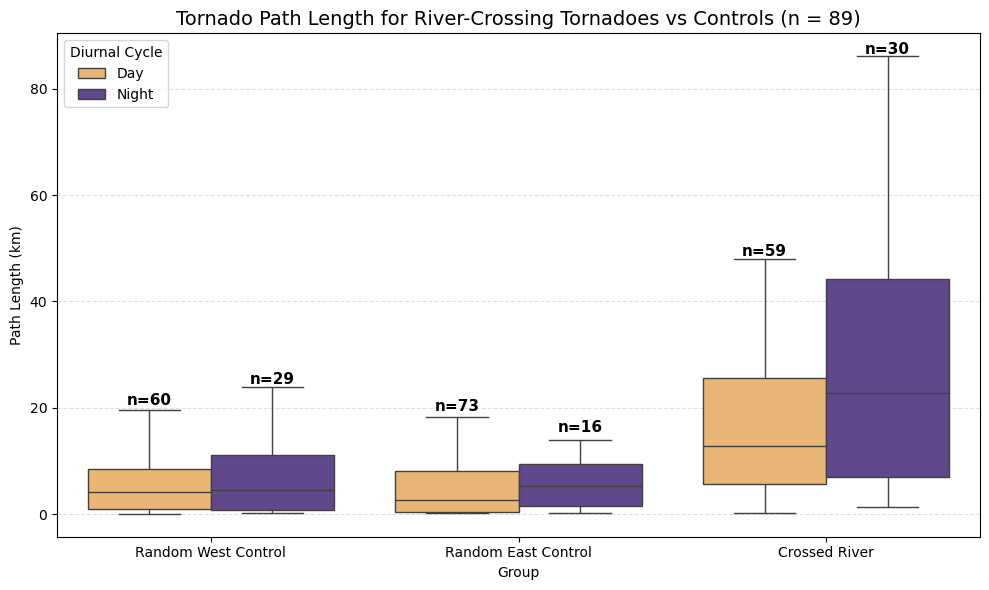


Five-number summary for tornado path lengths (km):

                                        Min        Q1     Median         Q3  \
group               day_night_bin                                             
Crossed River       Day            0.160934  5.745344  12.874720  25.668973   
                    Night          1.384032  7.065003  22.828488  44.264897   
Random East Control Day            0.160934  0.514989   2.768065   8.046700   
                    Night          0.321868  1.528873   5.270588   9.426709   
Random West Control Day            0.080467  0.973651   4.256704   8.428918   
                    Night          0.160934  0.804670   4.634899  11.184913   

                                          Max  
group               day_night_bin              
Crossed River       Day            237.216716  
                    Night          180.407014  
Random East Control Day             48.505508  
                    Night           29.016400  
Random West Control Day   

In [104]:
# ================================================================
# Boxplot: Crossed River vs Controls by Diurnal Cycle
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["Random West Control","Random East Control","Crossed River"]

ax = sns.boxplot(
    data=compare_cross_df,
    x="group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Path Length for River-Crossing Tornadoes vs Controls (n = 89)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_cross_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("Random West Control","Day"):(0-0.2,20.5),
    ("Random West Control","Night"):(0+0.2,24.5),
    ("Random East Control","Day"):(1-0.2,19.5),
    ("Random East Control","Night"):(1+0.2,15.5),
    ("Crossed River","Day"):(2-0.2,48.5),
    ("Crossed River","Night"):(2+0.2,86.5)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

summary = (
    compare_cross_df.groupby(["group","day_night_bin"])["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado path lengths (km):\n")
print(summary)

In [105]:
# ================================================================
# Kruskal-Wallis Test (Crossed River vs Controls, n = 89)
# ================================================================

from scipy.stats import kruskal

# Create combined group labels
compare_cross_df["group_daynight"] = (
    compare_cross_df["group"] + " " + compare_cross_df["day_night_bin"]
)

# Extract groups
groups = compare_cross_df.groupby("group_daynight")["len_km"].apply(list)

# Run Kruskal-Wallis
H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Path Lengths (Crossed River vs Controls)")
print("-------------------------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Path Lengths (Crossed River vs Controls)
-------------------------------------------------------------------------
H = 55.905
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [106]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Day,Crossed River Night,2.063454,1.508679e-01,No
1,Crossed River Day,Random East Control Day,28.046524,1.184337e-07,Yes
2,Crossed River Day,Random East Control Night,8.356746,3.842580e-03,Yes
3,Crossed River Day,Random West Control Day,22.659650,1.933865e-06,Yes
4,Crossed River Day,Random West Control Night,11.412294,7.295969e-04,Yes
5,Crossed River Night,Random East Control Day,28.115676,1.142765e-07,Yes
6,Crossed River Night,Random East Control Night,11.262160,7.910309e-04,Yes
7,Crossed River Night,Random West Control Day,23.310644,1.378351e-06,Yes
8,Crossed River Night,Random West Control Night,14.428718,1.455655e-04,Yes
9,Random East Control Day,Random East Control Night,1.237410,2.659708e-01,No


In [107]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Day,Crossed River Night,2.063454,1.508679e-01,No,2.263018,No
1,Crossed River Day,Random East Control Day,28.046524,1.184337e-07,Yes,0.000002,Yes
2,Crossed River Day,Random East Control Night,8.356746,3.842580e-03,Yes,0.057639,No
3,Crossed River Day,Random West Control Day,22.659650,1.933865e-06,Yes,0.000029,Yes
4,Crossed River Day,Random West Control Night,11.412294,7.295969e-04,Yes,0.010944,Yes
5,Crossed River Night,Random East Control Day,28.115676,1.142765e-07,Yes,0.000002,Yes
6,Crossed River Night,Random East Control Night,11.262160,7.910309e-04,Yes,0.011865,Yes
7,Crossed River Night,Random West Control Day,23.310644,1.378351e-06,Yes,0.000021,Yes
8,Crossed River Night,Random West Control Night,14.428718,1.455655e-04,Yes,0.002183,Yes
9,Random East Control Day,Random East Control Night,1.237410,2.659708e-01,No,3.989561,No


### Kruskal–Wallis Test on Tornado Path Lengths  
*(Crossed River vs. Randomized Control Populations)*

To evaluate whether tornado path lengths differ between river-crossing tornadoes and separate/distant control populations, a Kruskal–Wallis test was conducted across six independent groups: Crossed River (Day and Night), Random West Control (Day and Night), and Random East Control (Day and Night). A nonparametric test was used because tornado path length distributions are highly right-skewed and violate normality assumptions.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 55.905**  
- **p < 0.001**

This result suggests that at least one group exhibits significantly different tornado path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted to determine which specific groups differed. A Bonferroni correction was applied to account for multiple comparisons (15 total tests).

Key findings include:

- **Crossed River tornadoes (both Day and Night) have significantly longer path lengths than all randomized control populations, even after Bonferroni correction.**
- **No statistically significant difference was detected between Crossed River Day and Crossed River Night tornadoes (same as before).**
- **Random West Control and Random East Control populations do not significantly differ from each other during either the daytime or nighttime periods.**

### Interpretation

These results indicate that tornadoes crossing the Mississippi River exhibit significantly greater path lengths compared to nearby control populations located away from the river corridor. This relationship holds for both diurnal and nocturnal events and remains statistically significant after correcting for multiple comparisons.

Importantly, the absence of a statistically significant difference between **Crossed River Day and Crossed River Night tornadoes** suggests that the enhanced persistence of river-crossing tornadoes is not strictly limited to nocturnal events. However, the consistently longer path lengths of river-crossing tornadoes relative to surrounding controls supports the hypothesis that the Mississippi River corridor may influence tornado longevity or structure as storms traverse the river environment.

In [108]:
# ================================================================
# Prepare Dataset: Crossed River vs Random Controls (n = 89 each, WIDTH)
# ================================================================

np.random.seed(42)

# Subsample controls to match crossing tornado count
west_control_89 = west_control.sample(n=89, replace=False, random_state=42).copy()
east_control_89 = east_control.sample(n=89, replace=False, random_state=42).copy()

# Crossing tornadoes (already 89)
crossed_89 = crossing_tornadoes.copy()

# Assign group labels
west_control_89["group"] = "Random West Control"
east_control_89["group"] = "Random East Control"
crossed_89["group"] = "Crossed River"

# Convert yards → meters
for df in [west_control_89, east_control_89, crossed_89]:
    df["width_m"] = df["wid"] * 0.9144

compare_cross_df = pd.concat(
    [west_control_89, east_control_89, crossed_89],
    ignore_index=True
)

print("Total tornadoes:", len(compare_cross_df))

print("\nCounts by group:")
print(compare_cross_df["group"].value_counts())

print("\nCounts by group and day/night:")
print(compare_cross_df.groupby(["group","day_night_bin"]).size())

Total tornadoes: 267

Counts by group:
group
Random West Control    89
Random East Control    89
Crossed River          89
Name: count, dtype: int64

Counts by group and day/night:
group                day_night_bin
Crossed River        Day              59
                     Night            30
Random East Control  Day              73
                     Night            16
Random West Control  Day              60
                     Night            29
dtype: int64



Counts used in boxplot:
group                day_night_bin
Crossed River        Day              59
                     Night            30
Random East Control  Day              73
                     Night            16
Random West Control  Day              60
                     Night            29
dtype: int64


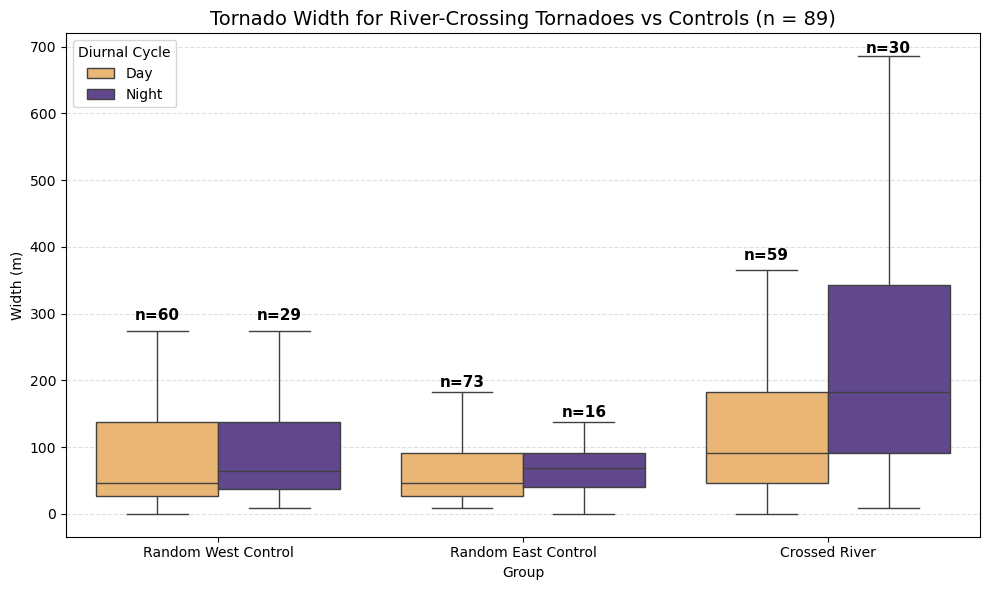


Five-number summary for tornado widths (m):

                                     Min      Q1   Median      Q3        Max
group               day_night_bin                                           
Crossed River       Day            0.000  45.720   91.440  182.88  2011.6800
                    Night          9.144  91.440  182.880  342.90  1005.8400
Random East Control Day            9.144  27.432   45.720   91.44   804.6720
                    Night          0.000  40.005   68.580   91.44   274.3200
Random West Control Day            0.000  27.432   45.720  137.16   609.9048
                    Night          9.144  36.576   64.008  137.16   402.3360


In [109]:
# ================================================================
# Boxplot: Crossed River vs Controls by Diurnal Cycle (WIDTH)
# ================================================================

plt.figure(figsize=(10,6))

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = ["Random West Control","Random East Control","Crossed River"]

ax = sns.boxplot(
    data=compare_cross_df,
    x="group",
    y="width_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Tornado Width for River-Crossing Tornadoes vs Controls (n = 89)",
    fontsize=14
)

ax.set_xlabel("Group")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Compute counts for each group
# ------------------------------------------------

counts = compare_cross_df.groupby(["group","day_night_bin"]).size()

print("\nCounts used in boxplot:")
print(counts)

# ------------------------------------------------
# Add count labels above each box
# ------------------------------------------------

positions = {
    ("Random West Control","Day"):(0-0.2,290),
    ("Random West Control","Night"):(0+0.2,290),
    ("Random East Control","Day"):(1-0.2,190),
    ("Random East Control","Night"):(1+0.2,145),
    ("Crossed River","Day"):(2-0.2,380),
    ("Crossed River","Night"):(2+0.2,690)
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary (WIDTH)
# ================================================================

summary = (
    compare_cross_df.groupby(["group","day_night_bin"])["width_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary for tornado widths (m):\n")
print(summary)

In [110]:
# ================================================================
# Kruskal-Wallis Test (Crossed River vs Controls, WIDTH)
# ================================================================

from scipy.stats import kruskal

compare_cross_df["group_daynight"] = (
    compare_cross_df["group"] + " " + compare_cross_df["day_night_bin"]
)

groups = compare_cross_df.groupby("group_daynight")["width_m"].apply(list)

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths (Crossed River vs Controls)")
print("-------------------------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Widths (Crossed River vs Controls)
-------------------------------------------------------------------------
H = 22.853
p-value = 0.000360
Interpretation: At least one group differs significantly.


In [111]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons (WIDTH)
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p_val = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Day,Crossed River Night,3.224406,0.072548,No
1,Crossed River Day,Random East Control Day,7.715319,0.005475,Yes
2,Crossed River Day,Random East Control Night,2.274285,0.131536,No
3,Crossed River Day,Random West Control Day,7.742828,0.005393,Yes
4,Crossed River Day,Random West Control Night,2.180837,0.139738,No
5,Crossed River Night,Random East Control Day,13.730204,0.000211,Yes
6,Crossed River Night,Random East Control Night,6.933937,0.008458,Yes
7,Crossed River Night,Random West Control Day,12.611439,0.000383,Yes
8,Crossed River Night,Random West Control Night,7.217328,0.007220,Yes
9,Random East Control Day,Random East Control Night,0.101390,0.750168,No


In [112]:
# ================================================================
# Bonferroni Correction (WIDTH)
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Day,Crossed River Night,3.224406,0.072548,No,1.088221,No
1,Crossed River Day,Random East Control Day,7.715319,0.005475,Yes,0.082131,No
2,Crossed River Day,Random East Control Night,2.274285,0.131536,No,1.973036,No
3,Crossed River Day,Random West Control Day,7.742828,0.005393,Yes,0.080889,No
4,Crossed River Day,Random West Control Night,2.180837,0.139738,No,2.096077,No
5,Crossed River Night,Random East Control Day,13.730204,0.000211,Yes,0.003165,Yes
6,Crossed River Night,Random East Control Night,6.933937,0.008458,Yes,0.126863,No
7,Crossed River Night,Random West Control Day,12.611439,0.000383,Yes,0.005751,Yes
8,Crossed River Night,Random West Control Night,7.217328,0.007220,Yes,0.108305,No
9,Random East Control Day,Random East Control Night,0.101390,0.750168,No,11.252521,No


### Kruskal–Wallis Test on Tornado Widths  
*(Crossed River vs. Randomized Control Populations)*

To evaluate whether tornado widths differ between river-crossing tornadoes and separate/distant control populations, a Kruskal–Wallis test was conducted across six independent groups: Crossed River (Day and Night), Random West Control (Day and Night), and Random East Control (Day and Night). A nonparametric test was used because tornado width distributions are highly right-skewed and violate normality assumptions.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 22.853**  
- **p < 0.001**

This result suggests that at least one group exhibits significantly different tornado width characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted to determine which specific groups differed. A Bonferroni correction was applied to account for multiple comparisons (15 total tests).

Key findings include:

- **Crossed River nocturnal tornadoes exhibit significantly greater widths than both Random East Control Day and Random West Control Day tornadoes after Bonferroni correction.**
- **No statistically significant difference was detected between Crossed River Day and Crossed River Night tornadoes.**
- **Most other pairwise differences lose statistical significance after correction, indicating a more limited and selective signal compared to path length results.**
- **Random West Control and Random East Control populations do not significantly differ from one another during either daytime or nighttime periods.**

### Interpretation

These results indicate that tornadoes crossing the Mississippi River exhibit **some enhancement in width**, particularly for **nocturnal events**, but the signal is less consistent than that observed for path length.

Specifically, **river-crossing nocturnal tornadoes are significantly wider than certain daytime control populations**, suggesting that environmental conditions associated with nighttime convection and river interaction may promote broader tornado structures in some cases.

However, the absence of a statistically significant difference between **Crossed River Day and Crossed River Night tornadoes**, along with the loss of significance in many comparisons after Bonferroni correction, indicates that the width signal is **weaker and less robust** than the persistence (path length) signal.

Overall, while river-crossing tornadoes do show evidence of increased width in specific comparisons, particularly at night, the results suggest that **tornado length (persistence) is more strongly influenced by environmental conditions than tornado width (lateral extent)** in this region.


Seasonal sample sizes used:
season  group       
DJF     Buffer/River     45
        East Control     45
        West Control     45
JJA     Buffer/River     82
        East Control     82
        West Control     82
MAM     Buffer/River    208
        East Control    208
        West Control    208
SON     Buffer/River     37
        East Control     37
        West Control     37
dtype: int64

Total tornadoes used in seasonal comparison: 1116


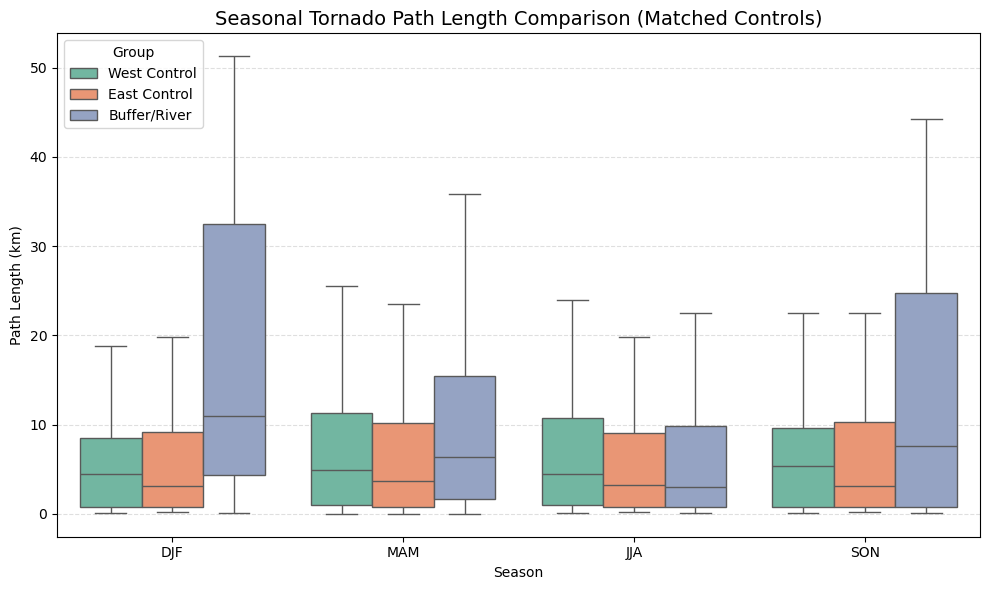

In [113]:
# ================================================================
# Seasonal Comparison: Buffer/River vs Random Controls
# ================================================================

import numpy as np

# ------------------------------------------------
# Assign seasons
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Create buffer/river group
# ------------------------------------------------

buffer_river = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_river["season"] = buffer_river["date"].dt.month.apply(get_season)

# convert pathlength
buffer_river["len_km"] = buffer_river["len"] * 1.60934
west_control["len_km"] = west_control["len"] * 1.60934
east_control["len_km"] = east_control["len"] * 1.60934

# ------------------------------------------------
# Random seed for reproducibility
# ------------------------------------------------

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

for season in seasons:

    # buffer/river tornadoes for season
    buffer_season = buffer_river[buffer_river["season"] == season]

    n = len(buffer_season)

    if n == 0:
        continue

    # sample controls with SAME N
    west_sample = west_control.sample(n=n, random_state=42)
    east_sample = east_control.sample(n=n, random_state=42)

    buffer_season = buffer_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    buffer_season["group"] = "Buffer/River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    buffer_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(buffer_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

season_compare_df = pd.concat(seasonal_df_list)

print("\nSeasonal sample sizes used:")
print(season_compare_df.groupby(["season","group"]).size())
print("\nTotal tornadoes used in seasonal comparison:", len(season_compare_df))

# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(10,6))

palette = {
    "West Control":"#66c2a5",
    "East Control":"#fc8d62",
    "Buffer/River":"#8da0cb"
}

ax = sns.boxplot(
    data=season_compare_df,
    x="season",
    y="len_km",
    hue="group",
    order=["DJF","MAM","JJA","SON"],   # <-- ensures correct order
    hue_order=["West Control","East Control","Buffer/River"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Path Length Comparison (Matched Controls)",
    fontsize=14
)

ax.set_xlabel("Season")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Group")

plt.tight_layout()
plt.show()

In [114]:
# ================================================================
# Force meteorological season order
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_df["season"] = pd.Categorical(
    season_compare_df["season"],
    categories=season_order,
    ordered=True
)

# ================================================================
# Create Combined Season + Group Label
# ================================================================

season_compare_df["season_group"] = (
    season_compare_df["season"].astype(str) + " " + season_compare_df["group"]
)

groups = season_compare_df.groupby("season_group", sort=False)["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['DJF Buffer/River', 'DJF West Control', 'DJF East Control', 'MAM Buffer/River', 'MAM West Control', 'MAM East Control', 'JJA Buffer/River', 'JJA West Control', 'JJA East Control', 'SON Buffer/River', 'SON West Control', 'SON East Control']


In [115]:
# ================================================================
# Kruskal-Wallis Test on Seasonal Tornado Path Lengths
# ================================================================

from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one seasonal group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Path Lengths
------------------------------------------------------
H = 39.350
p-value = 0.000046
Interpretation: At least one seasonal group differs significantly.


In [116]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Buffer/River,DJF West Control,13.454305,0.000244,Yes
1,DJF Buffer/River,DJF East Control,13.997610,0.000183,Yes
2,DJF Buffer/River,MAM Buffer/River,7.275809,0.006989,Yes
3,DJF Buffer/River,MAM West Control,15.274336,0.000093,Yes
4,DJF Buffer/River,MAM East Control,19.541514,0.000010,Yes
...,...,...,...,...,...
61,JJA East Control,SON West Control,0.141617,0.706679,No
62,JJA East Control,SON East Control,0.024078,0.876687,No
63,SON Buffer/River,SON West Control,2.992984,0.083626,No
64,SON Buffer/River,SON East Control,3.500088,0.061366,No


In [117]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Buffer/River,DJF West Control,13.454305,0.000244,Yes,0.016133,Yes
1,DJF Buffer/River,DJF East Control,13.997610,0.000183,Yes,0.012081,Yes
2,DJF Buffer/River,MAM Buffer/River,7.275809,0.006989,Yes,0.461270,No
3,DJF Buffer/River,MAM West Control,15.274336,0.000093,Yes,0.006136,Yes
4,DJF Buffer/River,MAM East Control,19.541514,0.000010,Yes,0.000650,Yes
...,...,...,...,...,...,...,...
61,JJA East Control,SON West Control,0.141617,0.706679,No,46.640830,No
62,JJA East Control,SON East Control,0.024078,0.876687,No,57.861343,No
63,SON Buffer/River,SON West Control,2.992984,0.083626,No,5.519311,No
64,SON Buffer/River,SON East Control,3.500088,0.061366,No,4.050128,No


In [118]:
# ================================================================
# Extract Only Bonferroni-Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[["Group1","Group2","H","p-value","Adj p-value (Bonferroni)"]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
0,DJF Buffer/River,DJF West Control,13.454305,0.000244,0.016133
1,DJF Buffer/River,DJF East Control,13.997610,0.000183,0.012081
3,DJF Buffer/River,MAM West Control,15.274336,0.000093,0.006136
4,DJF Buffer/River,MAM East Control,19.541514,0.000010,0.000650
5,DJF Buffer/River,JJA Buffer/River,18.253941,0.000019,0.001276
6,DJF Buffer/River,JJA West Control,15.821227,0.000070,0.004595
7,DJF Buffer/River,JJA East Control,19.352652,0.000011,0.000717
10,DJF Buffer/River,SON East Control,12.976799,0.000315,0.020815


### Seasonal Comparison of Tornado Path Lengths

A Kruskal–Wallis test was conducted to evaluate whether tornado path lengths differ among seasonal populations of river-interacting tornadoes and matched control populations. Twelve independent groups were included in the analysis, representing Buffer/River tornadoes and randomly subsampled West and East control populations for each meteorological season (DJF, MAM, JJA, SON).

The Kruskal–Wallis test indicated a statistically significant difference among the seasonal groups:

- **H = 39.350**
- **p < 0.001**

This result indicates that at least one seasonal population exhibits significantly different tornado path length characteristics.

---

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted between all seasonal groups. Because a total of **66 comparisons** were performed, a **Bonferroni correction** was applied to control the family-wise error rate.

The following comparisons remained statistically significant after the Bonferroni correction:

- **DJF Buffer/River vs DJF West Control** (H = 13.45, adj. p = 0.016)
- **DJF Buffer/River vs DJF East Control** (H = 13.99, adj. p = 0.012)
- **DJF Buffer/River vs MAM West Control** (H = 15.27, adj. p = 0.006)
- **DJF Buffer/River vs MAM East Control** (H = 19.54, adj. p < 0.001)
- **DJF Buffer/River vs JJA Buffer/River** (H = 18.25, adj. p = 0.001)
- **DJF Buffer/River vs JJA West Control** (H = 15.82, adj. p = 0.005)
- **DJF Buffer/River vs JJA East Control** (H = 19.35, adj. p < 0.001)
- **DJF Buffer/River vs SON East Control** (H = 12.98, adj. p = 0.021)

---

### Interpretation

These results indicate that **winter (DJF) tornadoes interacting with the Mississippi River corridor exhibit significantly longer path lengths than multiple control populations**, including both West and East controls from several seasons. In addition, DJF Buffer/River tornadoes differ significantly from JJA Buffer/River tornadoes, suggesting that the persistence of river-interacting tornadoes may vary seasonally.

Most comparisons involving the control populations themselves were not statistically significant after the Bonferroni correction, indicating relatively similar tornado path length distributions away from the river corridor. Overall, the results reinforce earlier analyses suggesting that tornadoes interacting with the Mississippi River environment tend to exhibit enhanced path length characteristics, particularly during the cool-season months.


Seasonal sample sizes used:
season  group       
DJF     Buffer/River     45
        East Control     45
        West Control     45
JJA     Buffer/River     82
        East Control     82
        West Control     82
MAM     Buffer/River    208
        East Control    208
        West Control    208
SON     Buffer/River     37
        East Control     37
        West Control     37
dtype: int64

Total tornadoes used in seasonal comparison: 1116


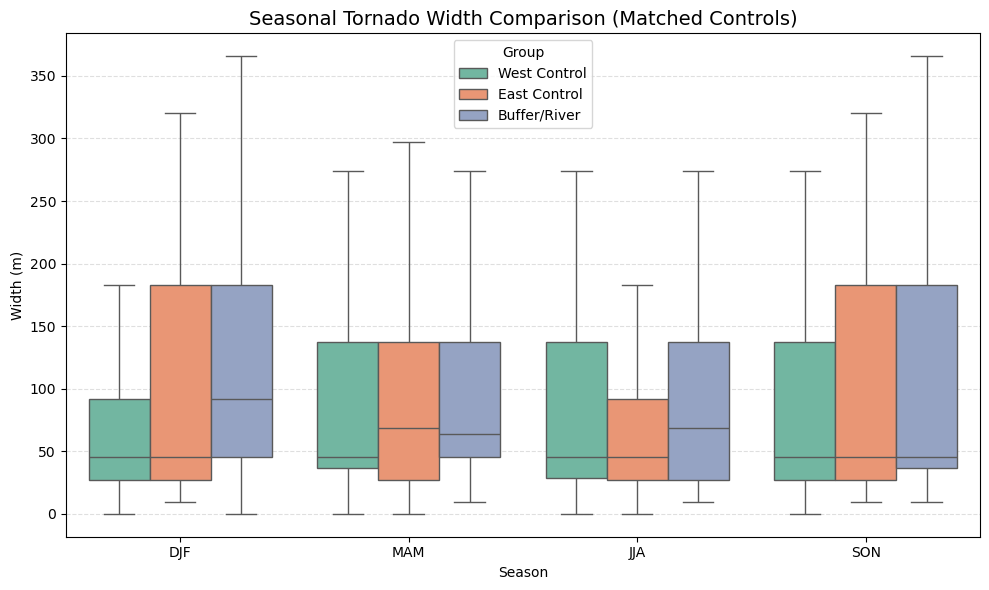

In [119]:
# ================================================================
# Seasonal Comparison: Buffer/River vs Random Controls (WIDTH)
# ================================================================

import numpy as np

# ------------------------------------------------
# Assign seasons
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Create buffer/river group
# ------------------------------------------------

buffer_river = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_river["season"] = buffer_river["date"].dt.month.apply(get_season)

# Convert yards → meters
buffer_river["width_m"] = buffer_river["wid"] * 0.9144
west_control["width_m"] = west_control["wid"] * 0.9144
east_control["width_m"] = east_control["wid"] * 0.9144

# ------------------------------------------------
# Random seed for reproducibility
# ------------------------------------------------

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

for season in seasons:

    # buffer/river tornadoes for season
    buffer_season = buffer_river[buffer_river["season"] == season]

    n = len(buffer_season)

    if n == 0:
        continue

    # sample controls with SAME N
    west_sample = west_control.sample(n=n, random_state=42)
    east_sample = east_control.sample(n=n, random_state=42)

    buffer_season = buffer_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    buffer_season["group"] = "Buffer/River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    buffer_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(buffer_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

season_compare_df = pd.concat(seasonal_df_list)

print("\nSeasonal sample sizes used:")
print(season_compare_df.groupby(["season","group"]).size())

print("\nTotal tornadoes used in seasonal comparison:", len(season_compare_df))

# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(10,6))

palette = {
    "West Control":"#66c2a5",
    "East Control":"#fc8d62",
    "Buffer/River":"#8da0cb"
}

ax = sns.boxplot(
    data=season_compare_df,
    x="season",
    y="width_m",
    hue="group",
    order=["DJF","MAM","JJA","SON"],
    hue_order=["West Control","East Control","Buffer/River"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Width Comparison (Matched Controls)",
    fontsize=14
)

ax.set_xlabel("Season")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Group")

plt.tight_layout()
plt.show()

In [120]:
# ================================================================
# Force meteorological season order
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_df["season"] = pd.Categorical(
    season_compare_df["season"],
    categories=season_order,
    ordered=True
)

# ================================================================
# Create Combined Season + Group Label
# ================================================================

season_compare_df["season_group"] = (
    season_compare_df["season"].astype(str) + " " + season_compare_df["group"]
)

groups = season_compare_df.groupby("season_group", sort=False)["width_m"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['DJF Buffer/River', 'DJF West Control', 'DJF East Control', 'MAM Buffer/River', 'MAM West Control', 'MAM East Control', 'JJA Buffer/River', 'JJA West Control', 'JJA East Control', 'SON Buffer/River', 'SON West Control', 'SON East Control']


In [121]:
# ================================================================
# Kruskal-Wallis Test on Seasonal Tornado Widths
# ================================================================

from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one seasonal group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Widths
------------------------------------------------------
H = 10.154
p-value = 0.516609
Interpretation: No statistically significant differences detected.


In [122]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:
    
    stat, p_val = kruskal(groups[a], groups[b])
    
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Buffer/River,DJF West Control,4.372153,0.036531,Yes
1,DJF Buffer/River,DJF East Control,1.838654,0.175109,No
2,DJF Buffer/River,MAM Buffer/River,0.769241,0.380452,No
3,DJF Buffer/River,MAM West Control,1.790683,0.180843,No
4,DJF Buffer/River,MAM East Control,1.789965,0.180930,No
...,...,...,...,...,...
61,JJA East Control,SON West Control,0.152046,0.696588,No
62,JJA East Control,SON East Control,0.039995,0.841491,No
63,SON Buffer/River,SON West Control,1.214693,0.270405,No
64,SON Buffer/River,SON East Control,0.274087,0.600603,No


In [123]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Buffer/River,DJF West Control,4.372153,0.036531,Yes,2.411034,No
1,DJF Buffer/River,DJF East Control,1.838654,0.175109,No,11.557179,No
2,DJF Buffer/River,MAM Buffer/River,0.769241,0.380452,No,25.109830,No
3,DJF Buffer/River,MAM West Control,1.790683,0.180843,No,11.935635,No
4,DJF Buffer/River,MAM East Control,1.789965,0.180930,No,11.941406,No
...,...,...,...,...,...,...,...
61,JJA East Control,SON West Control,0.152046,0.696588,No,45.974808,No
62,JJA East Control,SON East Control,0.039995,0.841491,No,55.538420,No
63,SON Buffer/River,SON West Control,1.214693,0.270405,No,17.846712,No
64,SON Buffer/River,SON East Control,0.274087,0.600603,No,39.639824,No


In [124]:
# ================================================================
# Extract Only Bonferroni-Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[["Group1","Group2","H","p-value","Adj p-value (Bonferroni)"]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


### Seasonal Comparison of Tornado Widths

A Kruskal–Wallis test was conducted to evaluate whether tornado widths differ among seasonal populations of river-interacting tornadoes and matched control populations. Twelve independent groups were included in the analysis, representing Buffer/River tornadoes and randomly subsampled West and East control populations for each meteorological season (DJF, MAM, JJA, SON).

The Kruskal–Wallis test did **not** indicate a statistically significant difference among the seasonal groups:

- **H = 10.154**
- **p = 0.517**

**Interpretation:**  
There is no statistically significant evidence that tornado width distributions differ across seasons when comparing river-interacting and control populations.

---

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted between all seasonal groups (66 total comparisons). A Bonferroni correction was applied to control the family-wise error rate.

- Several comparisons (e.g., **DJF Buffer/River vs DJF West Control**, p = 0.037) were significant at the *uncorrected* level.
- However, **no comparisons remained statistically significant after Bonferroni correction**.

---

### Interpretation

Unlike the path length analysis, the seasonal comparison of tornado widths shows **no robust statistically significant differences** across either seasonal or spatial groupings after accounting for multiple comparisons.

While a small number of differences appear at the uncorrected level—primarily involving **winter (DJF) buffer/river tornadoes versus control populations**—these do not persist after applying a strict correction for multiple testing. This suggests that such differences may be due to sampling variability rather than a consistent physical signal.

Overall, these results indicate that **tornado width does not exhibit strong seasonal dependence in relation to the Mississippi River corridor**, in contrast to the clearer and more robust seasonal signals observed in tornado path length.

This reinforces a broader conclusion from earlier analyses:

> **Tornado persistence (path length) appears to be more sensitive to environmental variability—both spatial and seasonal—than tornado width (lateral extent).**

In [125]:
# ================================================================
# Assign seasons
# ================================================================

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ================================================================
# Create BUFFER/RIVER dataset
# ================================================================

buffer_river = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
]).copy()

buffer_river["season"] = (
    buffer_river["date"].dt.month.apply(get_season)
)

# ================================================================
# Convert path length to km
# ================================================================

buffer_river["len_km"] = buffer_river["len"] * 1.60934
west_control["len_km"] = west_control["len"] * 1.60934
east_control["len_km"] = east_control["len"] * 1.60934

# ================================================================
# Random seed
# ================================================================

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

# ================================================================
# Match controls to Buffer/River counts by season
# ================================================================

for season in seasons:

    buffer_season = buffer_river[
        buffer_river["season"] == season
    ]

    n = len(buffer_season)

    if n == 0:
        continue

    # Match sample size
    west_sample = west_control.sample(
        n=n,
        random_state=42
    )

    east_sample = east_control.sample(
        n=n,
        random_state=42
    )

    buffer_season = buffer_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    buffer_season["group"] = "Buffer/River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    buffer_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(buffer_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

# ================================================================
# Combine
# ================================================================

season_compare_df = pd.concat(
    seasonal_df_list,
    ignore_index=True
)

print("\nSeasonal sample sizes used:")
print(
    season_compare_df.groupby(
        ["season","group"]
    ).size()
)

print(
    "\nTotal tornadoes used in seasonal comparison:",
    len(season_compare_df)
)

# ================================================================
# Force season order
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_df["season"] = pd.Categorical(
    season_compare_df["season"],
    categories=season_order,
    ordered=True
)

# ================================================================
# Create plotting label
# ================================================================

season_compare_df["season_group"] = (
    season_compare_df["season"].astype(str)
    + "\n"
    + season_compare_df["group"]
)

# ================================================================
# Plotting order
# ================================================================

order = [
    "DJF\nWest Control",
    "DJF\nEast Control",
    "DJF\nBuffer/River",

    "MAM\nWest Control",
    "MAM\nEast Control",
    "MAM\nBuffer/River",

    "JJA\nWest Control",
    "JJA\nEast Control",
    "JJA\nBuffer/River",

    "SON\nWest Control",
    "SON\nEast Control",
    "SON\nBuffer/River",
]

# ================================================================
# Counts
# ================================================================

print("\nCounts used in seasonal diurnal boxplot:\n")

counts = season_compare_df.groupby(
    ["season","group","day_night_bin"]
).size()

print(counts)



Seasonal sample sizes used:
season  group       
DJF     Buffer/River     45
        East Control     45
        West Control     45
JJA     Buffer/River     82
        East Control     82
        West Control     82
MAM     Buffer/River    208
        East Control    208
        West Control    208
SON     Buffer/River     37
        East Control     37
        West Control     37
dtype: int64

Total tornadoes used in seasonal comparison: 1116

Counts used in seasonal diurnal boxplot:

season  group         day_night_bin
DJF     Buffer/River  Day               21
                      Night             24
        East Control  Day               37
                      Night              8
        West Control  Day               30
                      Night             15
MAM     Buffer/River  Day              152
                      Night             56
        East Control  Day              158
                      Night             50
        West Control  Day              14

/tmp/ipykernel_1435/2491464580.py:162: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



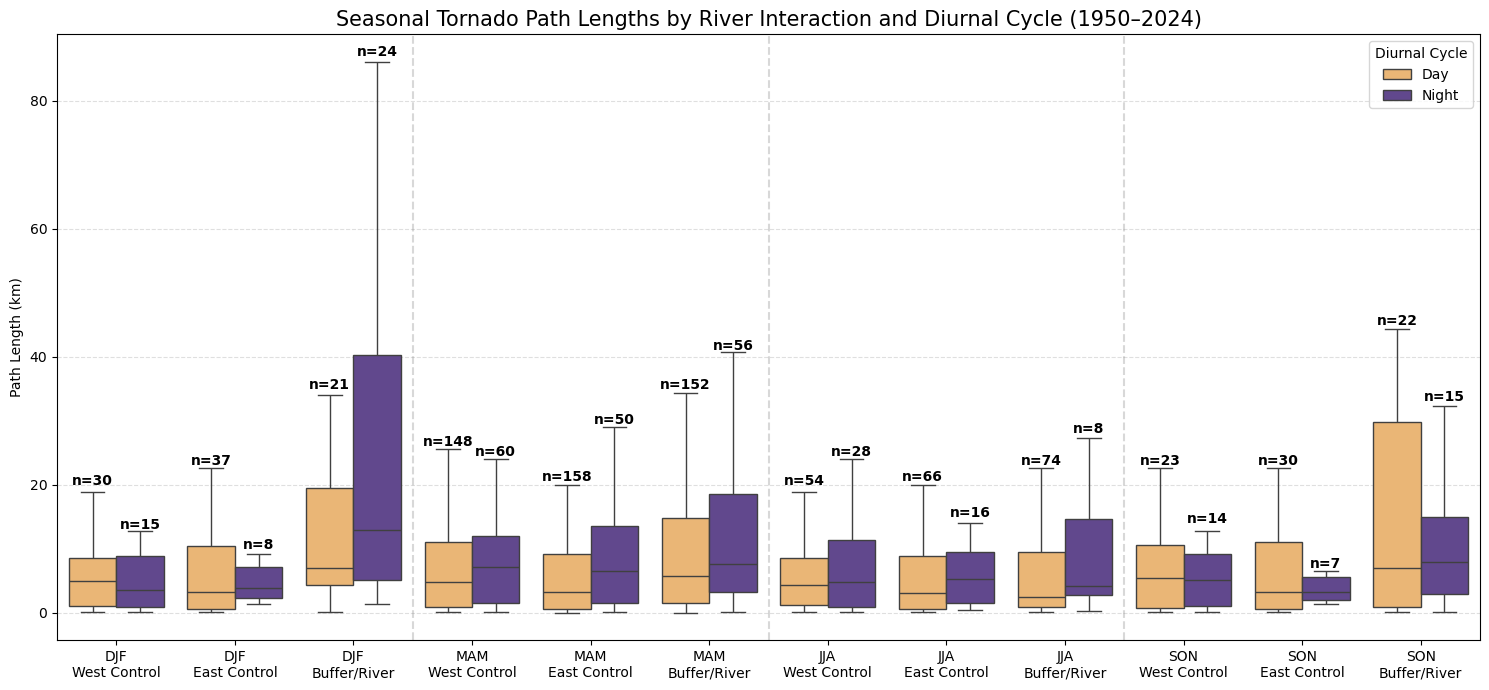

In [126]:
# ================================================================
# Boxplot
# ================================================================

plt.figure(figsize=(15,7))

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

ax = sns.boxplot(
    data=season_compare_df,
    x="season_group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

# ================================================================
# Formatting
# ================================================================

ax.set_title(
    "Seasonal Tornado Path Lengths by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# ================================================================
# Add counts
# ================================================================

positions = {

# DJF
("DJF","West Control","Day"):(0-0.2,20),
("DJF","West Control","Night"):(0+0.2,13),
("DJF","East Control","Day"):(1-0.2,23),
("DJF","East Control","Night"):(1+0.2,10),
("DJF","Buffer/River","Day"):(2-0.2,35),
("DJF","Buffer/River","Night"):(2+0.2,87),

# MAM
("MAM","West Control","Day"):(3-0.2,26),
("MAM","West Control","Night"):(3+0.2,24.5),
("MAM","East Control","Day"):(4-0.2,20.5),
("MAM","East Control","Night"):(4+0.2,29.5),
("MAM","Buffer/River","Day"):(5-0.2,35),
("MAM","Buffer/River","Night"):(5+0.2,41),

# JJA
("JJA","West Control","Day"):(6-0.2,20),
("JJA","West Control","Night"):(6+0.2,24.5),
("JJA","East Control","Day"):(7-0.2,20.5),
("JJA","East Control","Night"):(7+0.2,15),
("JJA","Buffer/River","Day"):(8-0.2,23),
("JJA","Buffer/River","Night"):(8+0.2,28),

# SON
("SON","West Control","Day"):(9-0.2,23),
("SON","West Control","Night"):(9+0.2,14),
("SON","East Control","Day"):(10-0.2,23),
("SON","East Control","Night"):(10+0.2,7),
("SON","Buffer/River","Day"):(11-0.2,45),
("SON","Buffer/River","Night"):(11+0.2,33)

}

for (season,group,period),(x,y) in positions.items():

    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ================================================================
# Legend + separators
# ================================================================

ax.legend(title="Diurnal Cycle")

for x in [2.5,5.5,8.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [127]:
# ================================================================
# Create Combined Season + Group + Diurnal Label
# ================================================================

season_compare_df["season_group_dn"] = (
    season_compare_df["season"].astype(str) + " " +
    season_compare_df["group"] + " " +
    season_compare_df["day_night_bin"]
)

groups = season_compare_df.groupby(
    "season_group_dn", sort=False, observed=False
)["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['DJF Buffer/River Night', 'DJF Buffer/River Day', 'DJF West Control Night', 'DJF West Control Day', 'DJF East Control Day', 'DJF East Control Night', 'MAM Buffer/River Day', 'MAM Buffer/River Night', 'MAM West Control Night', 'MAM West Control Day', 'MAM East Control Day', 'MAM East Control Night', 'JJA Buffer/River Night', 'JJA Buffer/River Day', 'JJA West Control Night', 'JJA West Control Day', 'JJA East Control Day', 'JJA East Control Night', 'SON Buffer/River Day', 'SON Buffer/River Night', 'SON West Control Night', 'SON West Control Day', 'SON East Control Day', 'SON East Control Night']


In [128]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Path Lengths
------------------------------------------------------
H = 50.981
p-value = 0.000684
Interpretation: At least one group differs significantly.


In [129]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Buffer/River Night,DJF Buffer/River Day,1.481789,0.223495,No
1,DJF Buffer/River Night,DJF West Control Night,8.671755,0.003232,Yes
2,DJF Buffer/River Night,DJF West Control Day,11.642987,0.000644,Yes
3,DJF Buffer/River Night,DJF East Control Day,13.098281,0.000296,Yes
4,DJF Buffer/River Night,DJF East Control Night,5.626505,0.017691,Yes
...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.063757,0.800653,No
272,SON West Control Night,SON East Control Night,0.050158,0.822789,No
273,SON West Control Day,SON East Control Day,0.013626,0.907074,No
274,SON West Control Day,SON East Control Night,0.038512,0.844418,No


In [130]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Buffer/River Night,DJF Buffer/River Day,1.481789,0.223495,No,61.684585,No
1,DJF Buffer/River Night,DJF West Control Night,8.671755,0.003232,Yes,0.891976,No
2,DJF Buffer/River Night,DJF West Control Day,11.642987,0.000644,Yes,0.177868,No
3,DJF Buffer/River Night,DJF East Control Day,13.098281,0.000296,Yes,0.081576,No
4,DJF Buffer/River Night,DJF East Control Night,5.626505,0.017691,Yes,4.882681,No
...,...,...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.063757,0.800653,No,220.980291,No
272,SON West Control Night,SON East Control Night,0.050158,0.822789,No,227.089691,No
273,SON West Control Day,SON East Control Day,0.013626,0.907074,No,250.352550,No
274,SON West Control Day,SON East Control Night,0.038512,0.844418,No,233.059490,No


In [131]:
# ================================================================
# Extract First, Only Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()

print("All significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

All significant comparisons:


,Group1,Group2,H,p-value
1,DJF Buffer/River Night,DJF West Control Night,8.671755,0.003232
2,DJF Buffer/River Night,DJF West Control Day,11.642987,0.000644
3,DJF Buffer/River Night,DJF East Control Day,13.098281,0.000296
4,DJF Buffer/River Night,DJF East Control Night,5.626505,0.017691
5,DJF Buffer/River Night,MAM Buffer/River Day,9.345240,0.002236
7,DJF Buffer/River Night,MAM West Control Night,7.662261,0.005639
8,DJF Buffer/River Night,MAM West Control Day,15.672348,0.000075
9,DJF Buffer/River Night,MAM East Control Day,19.447439,0.000010
10,DJF Buffer/River Night,MAM East Control Night,7.271356,0.007006
12,DJF Buffer/River Night,JJA Buffer/River Day,17.518855,0.000028


In [132]:
# ================================================================
# Extract Only Bonferroni-Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
8,DJF Buffer/River Night,MAM West Control Day,15.672348,0.000075,0.020788
9,DJF Buffer/River Night,MAM East Control Day,19.447439,0.000010,0.002854
12,DJF Buffer/River Night,JJA Buffer/River Day,17.518855,0.000028,0.007851
14,DJF Buffer/River Night,JJA West Control Day,14.403135,0.000148,0.040726
15,DJF Buffer/River Night,JJA East Control Day,17.948230,0.000023,0.006265


### Seasonal and Diurnal Comparison of Tornado Path Lengths

A Kruskal–Wallis test was conducted to evaluate whether tornado path lengths differ across combined seasonal, river-interaction, and diurnal populations. A total of 24 independent groups were included, representing West Control, East Control, and Buffer/River tornadoes for each meteorological season (DJF, MAM, JJA, SON), further separated into diurnal and nocturnal events.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 50.981**  
- **p < 0.001**

This result suggests that at least one group exhibits significantly different tornado path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted across all groups. Due to the large number of comparisons (**276 total**), a **Bonferroni correction** was applied to control for family-wise error.

After correction, only a small subset of comparisons remained statistically significant:

- **DJF Buffer/River Night vs MAM West Control Day** (H = 15.67, adj. p = 0.021)  
- **DJF Buffer/River Night vs MAM East Control Day** (H = 19.45, adj. p = 0.003)  
- **DJF Buffer/River Night vs JJA Buffer/River Day** (H = 17.52, adj. p = 0.008)  
- **DJF Buffer/River Night vs JJA West Control Day** (H = 14.40, adj. p = 0.041)  
- **DJF Buffer/River Night vs JJA East Control Day** (H = 17.95, adj. p = 0.006)

### Interpretation

These results indicate that **nocturnal tornadoes interacting with the Mississippi River during winter (DJF)** exhibit significantly longer path lengths compared to several **daytime tornado populations in spring (MAM) and summer (JJA)**, including both control and river-interacting groups.

Importantly, **no within-season comparisons (e.g., DJF vs DJF controls)** remained significant after Bonferroni correction. This suggests that, when accounting for multiple testing, the strongest signal emerges not within a single season, but when comparing **winter nocturnal river-interacting tornadoes to warmer-season daytime environments**.

Overall, these findings provide partial support for the hypothesis that **nocturnal tornadoes interacting with the river corridor may exhibit enhanced persistence**, particularly during the cool season. However, the strict Bonferroni correction substantially reduces the number of statistically robust differences, indicating that this signal is subtle and sensitive to sample size and seasonal variability.

In [133]:
# ================================================================
# Assign seasons
# ================================================================

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ================================================================
# Create BUFFER/RIVER dataset
# ================================================================

buffer_river = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
]).copy()

buffer_river["season"] = (
    buffer_river["date"].dt.month.apply(get_season)
)

# ================================================================
# Convert tornado width to meters
# ================================================================

buffer_river["wid_m"] = (
    buffer_river["wid"] * 0.9144
)

west_control["wid_m"] = (
    west_control["wid"] * 0.9144
)

east_control["wid_m"] = (
    east_control["wid"] * 0.9144
)

# ================================================================
# Random seed
# ================================================================

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

# ================================================================
# Match controls to Buffer/River counts by season
# ================================================================

for season in seasons:

    buffer_season = buffer_river[
        buffer_river["season"] == season
    ]

    n = len(buffer_season)

    if n == 0:
        continue

    # Match sample size
    west_sample = west_control.sample(
        n=n,
        random_state=42
    )

    east_sample = east_control.sample(
        n=n,
        random_state=42
    )

    buffer_season = buffer_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    buffer_season["group"] = "Buffer/River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    buffer_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(buffer_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

# ================================================================
# Combine
# ================================================================

season_compare_df = pd.concat(
    seasonal_df_list,
    ignore_index=True
)

print("\nSeasonal sample sizes used:")
print(
    season_compare_df.groupby(
        ["season","group"]
    ).size()
)

print(
    "\nTotal tornadoes used in seasonal comparison:",
    len(season_compare_df)
)

# ================================================================
# Force season order
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_df["season"] = pd.Categorical(
    season_compare_df["season"],
    categories=season_order,
    ordered=True
)

# ================================================================
# Create plotting label
# ================================================================

season_compare_df["season_group"] = (
    season_compare_df["season"].astype(str)
    + "\n"
    + season_compare_df["group"]
)

# ================================================================
# Plotting order
# ================================================================

order = [
    "DJF\nWest Control",
    "DJF\nEast Control",
    "DJF\nBuffer/River",

    "MAM\nWest Control",
    "MAM\nEast Control",
    "MAM\nBuffer/River",

    "JJA\nWest Control",
    "JJA\nEast Control",
    "JJA\nBuffer/River",

    "SON\nWest Control",
    "SON\nEast Control",
    "SON\nBuffer/River",
]

# ================================================================
# Counts
# ================================================================

print("\nCounts used in seasonal diurnal boxplot:\n")

counts = season_compare_df.groupby(
    ["season","group","day_night_bin"]
).size()

print(counts)



Seasonal sample sizes used:
season  group       
DJF     Buffer/River     45
        East Control     45
        West Control     45
JJA     Buffer/River     82
        East Control     82
        West Control     82
MAM     Buffer/River    208
        East Control    208
        West Control    208
SON     Buffer/River     37
        East Control     37
        West Control     37
dtype: int64

Total tornadoes used in seasonal comparison: 1116

Counts used in seasonal diurnal boxplot:

season  group         day_night_bin
DJF     Buffer/River  Day               21
                      Night             24
        East Control  Day               37
                      Night              8
        West Control  Day               30
                      Night             15
MAM     Buffer/River  Day              152
                      Night             56
        East Control  Day              158
                      Night             50
        West Control  Day              14

/tmp/ipykernel_1435/2738874719.py:170: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



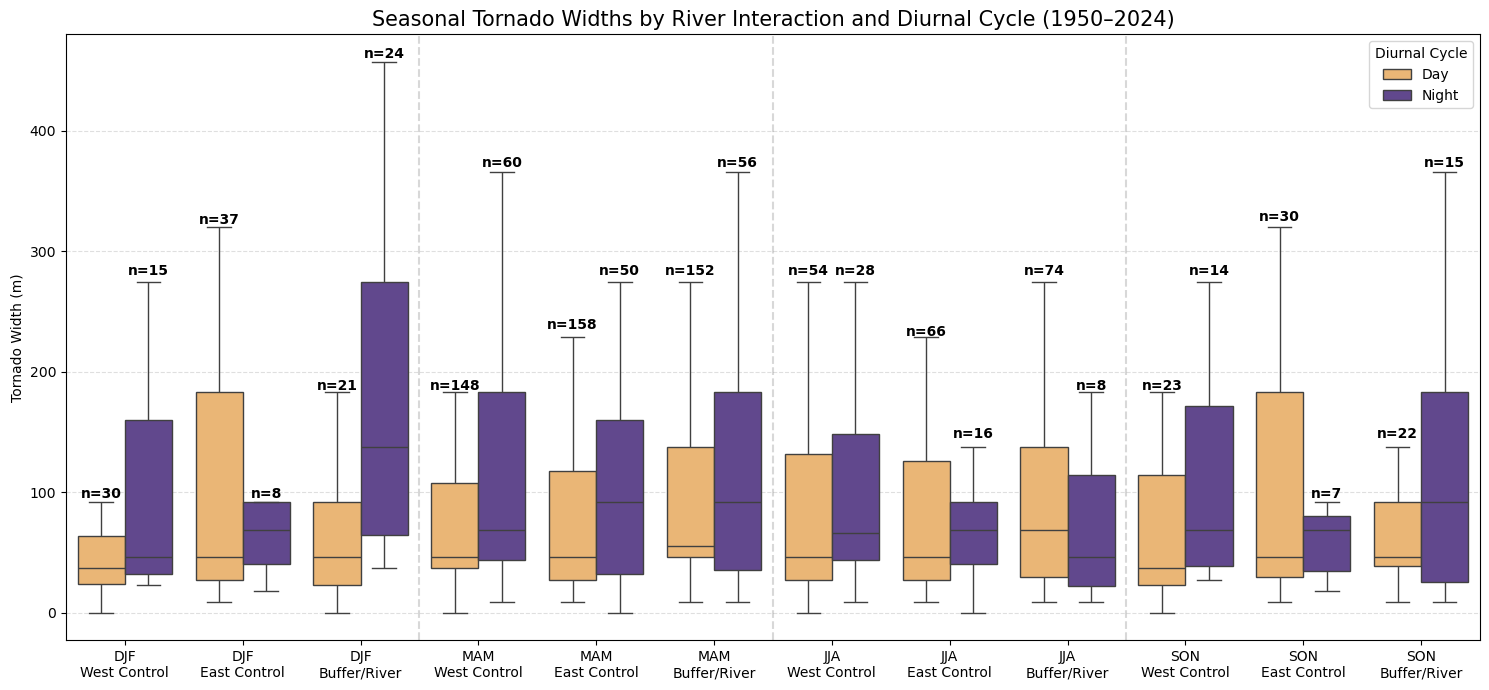

In [134]:
# ================================================================
# Boxplot
# ================================================================

plt.figure(figsize=(15,7))

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

ax = sns.boxplot(
    data=season_compare_df,
    x="season_group",
    y="wid_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

# ================================================================
# Formatting
# ================================================================

ax.set_title(
    "Seasonal Tornado Widths by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# ================================================================
# Add counts
# ================================================================

positions = {

# DJF
("DJF","West Control","Day"):(0-0.2,95),
("DJF","West Control","Night"):(0+0.2,280),
("DJF","East Control","Day"):(1-0.2,323),
("DJF","East Control","Night"):(1+0.2,95),
("DJF","Buffer/River","Day"):(2-0.2,185),
("DJF","Buffer/River","Night"):(2+0.2,460),

# MAM
("MAM","West Control","Day"):(3-0.2,185),
("MAM","West Control","Night"):(3+0.2,370),
("MAM","East Control","Day"):(4-0.2,235),
("MAM","East Control","Night"):(4+0.2,280),
("MAM","Buffer/River","Day"):(5-0.2,280),
("MAM","Buffer/River","Night"):(5+0.2,370),

# JJA
("JJA","West Control","Day"):(6-0.2,280),
("JJA","West Control","Night"):(6+0.2,280),
("JJA","East Control","Day"):(7-0.2,230),
("JJA","East Control","Night"):(7+0.2,145),
("JJA","Buffer/River","Day"):(8-0.2,280),
("JJA","Buffer/River","Night"):(8+0.2,185),

# SON
("SON","West Control","Day"):(9-0.2,185),
("SON","West Control","Night"):(9+0.2,280),
("SON","East Control","Day"):(10-0.2,325),
("SON","East Control","Night"):(10+0.2,95),
("SON","Buffer/River","Day"):(11-0.2,145),
("SON","Buffer/River","Night"):(11+0.2,370)

}

for (season,group,period),(x,y) in positions.items():

    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ================================================================
# Legend + separators
# ================================================================

ax.legend(title="Diurnal Cycle")

for x in [2.5,5.5,8.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [135]:
# ================================================================
# Create Combined Season + Group + Diurnal Label
# ================================================================

season_compare_df["season_group_dn"] = (
    season_compare_df["season"].astype(str) + " " +
    season_compare_df["group"] + " " +
    season_compare_df["day_night_bin"]
)

groups = season_compare_df.groupby(
    "season_group_dn", sort=False, observed=False
)["width_m"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['DJF Buffer/River Night', 'DJF Buffer/River Day', 'DJF West Control Night', 'DJF West Control Day', 'DJF East Control Day', 'DJF East Control Night', 'MAM Buffer/River Day', 'MAM Buffer/River Night', 'MAM West Control Night', 'MAM West Control Day', 'MAM East Control Day', 'MAM East Control Night', 'JJA Buffer/River Night', 'JJA Buffer/River Day', 'JJA West Control Night', 'JJA West Control Day', 'JJA East Control Day', 'JJA East Control Night', 'SON Buffer/River Day', 'SON Buffer/River Night', 'SON West Control Night', 'SON West Control Day', 'SON East Control Day', 'SON East Control Night']


In [136]:
# ================================================================
# Create Combined Season + Group + Diurnal Label
# ================================================================

season_compare_df["season_group_dn"] = (
    season_compare_df["season"].astype(str) + " " +
    season_compare_df["group"] + " " +
    season_compare_df["day_night_bin"]
)

# ================================================================
# Remove NaNs before grouping
# ================================================================

clean_df = season_compare_df.dropna(
    subset=["wid_m"]
).copy()

# ================================================================
# Build groups
# ================================================================

groups = clean_df.groupby(
    "season_group_dn",
    sort=False,
    observed=False
)["wid_m"].apply(list)

# ================================================================
# Check group sizes
# ================================================================

print("Groups included in analysis:\n")

for g in groups.index:
    print(g, "n =", len(groups[g]))

Groups included in analysis:

DJF Buffer/River Night n = 24
DJF Buffer/River Day n = 21
DJF West Control Night n = 15
DJF West Control Day n = 30
DJF East Control Day n = 37
DJF East Control Night n = 8
MAM Buffer/River Day n = 152
MAM Buffer/River Night n = 56
MAM West Control Night n = 60
MAM West Control Day n = 148
MAM East Control Day n = 158
MAM East Control Night n = 50
JJA Buffer/River Night n = 8
JJA Buffer/River Day n = 74
JJA West Control Night n = 28
JJA West Control Day n = 54
JJA East Control Day n = 66
JJA East Control Night n = 16
SON Buffer/River Day n = 22
SON Buffer/River Night n = 15
SON West Control Night n = 14
SON West Control Day n = 23
SON East Control Day n = 30
SON East Control Night n = 7


In [137]:
from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Widths
------------------------------------------------------
H = 30.736
p-value = 0.129424
Interpretation: No statistically significant differences detected.


In [138]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p_val = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Buffer/River Night,DJF Buffer/River Day,8.168731,0.004262,Yes
1,DJF Buffer/River Night,DJF West Control Night,3.739330,0.053146,No
2,DJF Buffer/River Night,DJF West Control Day,12.910725,0.000327,Yes
3,DJF Buffer/River Night,DJF East Control Day,7.372490,0.006623,Yes
4,DJF Buffer/River Night,DJF East Control Night,3.560629,0.059165,No
...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.167656,0.682204,No
272,SON West Control Night,SON East Control Night,1.031798,0.309737,No
273,SON West Control Day,SON East Control Day,1.691110,0.193455,No
274,SON West Control Day,SON East Control Night,0.218792,0.639962,No


In [139]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Buffer/River Night,DJF Buffer/River Day,8.168731,0.004262,Yes,1.176277,No
1,DJF Buffer/River Night,DJF West Control Night,3.739330,0.053146,No,14.668226,No
2,DJF Buffer/River Night,DJF West Control Day,12.910725,0.000327,Yes,0.090171,No
3,DJF Buffer/River Night,DJF East Control Day,7.372490,0.006623,Yes,1.827925,No
4,DJF Buffer/River Night,DJF East Control Night,3.560629,0.059165,No,16.329630,No
...,...,...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.167656,0.682204,No,188.288252,No
272,SON West Control Night,SON East Control Night,1.031798,0.309737,No,85.487312,No
273,SON West Control Day,SON East Control Day,1.691110,0.193455,No,53.393509,No
274,SON West Control Day,SON East Control Night,0.218792,0.639962,No,176.629582,No


In [140]:
# ================================================================
# Extract Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()

print("All significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

All significant comparisons:


,Group1,Group2,H,p-value
0,DJF Buffer/River Night,DJF Buffer/River Day,8.168731,0.004262
2,DJF Buffer/River Night,DJF West Control Day,12.910725,0.000327
3,DJF Buffer/River Night,DJF East Control Day,7.372490,0.006623
5,DJF Buffer/River Night,MAM Buffer/River Day,7.888305,0.004976
6,DJF Buffer/River Night,MAM Buffer/River Night,4.213409,0.040106
7,DJF Buffer/River Night,MAM West Control Night,4.876396,0.027226
8,DJF Buffer/River Night,MAM West Control Day,10.702323,0.001070
9,DJF Buffer/River Night,MAM East Control Day,10.661871,0.001094
12,DJF Buffer/River Night,JJA Buffer/River Day,5.725763,0.016718
13,DJF Buffer/River Night,JJA West Control Night,5.112760,0.023751


In [141]:
# ================================================================
# Extract Bonferroni-Significant Comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


### Seasonal and Diurnal Comparison of Tornado Widths

A Kruskal–Wallis test was conducted to evaluate whether tornado widths differ across combined seasonal, river-interaction, and diurnal populations. A total of 24 independent groups were included, representing West Control, East Control, and Buffer/River tornadoes for each meteorological season (DJF, MAM, JJA, SON), further separated into diurnal and nocturnal events.

The Kruskal–Wallis test did **not** indicate a statistically significant difference among groups:

- **H = 30.736**  
- **p = 0.129**

This result suggests that the overall distributions of tornado widths are not significantly different when considering all seasonal, river-interaction, and diurnal populations simultaneously.

### Pairwise Comparisons

Although the overall Kruskal–Wallis test was not statistically significant, exploratory pairwise Kruskal–Wallis comparisons were still examined to identify potential localized differences among groups. A total of **276 pairwise comparisons** were conducted, and a **Bonferroni correction** was applied to control the family-wise error rate.

Several uncorrected pairwise comparisons were statistically significant, particularly those involving:

- **DJF Buffer/River Night tornadoes**
- Comparisons between winter nocturnal river-interacting tornadoes and warmer-season daytime control populations
- Comparisons involving daytime versus nighttime tornadoes within the DJF Buffer/River population

Examples of uncorrected significant comparisons include:

- **DJF Buffer/River Day vs DJF Buffer/River Night** (H = 8.17, p = 0.004)
- **DJF Buffer/River Night vs MAM West Control Day** (H = 10.70, p = 0.001)
- **DJF Buffer/River Night vs JJA West Control Day** (H = 11.38, p < 0.001)
- **DJF Buffer/River Night vs SON West Control Day** (H = 9.09, p = 0.003)

However, after applying the Bonferroni correction for multiple testing, **no pairwise comparisons remained statistically significant**.

### Interpretation

These results indicate that, unlike tornado path length, tornado width does not exhibit a robust statistically significant signal across combined seasonal, river-interaction, and diurnal populations once multiple-testing corrections are considered.

Although several uncorrected comparisons suggest that **winter nocturnal Buffer/River tornadoes may exhibit somewhat larger widths relative to certain daytime control populations**, these differences are not sufficiently strong to remain significant after applying the conservative Bonferroni correction.

Overall, the results suggest that any potential influence of the Mississippi River corridor on tornado width is likely weaker and more subtle than the corresponding signal observed for tornado path length. Width variability appears to be strongly influenced by substantial within-group spread and limited sample sizes in some seasonal-diurnal categories, reducing the statistical robustness of apparent differences.

In [142]:
# ------------------------------------------------
# Assign seasons (reuse if already exists)
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Create crossed-river-only dataset
# ------------------------------------------------

crossed_only = crossing_tornadoes.copy()
crossed_only["season"] = crossed_only["date"].dt.month.apply(get_season)

# Convert path length
crossed_only["len_km"] = crossed_only["len"] * 1.60934
west_control["len_km"] = west_control["len"] * 1.60934
east_control["len_km"] = east_control["len"] * 1.60934

# ------------------------------------------------
# Random seed
# ------------------------------------------------

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

for season in seasons:

    cross_season = crossed_only[crossed_only["season"] == season]

    n = len(cross_season)

    if n == 0:
        continue

    # Match sample size
    west_sample = west_control.sample(n=n, random_state=42)
    east_sample = east_control.sample(n=n, random_state=42)

    cross_season = cross_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    cross_season["group"] = "Crossed River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    cross_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(cross_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

season_compare_cross_df = pd.concat(seasonal_df_list)

print("\nSeasonal sample sizes used:")
print(season_compare_cross_df.groupby(["season","group"]).size())
print("\nTotal tornadoes used in seasonal comparison:", len(season_compare_cross_df))


Seasonal sample sizes used:
season  group        
DJF     Crossed River    16
        East Control     16
        West Control     16
JJA     Crossed River    14
        East Control     14
        West Control     14
MAM     Crossed River    50
        East Control     50
        West Control     50
SON     Crossed River     9
        East Control      9
        West Control      9
dtype: int64

Total tornadoes used in seasonal comparison: 267


In [143]:
season_order = ["DJF","MAM","JJA","SON"]

season_compare_cross_df["season"] = pd.Categorical(
    season_compare_cross_df["season"],
    categories=season_order,
    ordered=True
)

season_compare_cross_df["season_group"] = (
    season_compare_cross_df["season"].astype(str) + "\n" + season_compare_cross_df["group"]
)

order = [
    "DJF\nWest Control",
    "DJF\nEast Control",
    "DJF\nCrossed River",

    "MAM\nWest Control",
    "MAM\nEast Control",
    "MAM\nCrossed River",

    "JJA\nWest Control",
    "JJA\nEast Control",
    "JJA\nCrossed River",

    "SON\nWest Control",
    "SON\nEast Control",
    "SON\nCrossed River",
]


Counts used in seasonal diurnal boxplot:

season  group          day_night_bin
DJF     Crossed River  Day               7
                       Night             9
        East Control   Day              14
                       Night             2
        West Control   Day              10
                       Night             6
MAM     Crossed River  Day              33
                       Night            17
        East Control   Day              42
                       Night             8
        West Control   Day              33
                       Night            17
JJA     Crossed River  Day              13
                       Night             1
        East Control   Day              12
                       Night             2
        West Control   Day               9
                       Night             5
SON     Crossed River  Day               6
                       Night             3
        East Control   Day               8
                 

/tmp/ipykernel_1435/4265273981.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



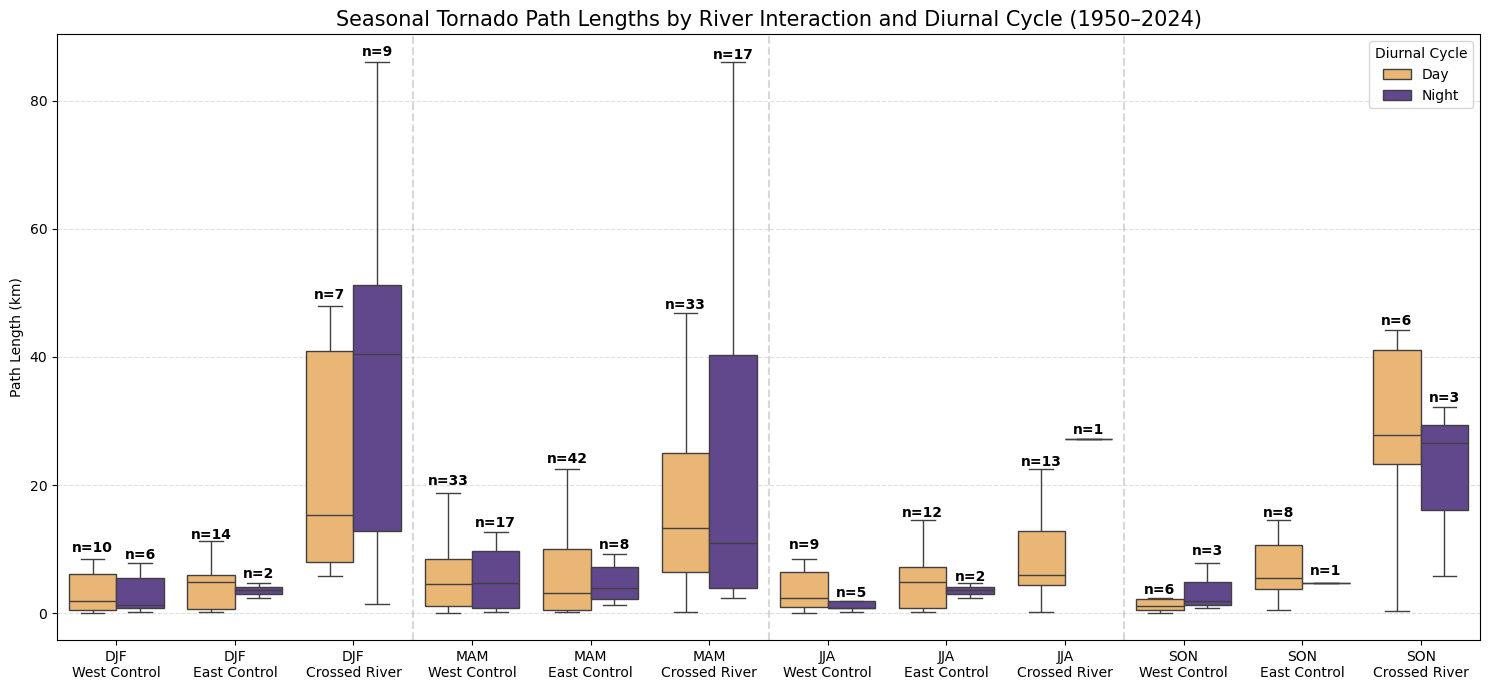

In [144]:
print("\nCounts used in seasonal diurnal boxplot:\n")

counts = season_compare_cross_df.groupby(["season","group","day_night_bin"]).size()
print(counts)

plt.figure(figsize=(15,7))

palette = {"Day":"#FDB863","Night":"#5E3C99"}

ax = sns.boxplot(
    data=season_compare_cross_df,
    x="season_group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Path Lengths by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ------------------------------------------------
# Add counts (same structure as before)
# ------------------------------------------------

positions = {

# DJF
("DJF","West Control","Day"):(0-0.2,9.5),
("DJF","West Control","Night"):(0+0.2,8.5),
("DJF","East Control","Day"):(1-0.2,11.5),
("DJF","East Control","Night"):(1+0.2,5.5),
("DJF","Crossed River","Day"):(2-0.2,49),
("DJF","Crossed River","Night"):(2+0.2,87),

# MAM
("MAM","West Control","Day"):(3-0.2,20),
("MAM","West Control","Night"):(3+0.2,13.5),
("MAM","East Control","Day"):(4-0.2,23.5),
("MAM","East Control","Night"):(4+0.2,10),
("MAM","Crossed River","Day"):(5-0.2,47.5),
("MAM","Crossed River","Night"):(5+0.2,86.5),

# JJA
("JJA","West Control","Day"):(6-0.2,10),
("JJA","West Control","Night"):(6+0.2,2.5),
("JJA","East Control","Day"):(7-0.2,15),
("JJA","East Control","Night"):(7+0.2,5),
("JJA","Crossed River","Day"):(8-0.2,23),
("JJA","Crossed River","Night"):(8+0.2,28),

# SON
("SON","West Control","Day"):(9-0.2,3),
("SON","West Control","Night"):(9+0.2,9),
("SON","East Control","Day"):(10-0.2,15),
("SON","East Control","Night"):(10+0.2,6),
("SON","Crossed River","Day"):(11-0.2,45),
("SON","Crossed River","Night"):(11+0.2,33)

}

for (season,group,period),(x,y) in positions.items():
    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

for x in [2.5,5.5,8.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [145]:
season_compare_cross_df["season_group_dn"] = (
    season_compare_cross_df["season"].astype(str) + " " +
    season_compare_cross_df["group"] + " " +
    season_compare_cross_df["day_night_bin"]
)

groups = season_compare_cross_df.groupby(
    "season_group_dn", sort=False, observed=False
)["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['DJF Crossed River Day', 'DJF Crossed River Night', 'DJF West Control Night', 'DJF West Control Day', 'DJF East Control Day', 'DJF East Control Night', 'MAM Crossed River Night', 'MAM Crossed River Day', 'MAM West Control Night', 'MAM West Control Day', 'MAM East Control Day', 'MAM East Control Night', 'JJA Crossed River Night', 'JJA Crossed River Day', 'JJA West Control Night', 'JJA West Control Day', 'JJA East Control Day', 'JJA East Control Night', 'SON Crossed River Day', 'SON Crossed River Night', 'SON West Control Night', 'SON West Control Day', 'SON East Control Day', 'SON East Control Night']


In [146]:
from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Path Lengths
------------------------------------------------------
H = 72.747
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [147]:
import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Crossed River Day,DJF Crossed River Night,0.338936,0.560444,No
1,DJF Crossed River Day,DJF West Control Night,6.630460,0.010025,Yes
2,DJF Crossed River Day,DJF West Control Day,8.571429,0.003415,Yes
3,DJF Crossed River Day,DJF East Control Day,8.493253,0.003565,Yes
4,DJF Crossed River Day,DJF East Control Night,4.200000,0.040424,Yes
...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.515099,0.472940,No
272,SON West Control Night,SON East Control Night,0.200000,0.654721,No
273,SON West Control Day,SON East Control Day,3.273862,0.070392,No
274,SON West Control Day,SON East Control Night,1.000000,0.317311,No


In [148]:
n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Crossed River Day,DJF Crossed River Night,0.338936,0.560444,No,154.682620,No
1,DJF Crossed River Day,DJF West Control Night,6.630460,0.010025,Yes,2.766882,No
2,DJF Crossed River Day,DJF West Control Day,8.571429,0.003415,Yes,0.942482,No
3,DJF Crossed River Day,DJF East Control Day,8.493253,0.003565,Yes,0.983846,No
4,DJF Crossed River Day,DJF East Control Night,4.200000,0.040424,Yes,11.157018,No
...,...,...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.515099,0.472940,No,130.531347,No
272,SON West Control Night,SON East Control Night,0.200000,0.654721,No,180.702954,No
273,SON West Control Day,SON East Control Day,3.273862,0.070392,No,19.428118,No
274,SON West Control Day,SON East Control Night,1.000000,0.317311,No,87.577700,No


In [149]:
significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()
pd.set_option('display.max_rows', 100)

display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]].head(71))

,Group1,Group2,H,p-value
1,DJF Crossed River Day,DJF West Control Night,6.630460,0.010025
2,DJF Crossed River Day,DJF West Control Day,8.571429,0.003415
3,DJF Crossed River Day,DJF East Control Day,8.493253,0.003565
4,DJF Crossed River Day,DJF East Control Night,4.200000,0.040424
7,DJF Crossed River Day,MAM West Control Night,5.087786,0.024095
8,DJF Crossed River Day,MAM West Control Day,7.225074,0.007189
9,DJF Crossed River Day,MAM East Control Day,7.384301,0.006580
10,DJF Crossed River Day,MAM East Control Night,5.638417,0.017571
13,DJF Crossed River Day,JJA West Control Night,6.358496,0.011682
14,DJF Crossed River Day,JJA West Control Day,7.868347,0.005031


In [150]:
significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


### Seasonal and Diurnal Comparison of Tornado Path Lengths (Crossed River Tornadoes)

A Kruskal–Wallis test was conducted to evaluate whether tornado path lengths differ across combined seasonal, river-interaction, and diurnal populations. A total of 24 independent groups were included, representing West Control, East Control, and Crossed River tornadoes for each meteorological season (DJF, MAM, JJA, SON), further separated into diurnal and nocturnal events.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 72.747**  
- **p < 0.001**

This result suggests that at least one group exhibits significantly different tornado path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted across all groups. Due to the large number of comparisons (**276 total**), a **Bonferroni correction** was applied to control for family-wise error.

At the nominal significance level (α = 0.05), **71 pairwise comparisons** were found to be significant. These differences were strongly concentrated in comparisons involving **Crossed River tornadoes**, particularly during winter (DJF) and spring (MAM).

Notable patterns include:

- **DJF Crossed River tornadoes (both Day and Night)** exhibited significantly longer path lengths than:
  - DJF West and East Control populations  
  - MAM, JJA, and SON control populations  
- **DJF Crossed River Night tornadoes** showed especially strong differences relative to:
  - MAM and JJA daytime controls (e.g., H ≈ 11–12, p < 0.001)  
- **MAM Crossed River tornadoes (Day and Night)** also exhibited longer path lengths compared to:
  - MAM controls (both West and East)  
  - JJA and SON control populations  
- Comparisons involving **JJA and SON Crossed River tornadoes** were fewer and generally weaker, indicating reduced seasonal contrast outside of the cool and transitional seasons.

However, after applying the Bonferroni correction, **no pairwise comparisons remained statistically significant**.

### Interpretation

These results indicate that **tornadoes that directly cross the Mississippi River frequently exhibit longer path lengths than surrounding control populations**, particularly during **winter (DJF)** and **spring (MAM)**, and under both diurnal and nocturnal conditions.

The strongest signals are associated with:
- **DJF Crossed River tornadoes**, especially at night  
- **MAM Crossed River tornadoes**, which also show consistent differences relative to controls  

Despite the large number of nominally significant comparisons, the absence of Bonferroni-significant results indicates that these differences are **not robust under strict multiple-testing correction**. This suggests that the observed signal, while consistent and physically meaningful, is **moderate in magnitude and sensitive to sample variability**.

Importantly, these findings reinforce earlier results showing that:
- Tornadoes that exclusively **cross the river** exhibit longer path lengths than when grouped entirely within the buffer region  
- The **cool season (DJF)** and **transitional season (MAM)** are the primary periods where river-related differences emerge  
- The **diurnal cycle enhances variability**, with nocturnal events often contributing to longer path lengths  

Overall, the results provide **consistent but not statistically definitive evidence** that tornadoes crossing the Mississippi River may exhibit enhanced persistence, particularly during winter and spring. This highlights the importance of environmental context and supports the hypothesis that land–water contrasts can modulate tornado behavior under favorable atmospheric conditions.

In [151]:
# ================================================================
# Seasonal and Diurnal Comparison of Tornado Widths
# Crossed River vs Random Controls
# ================================================================

# ------------------------------------------------
# Assign seasons
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

weak_tornadoes["season"] = weak_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Create crossed-river-only dataset
# ------------------------------------------------

crossed_only = crossing_tornadoes.copy()
crossed_only["season"] = crossed_only["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Convert tornado width from yards → meters
# ------------------------------------------------

crossed_only["wid_m"] = crossed_only["wid"] * 0.9144
west_control["wid_m"] = west_control["wid"] * 0.9144
east_control["wid_m"] = east_control["wid"] * 0.9144

# ------------------------------------------------
# Random seed
# ------------------------------------------------

np.random.seed(42)

seasons = ["DJF","MAM","JJA","SON"]

seasonal_df_list = []

for season in seasons:

    cross_season = crossed_only[crossed_only["season"] == season]

    n = len(cross_season)

    if n == 0:
        continue

    # Match sample size
    west_sample = west_control.sample(n=n, random_state=42)
    east_sample = east_control.sample(n=n, random_state=42)

    cross_season = cross_season.copy()
    west_sample = west_sample.copy()
    east_sample = east_sample.copy()

    cross_season["group"] = "Crossed River"
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    cross_season["season"] = season
    west_sample["season"] = season
    east_sample["season"] = season

    seasonal_df_list.append(cross_season)
    seasonal_df_list.append(west_sample)
    seasonal_df_list.append(east_sample)

season_compare_cross_df = pd.concat(seasonal_df_list)

print("\nSeasonal sample sizes used:")
print(season_compare_cross_df.groupby(["season","group"]).size())

print("\nTotal tornadoes used in seasonal comparison:")
print(len(season_compare_cross_df))

# ================================================================
# Ordering
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_cross_df["season"] = pd.Categorical(
    season_compare_cross_df["season"],
    categories=season_order,
    ordered=True
)

season_compare_cross_df["season_group"] = (
    season_compare_cross_df["season"].astype(str)
    + "\n"
    + season_compare_cross_df["group"]
)

order = [

    "DJF\nWest Control",
    "DJF\nEast Control",
    "DJF\nCrossed River",

    "MAM\nWest Control",
    "MAM\nEast Control",
    "MAM\nCrossed River",

    "JJA\nWest Control",
    "JJA\nEast Control",
    "JJA\nCrossed River",

    "SON\nWest Control",
    "SON\nEast Control",
    "SON\nCrossed River",
]

# ================================================================
# Counts
# ================================================================

print("\nCounts used in seasonal diurnal boxplot:\n")

counts = season_compare_cross_df.groupby(
    ["season","group","day_night_bin"],
    observed=False
).size()

print(counts)


Seasonal sample sizes used:
season  group        
DJF     Crossed River    16
        East Control     16
        West Control     16
JJA     Crossed River    14
        East Control     14
        West Control     14
MAM     Crossed River    50
        East Control     50
        West Control     50
SON     Crossed River     9
        East Control      9
        West Control      9
dtype: int64

Total tornadoes used in seasonal comparison:
267

Counts used in seasonal diurnal boxplot:

season  group          day_night_bin
DJF     Crossed River  Day               7
                       Night             9
        East Control   Day              14
                       Night             2
        West Control   Day              10
                       Night             6
MAM     Crossed River  Day              33
                       Night            17
        East Control   Day              42
                       Night             8
        West Control   Day              

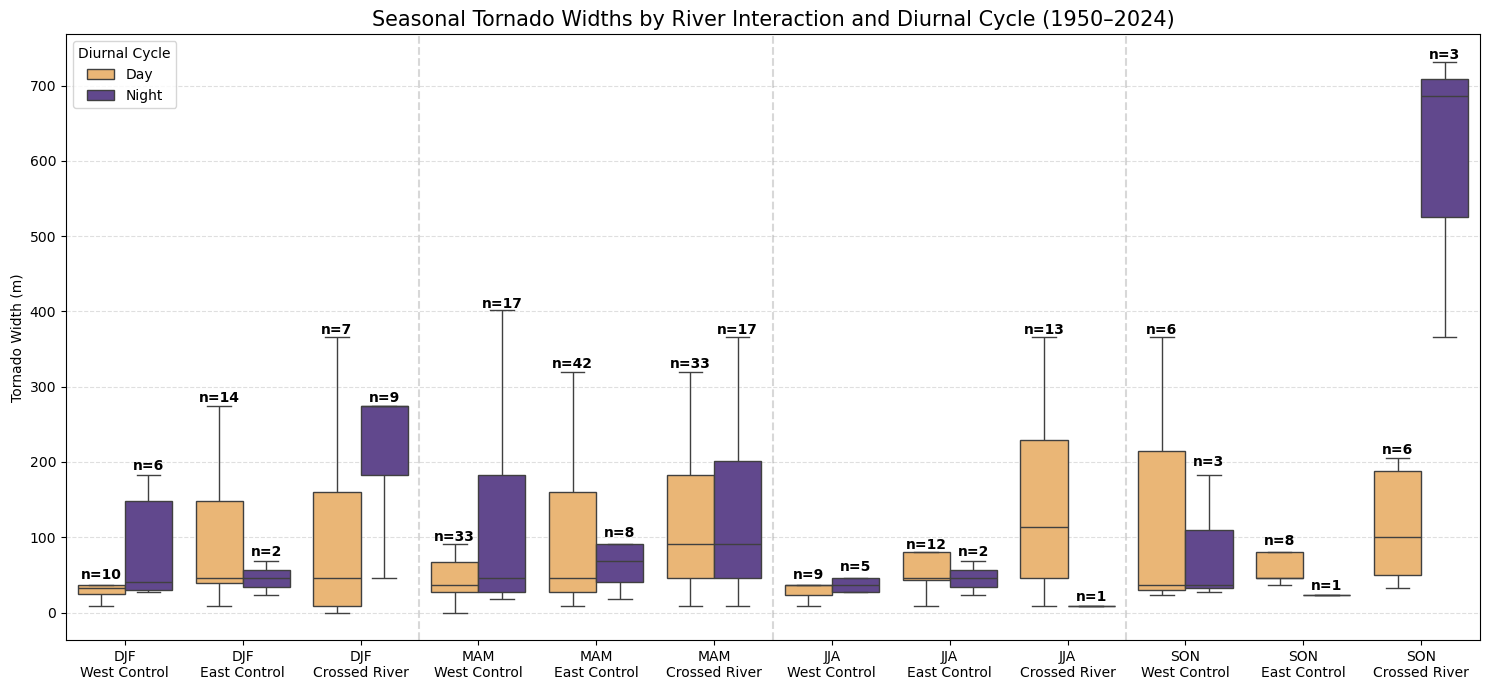

In [152]:
# ================================================================
# Boxplot
# ================================================================

plt.figure(figsize=(15,7))

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

ax = sns.boxplot(
    data=season_compare_cross_df,
    x="season_group",
    y="wid_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Widths by River Interaction and Diurnal Cycle (1950–2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ================================================================
# Add counts
# ================================================================

positions = {

# DJF
("DJF","West Control","Day"):(0-0.2,45),
("DJF","West Control","Night"):(0+0.2,190),
("DJF","East Control","Day"):(1-0.2,280),
("DJF","East Control","Night"):(1+0.2,75),
("DJF","Crossed River","Day"):(2-0.2,370),
("DJF","Crossed River","Night"):(2+0.2,280),

# MAM
("MAM","West Control","Day"):(3-0.2,95),
("MAM","West Control","Night"):(3+0.2,405),
("MAM","East Control","Day"):(4-0.2,325),
("MAM","East Control","Night"):(4+0.2,100),
("MAM","Crossed River","Day"):(5-0.2,325),
("MAM","Crossed River","Night"):(5+0.2,370),

# JJA
("JJA","West Control","Day"):(6-0.2,45),
("JJA","West Control","Night"):(6+0.2,55),
("JJA","East Control","Day"):(7-0.2,85),
("JJA","East Control","Night"):(7+0.2,75),
("JJA","Crossed River","Day"):(8-0.2,370),
("JJA","Crossed River","Night"):(8+0.2,15),

# SON
("SON","West Control","Day"):(9-0.2,370),
("SON","West Control","Night"):(9+0.2,195),
("SON","East Control","Day"):(10-0.2,90),
("SON","East Control","Night"):(10+0.2,30),
("SON","Crossed River","Day"):(11-0.2,210),
("SON","Crossed River","Night"):(11+0.2,735)
}

for (season,group,period),(x,y) in positions.items():

    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

# Vertical separators
for x in [2.5,5.5,8.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [153]:
# ================================================================
# Create combined labels for statistics
# ================================================================

season_compare_cross_df["season_group_dn"] = (
    season_compare_cross_df["season"].astype(str)
    + " "
    + season_compare_cross_df["group"]
    + " "
    + season_compare_cross_df["day_night_bin"]
)

groups = season_compare_cross_df.groupby(
    "season_group_dn",
    sort=False,
    observed=False
)["wid_m"].apply(list)

print("\nGroups included in analysis:")
print(groups.index.tolist())


Groups included in analysis:
['DJF Crossed River Day', 'DJF Crossed River Night', 'DJF West Control Night', 'DJF West Control Day', 'DJF East Control Day', 'DJF East Control Night', 'MAM Crossed River Night', 'MAM Crossed River Day', 'MAM West Control Night', 'MAM West Control Day', 'MAM East Control Day', 'MAM East Control Night', 'JJA Crossed River Night', 'JJA Crossed River Day', 'JJA West Control Night', 'JJA West Control Day', 'JJA East Control Day', 'JJA East Control Night', 'SON Crossed River Day', 'SON Crossed River Night', 'SON West Control Night', 'SON West Control Day', 'SON East Control Day', 'SON East Control Night']


In [154]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal

# Remove empty groups
groups_clean = [g for g in groups if len(g) > 0]

H, p = kruskal(*groups_clean)

print("\nKruskal-Wallis Test on Seasonal Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Widths
------------------------------------------------------
H = 47.547
p-value = 0.001911
Interpretation: At least one group differs significantly.


In [155]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    try:

        stat, p = kruskal(groups[a], groups[b])

        results.append({
            "Group1": a,
            "Group2": b,
            "H": stat,
            "p-value": p,
            "Significant?": "Yes" if p < 0.05 else "No"
        })

    except Exception:
        continue

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,DJF Crossed River Day,DJF Crossed River Night,4.576005,0.032423,Yes
1,DJF Crossed River Day,DJF West Control Night,0.330159,0.565566,No
2,DJF Crossed River Day,DJF West Control Day,0.002413,0.960818,No
3,DJF Crossed River Day,DJF East Control Day,0.145773,0.702608,No
4,DJF Crossed River Day,DJF East Control Night,0.000000,1.000000,No
...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.951923,0.329230,No
272,SON West Control Night,SON East Control Night,1.800000,0.179712,No
273,SON West Control Day,SON East Control Day,0.864147,0.352581,No
274,SON West Control Day,SON East Control Night,1.620370,0.203040,No


In [156]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,DJF Crossed River Day,DJF Crossed River Night,4.576005,0.032423,Yes,8.948673,No
1,DJF Crossed River Day,DJF West Control Night,0.330159,0.565566,No,156.096116,No
2,DJF Crossed River Day,DJF West Control Day,0.002413,0.960818,No,265.185736,No
3,DJF Crossed River Day,DJF East Control Day,0.145773,0.702608,No,193.919919,No
4,DJF Crossed River Day,DJF East Control Night,0.000000,1.000000,No,276.000000,No
...,...,...,...,...,...,...,...
271,SON West Control Night,SON East Control Day,0.951923,0.329230,No,90.867557,No
272,SON West Control Night,SON East Control Night,1.800000,0.179712,No,49.600649,No
273,SON West Control Day,SON East Control Day,0.864147,0.352581,No,97.312273,No
274,SON West Control Day,SON East Control Night,1.620370,0.203040,No,56.039082,No


In [157]:
# ================================================================
# Display significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Significant?"] == "Yes"
].copy()

pd.set_option('display.max_rows', 100)

print("\nAll significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]].head(71))


All significant comparisons:


,Group1,Group2,H,p-value
0,DJF Crossed River Day,DJF Crossed River Night,4.576005,0.032423
18,DJF Crossed River Day,SON Crossed River Night,5.258545,0.021839
23,DJF Crossed River Night,DJF West Control Night,4.109283,0.042648
24,DJF Crossed River Night,DJF West Control Day,7.429443,0.006417
25,DJF Crossed River Night,DJF East Control Day,9.131306,0.002513
27,DJF Crossed River Night,MAM Crossed River Night,4.040301,0.044426
28,DJF Crossed River Night,MAM Crossed River Day,6.092615,0.013575
29,DJF Crossed River Night,MAM West Control Night,7.254048,0.007074
30,DJF Crossed River Night,MAM West Control Day,11.377011,0.000744
31,DJF Crossed River Night,MAM East Control Day,10.830947,0.000998


In [158]:
# ================================================================
# Display Bonferroni-significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Adj Significant?"] == "Yes"
].copy()

print("\nBonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


### Seasonal and Diurnal Comparison of Tornado Widths (Crossed River Tornadoes)

A Kruskal–Wallis test was conducted to evaluate whether tornado widths differ across combined seasonal, river-interaction, and diurnal populations. A total of 24 independent groups were included, representing West Control, East Control, and Crossed River tornadoes for each meteorological season (DJF, MAM, JJA, SON), further separated into diurnal and nocturnal events.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 47.547**  
- **p = 0.0019**

This result suggests that at least one group exhibits significantly different tornado width characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted across all groups. Due to the large number of comparisons (**276 total**), a **Bonferroni correction** was applied to control for family-wise error.

At the nominal significance level (α = 0.05), numerous pairwise comparisons were statistically significant. These differences were strongly concentrated in comparisons involving **DJF Crossed River Night tornadoes**, with additional signals associated with **MAM Crossed River tornadoes** and **SON Crossed River Night tornadoes**.

Notable patterns include:

- **DJF Crossed River Night tornadoes** exhibited significantly larger widths than:
  - DJF West and East daytime controls  
  - MAM daytime control populations  
  - JJA daytime controls  
  - SON East daytime controls  

- **MAM Crossed River Day tornadoes** also exhibited significantly larger widths relative to:
  - MAM West and East daytime controls  
  - JJA West and East daytime controls  

- Several comparisons involving **SON Crossed River Night tornadoes** were significant relative to:
  - DJF, MAM, and JJA control populations  
  - SON daytime control populations  

- Within-season differences were also evident:
  - **DJF Crossed River Day vs DJF Crossed River Night** (H = 4.58, p = 0.032)  
  - **DJF Crossed River Night vs DJF West Control Day** (H = 7.43, p = 0.006)  
  - **MAM Crossed River Day vs MAM West Control Day** (H = 10.89, p < 0.001)  

However, after applying the Bonferroni correction, **no pairwise comparisons remained statistically significant**.

### Interpretation

These results indicate that tornadoes crossing the Mississippi River exhibit meaningful variability in tornado width across seasons and diurnal periods, with the strongest signals concentrated during **winter (DJF)** and **spring (MAM)**.

The most consistent patterns involve:

- **DJF Crossed River Night tornadoes**, which frequently exhibited larger widths than multiple control populations  
- **MAM Crossed River Day tornadoes**, which also showed broader widths relative to nearby daytime controls  
- **SON Crossed River Night tornadoes**, which displayed elevated widths relative to several control populations across seasons  

Compared to the earlier path length analyses, the tornado width signal appears somewhat weaker and less spatially coherent. While numerous nominally significant comparisons were detected, the absence of Bonferroni-significant results indicates that these differences are **not statistically robust under strict multiple-testing correction**.

Nevertheless, the repeated appearance of significant comparisons involving **Crossed River nighttime tornadoes**, particularly during DJF, suggests that the river environment may contribute to enhanced tornado structure or organization under certain cool-season conditions.

Overall, these findings provide **moderate but not definitive evidence** that tornadoes crossing the Mississippi River can exhibit enhanced width characteristics relative to surrounding control populations, especially during winter and spring and under nocturnal conditions.

In [159]:
# ------------------------------------------------
# Assign seasons (if not already done)
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

west_side = west_side.copy()
east_side = east_side.copy()
crossing_tornadoes = crossing_tornadoes.copy()

# Apply to datasets
west_side["season"] = west_side["date"].dt.month.apply(get_season)
east_side["season"] = east_side["date"].dt.month.apply(get_season)
crossing_tornadoes["season"] = crossing_tornadoes["date"].dt.month.apply(get_season)

# Convert path length
west_side["len_km"] = west_side["len"] * 1.60934
east_side["len_km"] = east_side["len"] * 1.60934
crossing_tornadoes["len_km"] = crossing_tornadoes["len"] * 1.60934

# Assign group labels
west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# Combine datasets
season_compare_side_df = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
])

print("\nCounts by season and group:")
print(season_compare_side_df.groupby(["season","group"]).size())

print("\nCounts by season, group, and day/night:")
print(season_compare_side_df.groupby(["season","group","day_night_bin"]).size())


Counts by season and group:
season  group        
DJF     Crossed River    16
        East Side        15
        West Side        14
JJA     Crossed River    14
        East Side        39
        West Side        29
MAM     Crossed River    50
        East Side        74
        West Side        84
SON     Crossed River     9
        East Side        13
        West Side        15
dtype: int64

Counts by season, group, and day/night:
season  group          day_night_bin
DJF     Crossed River  Day               7
                       Night             9
        East Side      Day               7
                       Night             8
        West Side      Day               7
                       Night             7
JJA     Crossed River  Day              13
                       Night             1
        East Side      Day              36
                       Night             3
        West Side      Day              25
                       Night             4
MAM   

In [160]:
season_order = ["DJF","MAM","JJA","SON"]

season_compare_side_df["season"] = pd.Categorical(
    season_compare_side_df["season"],
    categories=season_order,
    ordered=True
)

season_compare_side_df["season_group"] = (
    season_compare_side_df["season"].astype(str) + "\n" + season_compare_side_df["group"]
)

order = [
    "DJF\nWest Side",
    "DJF\nEast Side",
    "DJF\nCrossed River",

    "MAM\nWest Side",
    "MAM\nEast Side",
    "MAM\nCrossed River",

    "JJA\nWest Side",
    "JJA\nEast Side",
    "JJA\nCrossed River",

    "SON\nWest Side",
    "SON\nEast Side",
    "SON\nCrossed River",
]

/tmp/ipykernel_1435/3940701247.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



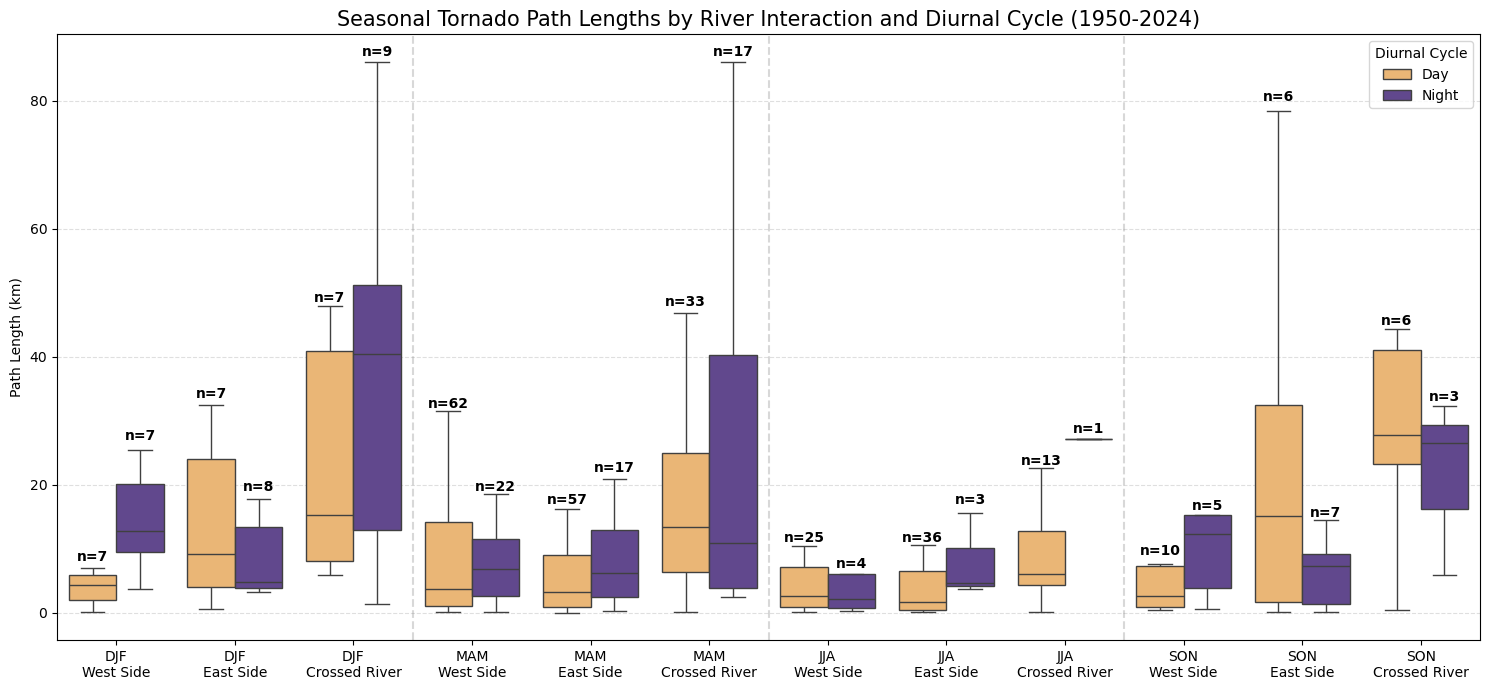

In [173]:
# ------------------------------------------------
# Compute counts (FIX)
# ------------------------------------------------
counts = season_compare_side_df.groupby(["season","group","day_night_bin"]).size()

plt.figure(figsize=(15,7))

palette = {"Day":"#FDB863","Night":"#5E3C99"}

ax = sns.boxplot(
    data=season_compare_side_df,
    x="season_group",
    y="len_km",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Path Lengths by River Interaction and Diurnal Cycle (1950-2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ------------------------------------------------
# Add counts (same structure)
# ------------------------------------------------

positions = {

# DJF
("DJF","West Side","Day"):(0-0.2,8),
("DJF","West Side","Night"):(0+0.2,27),
("DJF","East Side","Day"):(1-0.2,33.5),
("DJF","East Side","Night"):(1+0.2,19),
("DJF","Crossed River","Day"):(2-0.2,48.5),
("DJF","Crossed River","Night"):(2+0.2,87),

# MAM
("MAM","West Side","Day"):(3-0.2,32),
("MAM","West Side","Night"):(3+0.2,19),
("MAM","East Side","Day"):(4-0.2,17),
("MAM","East Side","Night"):(4+0.2,22),
("MAM","Crossed River","Day"):(5-0.2,48),
("MAM","Crossed River","Night"):(5+0.2,87),

# JJA
("JJA","West Side","Day"):(6-0.2,11),
("JJA","West Side","Night"):(6+0.2,7),
("JJA","East Side","Day"):(7-0.2,11),
("JJA","East Side","Night"):(7+0.2,17),
("JJA","Crossed River","Day"):(8-0.2,23),
("JJA","Crossed River","Night"):(8+0.2,28),

# SON
("SON","West Side","Day"):(9-0.2,9),
("SON","West Side","Night"):(9+0.2,16),
("SON","East Side","Day"):(10-0.2,80),
("SON","East Side","Night"):(10+0.2,15),
("SON","Crossed River","Day"):(11-0.2,45),
("SON","Crossed River","Night"):(11+0.2,33)

}

for (season,group,period),(x,y) in positions.items():
    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

for x in [2.5,5.5,8.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [174]:
season_compare_side_df["season_group_dn"] = (
    season_compare_side_df["season"].astype(str) + " " +
    season_compare_side_df["group"] + " " +
    season_compare_side_df["day_night_bin"]
)

groups = season_compare_side_df.groupby(
    "season_group_dn", sort=False, observed=False
)["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['MAM West Side Day', 'JJA West Side Night', 'DJF West Side Night', 'MAM West Side Night', 'DJF West Side Day', 'JJA West Side Day', 'SON West Side Day', 'SON West Side Night', 'SON East Side Night', 'MAM East Side Night', 'JJA East Side Day', 'DJF East Side Day', 'MAM East Side Day', 'SON East Side Day', 'DJF East Side Night', 'JJA East Side Night', 'DJF Crossed River Day', 'MAM Crossed River Night', 'SON Crossed River Day', 'MAM Crossed River Day', 'DJF Crossed River Night', 'JJA Crossed River Night', 'JJA Crossed River Day', 'SON Crossed River Night']


In [175]:
from scipy.stats import kruskal

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Seasonal Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Seasonal Tornado Path Lengths
------------------------------------------------------
H = 65.086
p-value = 0.000007
Interpretation: At least one group differs significantly.


In [176]:
import itertools

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,MAM West Side Day,JJA West Side Night,0.607722,0.435647,No
1,MAM West Side Day,DJF West Side Night,3.418075,0.064486,No
2,MAM West Side Day,MAM West Side Night,0.228768,0.632439,No
3,MAM West Side Day,DJF West Side Day,0.174292,0.676325,No
4,MAM West Side Day,JJA West Side Day,0.845443,0.357845,No
...,...,...,...,...,...
271,DJF Crossed River Night,JJA Crossed River Day,4.424749,0.035421,Yes
272,DJF Crossed River Night,SON Crossed River Night,1.444444,0.229421,No
273,JJA Crossed River Night,JJA Crossed River Day,1.246154,0.264288,No
274,JJA Crossed River Night,SON Crossed River Night,0.200000,0.654721,No


In [177]:
n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,MAM West Side Day,JJA West Side Night,0.607722,0.435647,No,120.238561,No
1,MAM West Side Day,DJF West Side Night,3.418075,0.064486,No,17.798183,No
2,MAM West Side Day,MAM West Side Night,0.228768,0.632439,No,174.553220,No
3,MAM West Side Day,DJF West Side Day,0.174292,0.676325,No,186.665695,No
4,MAM West Side Day,JJA West Side Day,0.845443,0.357845,No,98.765146,No
...,...,...,...,...,...,...,...
271,DJF Crossed River Night,JJA Crossed River Day,4.424749,0.035421,Yes,9.776284,No
272,DJF Crossed River Night,SON Crossed River Night,1.444444,0.229421,No,63.320330,No
273,JJA Crossed River Night,JJA Crossed River Day,1.246154,0.264288,No,72.943583,No
274,JJA Crossed River Night,SON Crossed River Night,0.200000,0.654721,No,180.702954,No


In [178]:
significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()

print("All significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

print(significant_pairs["Significant?"].count()) #41 total

All significant comparisons:


,Group1,Group2,H,p-value
9,MAM West Side Day,JJA East Side Day,4.052577,0.044104
15,MAM West Side Day,DJF Crossed River Day,5.643642,0.017519
16,MAM West Side Day,MAM Crossed River Night,7.433300,0.006403
17,MAM West Side Day,SON Crossed River Day,4.089337,0.043155
18,MAM West Side Day,MAM Crossed River Day,8.617762,0.003329
19,MAM West Side Day,DJF Crossed River Night,7.989097,0.004706
37,JJA West Side Night,DJF Crossed River Day,4.321429,0.037635
41,JJA West Side Night,DJF Crossed River Night,4.666667,0.030754
46,DJF West Side Night,DJF West Side Day,4.444898,0.035006
47,DJF West Side Night,JJA West Side Day,7.118998,0.007627


56


In [179]:
significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
191,JJA East Side Day,MAM Crossed River Night,14.399186,0.000148,0.040811
193,JJA East Side Day,MAM Crossed River Day,17.144683,0.000035,0.009560
216,MAM East Side Day,MAM Crossed River Day,14.170399,0.000167,0.046086


### Seasonal and Diurnal Comparison of Tornado Path Lengths (West Side, East Side, and Crossed River)

A Kruskal–Wallis test was conducted to evaluate whether tornado path lengths differ across combined seasonal, spatial (West Side, East Side, Crossed River), and diurnal populations. A total of 24 independent groups were included, representing each meteorological season (DJF, MAM, JJA, SON), further separated into daytime and nighttime events.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 65.086**  
- **p = 0.000007**

This result suggests that at least one group exhibits significantly different tornado path length characteristics.

---

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted across all groups (**276 total comparisons**). A **Bonferroni correction** was applied to control for family-wise error.

After correction, three comparisons remained statistically significant:

- **JJA East Side Day vs MAM Crossed River Night**  
  (H = 14.40, adj. p = 0.0408)

- **JJA East Side Day vs MAM Crossed River Day**  
  (H = 17.14, adj. p = 0.0096)

- **MAM East Side Day vs MAM Crossed River Day**  
  (H = 14.17, adj. p = 0.0461)

---

### Interpretation

These results indicate that **tornadoes crossing the river during spring (MAM)** exhibit significantly longer path lengths compared to **daytime tornadoes on the east side of the river**, particularly during both **spring (MAM)** and **summer (JJA)** daytime environments.

The strongest statistical signal consistently involves:

- **MAM Crossed River Day tornadoes**, and  
- **MAM Crossed River Night tornadoes**

when compared against **East Side daytime tornado populations**.

Importantly, **no statistically significant differences remained between West Side and East Side tornadoes after Bonferroni correction**, suggesting that simple geographic placement on either side of the river does not substantially alter tornado path length characteristics.

Instead, the dominant and most robust signal emerges specifically from **river-crossing tornadoes**, reinforcing the interpretation that **interaction with the Mississippi River corridor itself—rather than mere proximity to the river—is associated with enhanced tornado persistence**.

Overall, these findings strongly support the hypothesis that **river-crossing tornadoes, especially during the peak severe weather season (MAM), tend to exhibit substantially longer path lengths**, while non-crossing tornadoes on the west and east sides remain comparatively similar after accounting for multiple testing.

In [180]:
# ================================================================
# Seasonal Tornado Widths by River Interaction and Diurnal Cycle
# ================================================================

# ------------------------------------------------
# Assign seasons
# ------------------------------------------------

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

west_side = west_side.copy()
east_side = east_side.copy()
crossing_tornadoes = crossing_tornadoes.copy()

# Apply seasons
west_side["season"] = west_side["date"].dt.month.apply(get_season)
east_side["season"] = east_side["date"].dt.month.apply(get_season)
crossing_tornadoes["season"] = crossing_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# Convert tornado width from yards → meters
# ------------------------------------------------

west_side["wid_m"] = west_side["wid"] * 0.9144
east_side["wid_m"] = east_side["wid"] * 0.9144
crossing_tornadoes["wid_m"] = crossing_tornadoes["wid"] * 0.9144

# ------------------------------------------------
# Assign group labels
# ------------------------------------------------

west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# ------------------------------------------------
# Combine datasets
# ------------------------------------------------

season_compare_side_df = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
])

# ================================================================
# Counts
# ================================================================

print("\nCounts by season and group:")
print(
    season_compare_side_df.groupby(
        ["season","group"],
        observed=False
    ).size()
)

print("\nCounts by season, group, and day/night:")
counts = season_compare_side_df.groupby(
    ["season","group","day_night_bin"],
    observed=False
).size()

print(counts)

# ================================================================
# Ordering
# ================================================================

season_order = ["DJF","MAM","JJA","SON"]

season_compare_side_df["season"] = pd.Categorical(
    season_compare_side_df["season"],
    categories=season_order,
    ordered=True
)

season_compare_side_df["season_group"] = (
    season_compare_side_df["season"].astype(str)
    + "\n"
    + season_compare_side_df["group"]
)

order = [

    "DJF\nWest Side",
    "DJF\nEast Side",
    "DJF\nCrossed River",

    "MAM\nWest Side",
    "MAM\nEast Side",
    "MAM\nCrossed River",

    "JJA\nWest Side",
    "JJA\nEast Side",
    "JJA\nCrossed River",

    "SON\nWest Side",
    "SON\nEast Side",
    "SON\nCrossed River",
]



Counts by season and group:
season  group        
DJF     Crossed River    16
        East Side        15
        West Side        14
JJA     Crossed River    14
        East Side        39
        West Side        29
MAM     Crossed River    50
        East Side        74
        West Side        84
SON     Crossed River     9
        East Side        13
        West Side        15
dtype: int64

Counts by season, group, and day/night:
season  group          day_night_bin
DJF     Crossed River  Day               7
                       Night             9
        East Side      Day               7
                       Night             8
        West Side      Day               7
                       Night             7
JJA     Crossed River  Day              13
                       Night             1
        East Side      Day              36
                       Night             3
        West Side      Day              25
                       Night             4
MAM   

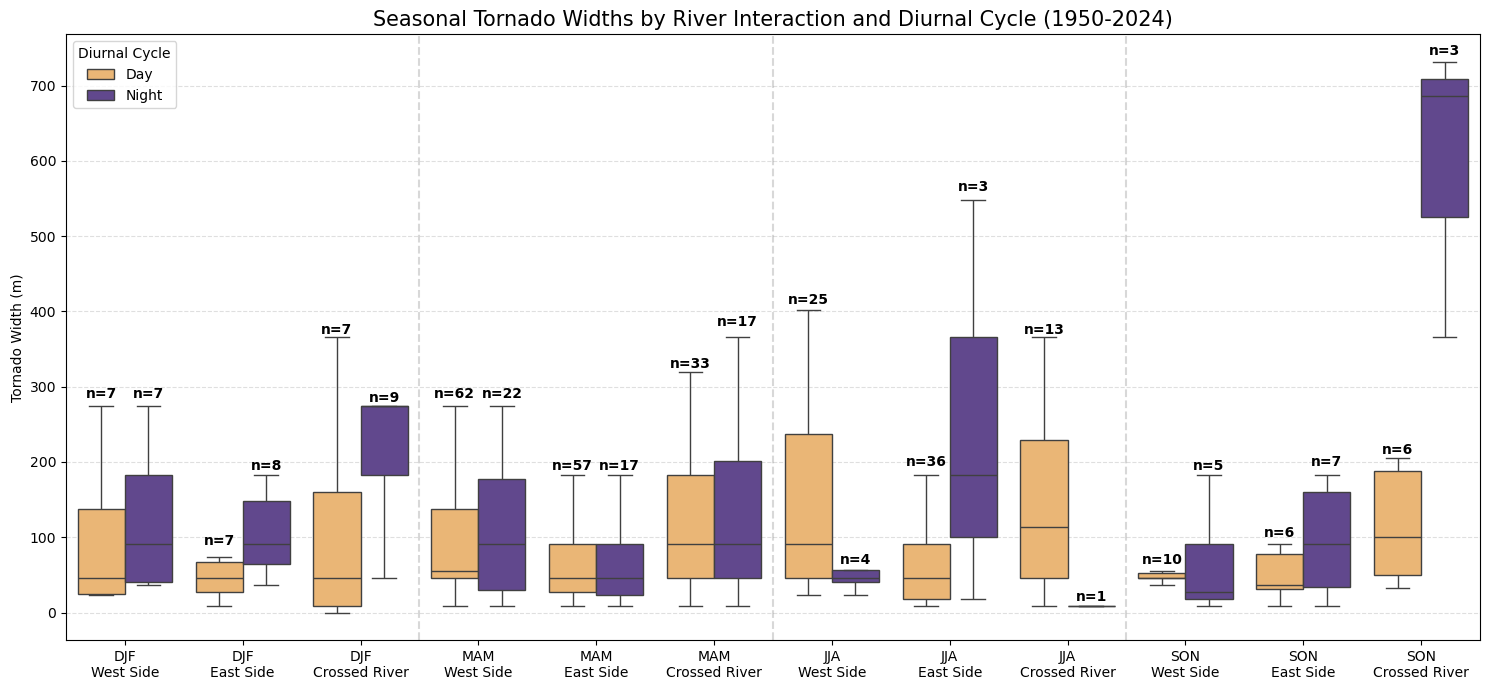

In [188]:
# ================================================================
# Boxplot
# ================================================================

plt.figure(figsize=(15,7))

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

ax = sns.boxplot(
    data=season_compare_side_df,
    x="season_group",
    y="wid_m",
    hue="day_night_bin",
    order=order,
    hue_order=["Day","Night"],
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Seasonal Tornado Widths by River Interaction and Diurnal Cycle (1950-2024)",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ================================================================
# Add counts
# ================================================================

positions = {

# DJF
("DJF","West Side","Day"):(0-0.2,285),
("DJF","West Side","Night"):(0+0.2,285),
("DJF","East Side","Day"):(1-0.2,90),
("DJF","East Side","Night"):(1+0.2,190),
("DJF","Crossed River","Day"):(2-0.2,370),
("DJF","Crossed River","Night"):(2+0.2,280),

# MAM
("MAM","West Side","Day"):(3-0.2,285),
("MAM","West Side","Night"):(3+0.2,285),
("MAM","East Side","Day"):(4-0.2,190),
("MAM","East Side","Night"):(4+0.2,190),
("MAM","Crossed River","Day"):(5-0.2,325),
("MAM","Crossed River","Night"):(5+0.2,380),

# JJA
("JJA","West Side","Day"):(6-0.2,410),
("JJA","West Side","Night"):(6+0.2,65),
("JJA","East Side","Day"):(7-0.2,195),
("JJA","East Side","Night"):(7+0.2,560),
("JJA","Crossed River","Day"):(8-0.2,370),
("JJA","Crossed River","Night"):(8+0.2,15),

# SON
("SON","West Side","Day"):(9-0.2,65),
("SON","West Side","Night"):(9+0.2,190),
("SON","East Side","Day"):(10-0.2,100),
("SON","East Side","Night"):(10+0.2,195),
("SON","Crossed River","Day"):(11-0.2,210),
("SON","Crossed River","Night"):(11+0.2,740)
}

for (season,group,period),(x,y) in positions.items():

    n = counts.get((season,group,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.legend(title="Diurnal Cycle")

# Vertical separators
for x in [2.5,5.5,8.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [189]:
# ================================================================
# Combined labels for statistics
# ================================================================

season_compare_side_df["season_group_dn"] = (
    season_compare_side_df["season"].astype(str)
    + " "
    + season_compare_side_df["group"]
    + " "
    + season_compare_side_df["day_night_bin"]
)

groups = season_compare_side_df.groupby(
    "season_group_dn",
    sort=False,
    observed=False
)["wid_m"].apply(list)

print("\nGroups included in analysis:")
print(groups.index.tolist())


Groups included in analysis:
['MAM West Side Day', 'JJA West Side Night', 'DJF West Side Night', 'MAM West Side Night', 'DJF West Side Day', 'JJA West Side Day', 'SON West Side Day', 'SON West Side Night', 'SON East Side Night', 'MAM East Side Night', 'JJA East Side Day', 'DJF East Side Day', 'MAM East Side Day', 'SON East Side Day', 'DJF East Side Night', 'JJA East Side Night', 'DJF Crossed River Day', 'MAM Crossed River Night', 'SON Crossed River Day', 'MAM Crossed River Day', 'DJF Crossed River Night', 'JJA Crossed River Night', 'JJA Crossed River Day', 'SON Crossed River Night']


In [190]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal

groups_clean = [g for g in groups if len(g) > 0]

H, p = kruskal(*groups_clean)

print("\nKruskal-Wallis Test on Seasonal Tornado Widths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")



Kruskal-Wallis Test on Seasonal Tornado Widths
------------------------------------------------------
H = 52.495
p-value = 0.000429
Interpretation: At least one group differs significantly.


In [191]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    try:

        stat, p = kruskal(groups[a], groups[b])

        results.append({
            "Group1": a,
            "Group2": b,
            "H": stat,
            "p-value": p,
            "Significant?": "Yes" if p < 0.05 else "No"
        })

    except Exception:
        continue

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)



Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,MAM West Side Day,JJA West Side Night,1.068226,0.301346,No
1,MAM West Side Day,DJF West Side Night,0.169196,0.680827,No
2,MAM West Side Day,MAM West Side Night,0.039985,0.841509,No
3,MAM West Side Day,DJF West Side Day,0.596712,0.439835,No
4,MAM West Side Day,JJA West Side Day,1.339794,0.247070,No
...,...,...,...,...,...
271,DJF Crossed River Night,JJA Crossed River Day,3.945318,0.047002,Yes
272,DJF Crossed River Night,SON Crossed River Night,3.197262,0.073762,No
273,JJA Crossed River Night,JJA Crossed River Day,2.235033,0.134914,No
274,JJA Crossed River Night,SON Crossed River Night,1.800000,0.179712,No


In [192]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)



Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,MAM West Side Day,JJA West Side Night,1.068226,0.301346,No,83.171610,No
1,MAM West Side Day,DJF West Side Night,0.169196,0.680827,No,187.908232,No
2,MAM West Side Day,MAM West Side Night,0.039985,0.841509,No,232.256591,No
3,MAM West Side Day,DJF West Side Day,0.596712,0.439835,No,121.394572,No
4,MAM West Side Day,JJA West Side Day,1.339794,0.247070,No,68.191413,No
...,...,...,...,...,...,...,...
271,DJF Crossed River Night,JJA Crossed River Day,3.945318,0.047002,Yes,12.972545,No
272,DJF Crossed River Night,SON Crossed River Night,3.197262,0.073762,No,20.358213,No
273,JJA Crossed River Night,JJA Crossed River Day,2.235033,0.134914,No,37.236187,No
274,JJA Crossed River Night,SON Crossed River Night,1.800000,0.179712,No,49.600649,No


In [193]:
# ================================================================
# Significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Significant?"] == "Yes"
].copy()

print("\nAll significant comparisons:")

display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

print("\nTotal significant comparisons:")
print(significant_pairs["Significant?"].count())


All significant comparisons:


,Group1,Group2,H,p-value
9,MAM West Side Day,JJA East Side Day,4.854953,0.027567
11,MAM West Side Day,MAM East Side Day,3.924670,0.047583
19,MAM West Side Day,DJF Crossed River Night,9.309275,0.002280
22,MAM West Side Day,SON Crossed River Night,7.191909,0.007323
41,JJA West Side Night,DJF Crossed River Night,6.339048,0.011811
44,JJA West Side Night,SON Crossed River Night,4.581818,0.032313
65,DJF West Side Night,SON Crossed River Night,4.745837,0.029369
82,MAM West Side Night,DJF Crossed River Night,8.729581,0.003131
85,MAM West Side Night,SON Crossed River Night,6.344954,0.011772
101,DJF West Side Day,DJF Crossed River Night,5.870841,0.015394



Total significant comparisons:
53


In [194]:
# ================================================================
# Bonferroni-significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Adj Significant?"] == "Yes"
].copy()

print("\nBonferroni-significant comparisons:")

display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
217,MAM East Side Day,DJF Crossed River Night,15.21716,0.000096,0.026449


### Seasonal and Diurnal Comparison of Tornado Widths (West Side, East Side, and Crossed River)

A Kruskal–Wallis test was conducted to evaluate whether tornado widths differ across combined seasonal, spatial (West Side, East Side, Crossed River), and diurnal populations. A total of 24 independent groups were included, representing each meteorological season (DJF, MAM, JJA, SON), further separated into daytime and nighttime events.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 52.495**  
- **p = 0.000429**

This result suggests that at least one group exhibits significantly different tornado width characteristics.

---

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests were conducted across all groups (**276 total comparisons**). A **Bonferroni correction** was applied to control for family-wise error.

At the nominal significance level (**α = 0.05**), **53 pairwise comparisons** were statistically significant. Many of these differences involved:

- **DJF Crossed River Night tornadoes**
- **SON Crossed River Night tornadoes**
- **MAM Crossed River Day tornadoes**

which frequently exhibited larger tornado widths relative to surrounding seasonal and spatial populations.

Notable patterns include:

- **DJF Crossed River Night tornadoes** exhibited significantly larger widths than:
  - MAM West Side Day populations  
  - JJA West Side Night populations  
  - Multiple West Side and East Side daytime/nighttime populations across several seasons  

- **MAM Crossed River Day tornadoes** differed significantly from:
  - JJA East Side Day populations  
  - DJF East Side Day populations  
  - MAM East Side Day populations  
  - SON East Side Day populations  

- **SON Crossed River Night tornadoes** showed repeated significant differences relative to:
  - West Side Day and Night populations  
  - East Side Day and Night populations  
  - Several Crossed River daytime populations  

In contrast, relatively few significant comparisons involved direct differences between **West Side and East Side tornadoes**, indicating that the strongest signals are associated with tornadoes directly interacting with the river corridor rather than simply occurring on one side of the river.

After applying the **Bonferroni correction**, only one comparison remained statistically significant:

- **MAM East Side Day vs DJF Crossed River Night**  
  (H = 15.22, adj. p = 0.0264)

---

### Interpretation

These results indicate that **tornadoes crossing the Mississippi River—particularly nocturnal events during winter (DJF) and nighttime events during autumn (SON)—often exhibit larger tornado widths than nearby non-crossing tornado populations**.

The strongest and most consistent signals are concentrated in:

- **DJF Crossed River Night tornadoes**
- **SON Crossed River Night tornadoes**
- **MAM Crossed River Day tornadoes**

These populations repeatedly exhibited larger widths relative to both West Side and East Side tornadoes across multiple seasons and diurnal categories.

Importantly, after applying a strict Bonferroni correction, only one pairwise comparison remained statistically significant. This indicates that the width signal, while spatially coherent and physically suggestive, is **less statistically robust than the corresponding tornado path length signal** and remains sensitive to sample variability and multiple-testing penalties.

Additionally, the relatively weak differences between West Side and East Side tornadoes suggest that **simple proximity to the river does not strongly modulate tornado width characteristics**. Instead, the most pronounced differences emerge specifically from tornadoes that directly interact with or cross the river environment.

Overall, these findings provide **moderate but not definitive statistical evidence** that river-crossing tornadoes may exhibit enhanced tornado widths, particularly during nocturnal cool-season events. These results complement the stronger path length analyses and further support the hypothesis that the Mississippi River corridor may influence tornado structure and persistence under favorable atmospheric conditions.